# ROGII 6.594 branch-overlap frontier — sanitized submission build

Derived from the user-identified 6.594 public notebook. This build starts from the already sanitized V599/A130 baseline and changes only the final PF seed-branch hedge: strength 0.60, cap 2 ft, and application even after an earlier visible-prefix route.


## Prediction Flow

The pipeline is ordered from broad fallbacks to highly local self-verification.

1. Build a ridge/PF artifact trajectory and a physical/PF selector trajectory.
2. Blend them into an SP45-style anchor and apply robust projection in normalized MD space.
3. Build the learned trajectory branch from mounted pretrained boosters.
4. Blend the projected anchor and the learned branch.
5. Apply guarded same-well contact reconstruction only when the visible prefix proves compatibility.
6. Run visible-prefix calibration either as an audit or as a bounded final correction.
7. Audit `submission.csv` against `sample_submission.csv`.

The default `contact_gated_anchor` profile keeps the self-verified contact anchor as the final trajectory. The visible-prefix profiles are separate experiments: they let the best prefix-tested candidate make a bounded final move after the same contact guard is re-applied.


## Main Trajectory Equations

The first anchor mixes the ridge/PF artifact path and the selector path:

$$
T_i^{A}=w_rT_i^{ridge}+(1-w_r)T_i^{selector},
\qquad w_r=0.30.
$$

The projection layer denoises the implied stratigraphic level

$$
U_i=T_i+Z_i.
$$

With normalized measured depth \(s_i\), a robust polynomial estimates

$$
\hat U_i=U_{last}+f_d(s_i),
$$

and the projected path is

$$
T_i^{proj}=(1-\lambda_p)T_i^{A}+\lambda_p(\hat U_i-Z_i),
\qquad \lambda_p=0.75.
$$

The learned branch is then blended with the projected anchor:

$$
T_i^{blend}=w_sT_i^{proj}+(1-w_s)T_i^{learned}.
$$

The default anchor profile uses

$$
w_s=0.60.
$$

The variation notebooks change only \(w_s\) or the final visible-prefix selection rule.


## Heel Calibration and Bimodal Hedge

GR matching is sensitive to gain and offset differences between the horizontal well and the typewell. On the visible heel \(H_w\), the notebook fits

$$
(\alpha_w,\beta_w)=\arg\min_{\alpha,\beta}\sum_{i\in H_w}\left(G_i^{hw}-(\alpha G^{tw}(T_i)+\beta)\right)^2.
$$

The hidden horizontal GR is mapped back to typewell scale before datum scanning:

$$
\tilde G_i^{hw}=\frac{G_i^{hw}-\beta_w}{\alpha_w}.
$$

For a candidate datum shift \(\Delta\), the scan score is

$$
J_w(\Delta)=\frac{1}{|M_w|}\sum_{i\in M_w}\operatorname{clip}\left(\frac{\tilde G_i^{hw}-G^{tw}(T_i^{base}+\Delta)}{s_w},-6,6\right)^2.
$$

When the scan has two plausible minima, the hedge avoids over-committing to one branch. The effective branch probability is shrunk by prefix trust:

$$
p_{eff}=\tau_w p_{scan}+(1-\tau_w)\cdot 0.5.
$$

The hedged trajectory is then the posterior mean of the two candidate branches. Active bimodal wells can be protected from later visible-prefix override.


## Guarded Contact Reconstruction

For a reference formation \(c\), the contact-derived TVT path is

$$
T_i^{contact}(c)=T_c^{typewell}-(Z_i-C_i)+b_c,
$$

where the well-specific bias is estimated on the matching train horizontal well:

$$
b_c=\operatorname{mean}_{j\in train}
\left[T_j-\left(T_c^{typewell}-(Z_j-C_j)\right)\right].
$$

This path is accepted only after a visible-prefix self-check:

$$
\operatorname{RMSE}
\left(
\operatorname{interp}_{MD}(T^{contact}_{train},MD_i^{test}),
T_i^{input}
\right)<\epsilon,
\qquad \epsilon=1.0\ \mathrm{ft}.
$$

If the guard passes, hidden rows inside the train MD range are replaced by the MD-interpolated contact path. If the guard fails, the blended trajectory is left untouched.


## Control Panel

The first code cell is the only visible code cell. It selects the final visible-prefix profile or one diagnostic ablation. Heavy diagnostics are off by default; the submission path keeps full PF precision and uses mounted pretrained artifacts when available.


In [1]:
# Profile choices:
# - vp_balanced_final: current submission default; visible-prefix profile output becomes final after contact guard.
# - vp_conservative_final: weaker visible-prefix profile, kept as a conservative comparison.
# - contact_gated_anchor*: diagnostic ablations; they keep the pre-visible-prefix anchor and have underperformed.
# - bimodal_guarded: contact_gated_anchor plus bimodal hedge protection.
SUBMISSION_PROFILE = 'vp_balanced_modelpkg_005'

PROFILE_PRESETS = {
    'contact_gated_anchor': dict(
        visible_prefix_profile='conservative',
        visible_prefix_final_selection='self_verified_anchor',
        visible_prefix_cut_fracs=(0.50, 0.65, 0.75),
        sp45_blend_weight=0.60,
        run_guarded_overlap_override=True,
        run_visible_prefix_calibration=True,
        run_bimodal_detector=False,
        run_vp_bimodal_guard=False,
        run_model_package_correction=False,
    ),
    'contact_gated_anchor_w058': dict(
        visible_prefix_profile='conservative',
        visible_prefix_final_selection='self_verified_anchor',
        visible_prefix_cut_fracs=(0.50, 0.65, 0.75),
        sp45_blend_weight=0.58,
        run_guarded_overlap_override=True,
        run_visible_prefix_calibration=True,
        run_bimodal_detector=False,
        run_vp_bimodal_guard=False,
        run_model_package_correction=False,
    ),
    'contact_gated_anchor_w055': dict(
        visible_prefix_profile='conservative',
        visible_prefix_final_selection='self_verified_anchor',
        visible_prefix_cut_fracs=(0.50, 0.65, 0.75),
        sp45_blend_weight=0.55,
        run_guarded_overlap_override=True,
        run_visible_prefix_calibration=True,
        run_bimodal_detector=False,
        run_vp_bimodal_guard=False,
        run_model_package_correction=False,
    ),
    'vp_conservative_final': dict(
        visible_prefix_profile='conservative',
        visible_prefix_final_selection='profile',
        visible_prefix_cut_fracs=(0.50, 0.65, 0.75),
        sp45_blend_weight=0.60,
        run_guarded_overlap_override=True,
        run_visible_prefix_calibration=True,
        run_bimodal_detector=False,
        run_vp_bimodal_guard=False,
        run_model_package_correction=False,
    ),
    'vp_balanced_final': dict(
        visible_prefix_profile='balanced',
        visible_prefix_final_selection='profile',
        visible_prefix_cut_fracs=(0.50, 0.65, 0.75),
        sp45_blend_weight=0.60,
        run_guarded_overlap_override=True,
        run_visible_prefix_calibration=True,
        run_bimodal_detector=False,
        run_vp_bimodal_guard=False,
        run_model_package_correction=False,
    ),

    'vp_balanced_cut557084': dict(
        visible_prefix_profile='balanced',
        visible_prefix_final_selection='profile',
        visible_prefix_cut_fracs=(0.55, 0.70, 0.84),
        sp45_blend_weight=0.60,
        run_guarded_overlap_override=True,
        run_visible_prefix_calibration=True,
        run_bimodal_detector=False,
        run_vp_bimodal_guard=False,
        run_model_package_correction=False,
    ),
    'vp_balanced_modelpkg_005': dict(
        visible_prefix_profile='balanced',
        visible_prefix_final_selection='profile',
        visible_prefix_cut_fracs=(0.50, 0.65, 0.75),
        sp45_blend_weight=0.60,
        run_guarded_overlap_override=True,
        run_visible_prefix_calibration=True,
        run_bimodal_detector=False,
        run_vp_bimodal_guard=False,
        run_model_package_correction=True,
        model_package_gated_max_weight=0.00425,
        model_package_gated_scale=6.0,
    ),
    'vp_balanced_modelpkg_010': dict(
        visible_prefix_profile='balanced',
        visible_prefix_final_selection='profile',
        visible_prefix_cut_fracs=(0.50, 0.65, 0.75),
        sp45_blend_weight=0.60,
        run_guarded_overlap_override=True,
        run_visible_prefix_calibration=True,
        run_bimodal_detector=False,
        run_vp_bimodal_guard=False,
        run_model_package_correction=True,
        model_package_gated_max_weight=0.010,
        model_package_gated_scale=6.0,
    ),
    'bimodal_guarded': dict(
        visible_prefix_profile='conservative',
        visible_prefix_final_selection='self_verified_anchor',
        visible_prefix_cut_fracs=(0.50, 0.65, 0.75),
        sp45_blend_weight=0.60,
        run_guarded_overlap_override=True,
        run_visible_prefix_calibration=True,
        run_bimodal_detector=True,
        run_vp_bimodal_guard=True,
        run_model_package_correction=False,
    ),
}

if SUBMISSION_PROFILE not in PROFILE_PRESETS:
    raise ValueError(f'SUBMISSION_PROFILE must be one of {sorted(PROFILE_PRESETS)}')

_profile = PROFILE_PRESETS[SUBMISSION_PROFILE]

# Data and artifact roots.
COMPETITION_DATA_ROOT = '/kaggle/input/competitions/rogii-wellbore-geology-prediction'
RIDGE_ARTIFACT_ROOT = '/kaggle/input/datasets/ravaghi/wellbore-geology-prediction-artifacts'
KOOLBOX_OFFLINE_ROOTS = (
    '/kaggle/input/datasets/phongnguyn23021656/koolbox-offline',
    '/kaggle/input/koolbox-offline',
    '/kaggle/input/pm-125564438-at-07-07-2026-07-28-00',
)
LEARNED_MODEL_ROOTS = (
    '/kaggle/input/datasets/fleongg/rogii-claude-models-pub',
    '/kaggle/input/rogii-claude-models-pub',
)

# SP45/PF anchor path.
SP45_RIDGE_MODEL_WEIGHT = 0.30
SP45_SELECTOR_WEIGHT = 0.70
SP45_SELECTOR_N_PARTICLES = 500
SP45_SELECTOR_N_SEEDS = 128
SELECTOR_PF_SEEDS = SP45_SELECTOR_N_SEEDS
SELECTOR_PF_RETURN_STD = False
SP45_PROJECTION_DEGREE = 3
SP45_PROJECTION_BLEND_WEIGHT = 0.75

# Optional diagnostics. The submission path keeps full PF precision but disables all-train CV sweeps.
RUN_CV_REPORT = False
RUN_FULL_STACK_CV_ABLATION = False
CV_N_WELLS = 250
CV_ABLATION_N_WELLS = 250
CV_N_SPLITS = 5
CV_SEED = 0
CV_SELECTOR_PF_SEEDS = 24
ABLATION_VP_POSTERIOR_TRUST_ONLY = False

# Bimodal datum detector for PF/beam disagreement.
RUN_BIMODAL_DETECTOR = bool(_profile['run_bimodal_detector'])
RUN_BIMODAL_SELECTOR_HEDGE = RUN_BIMODAL_DETECTOR
BIMODAL_DZ_RANGE = 20.0
BIMODAL_DZ_STEP = 0.5
BUNDLE_MIN = 10.0
BUNDLE_MAX = 20.0
BIMODAL_J_RATIO_EPS = 0.15
SCAN_MIN_SEP = 8.0
BIMODAL_TEMP = 0.75
RUN_ADAPTIVE_TEMP = True
T_MIN = 0.25
T_MAX = 4.0
RUN_PREFIX_TRUST_GATE = True
TRUST_MIN_PREFIX_ROWS = 60
TRUST_FALLBACK = 0.0
TRUST_KAPPA = 1.0
USE_STRUCTURAL_P_FALLBACK = False
BIMODAL_FORCE_MIDPOINT = False
BIMODAL_TRIGGER_MIN_MEDIAN_DIFF = 12.0
BIMODAL_TRIGGER_MIN_P90_DIFF = 18.0
BIMODAL_TRIGGER_MIN_BIG_DIFF_FRAC = 0.18
BIMODAL_TRIGGER_BIG_DIFF_THRESHOLD = 15.0
BIMODAL_MIN_VALID_GR_ROWS = 80

# Heel-calibrated GR matching. This is read-only unless the bimodal detector is enabled.
RUN_HEEL_CALIBRATION = True
RUN_HEEL_LOCALIZATION_REPORT = False
RUN_HEEL_ABLATION_GRID = False
HEEL_MIN_ROWS = 40
HEEL_LOCALIZATION_TOLERANCE = 2.0
HEEL_ALPHA_MIN = 0.25
HEEL_ALPHA_MAX = 4.0
HEEL_BETA_ABS_MAX = 500.0

# Stretch matcher levers. Off until validated with the diagnostic harness.
RUN_GR_FFT_DENOISE = False
RUN_SEQ_MATCHER = False

# Retained comparison layers. Keep off unless deliberately probing them.
RUN_EXACT_MATCH_RECOVERY = False
RUN_OVERLAP_DRY_RUN_PROBE = False

# Learned-trajectory blend.
SP45_BLEND_WEIGHT = float(_profile['sp45_blend_weight'])
SP45_BLEND_CANDIDATE_WEIGHTS = tuple(sorted(set((0.50, 0.52, 0.55, 0.58, 0.60, SP45_BLEND_WEIGHT))))

# Guarded same-well correction.
RUN_GUARDED_OVERLAP_OVERRIDE = False  # sanitized: hidden test has no same-well train copies
GUARDED_OVERRIDE_REF_COL = 'EGFDU'
GUARDED_OVERRIDE_REF_COLS = ('EGFDU', 'ASTNU', 'ANCC', 'ASTNL', 'EGFDL', 'BUDA')
GUARDED_OVERRIDE_MIN_VALID_PHYS_ROWS = 100
GUARDED_OVERRIDE_MIN_KNOWN_PREFIX_ROWS = 50
GUARDED_OVERRIDE_PREFIX_RMSE_LIMIT = 1.0

# Visible-prefix calibration overlay.
RUN_VISIBLE_PREFIX_CALIBRATION = bool(_profile['run_visible_prefix_calibration'])
VISIBLE_PREFIX_PROFILE = str(_profile['visible_prefix_profile'])
VISIBLE_PREFIX_FINAL_SELECTION = str(_profile.get('visible_prefix_final_selection', 'self_verified_anchor'))
VISIBLE_PREFIX_INCLUDE_PF = True
VISIBLE_PREFIX_CAL_SEEDS = 24
VISIBLE_PREFIX_FINAL_SEEDS = 48
VISIBLE_PREFIX_PARTICLES = 350
VISIBLE_PREFIX_CUT_FRACS = tuple(float(x) for x in _profile.get('visible_prefix_cut_fracs', (0.50, 0.65, 0.75)))
VISIBLE_PREFIX_MAX_WELLS = 1_000_000
RUN_VP_BIMODAL_GUARD = bool(_profile['run_vp_bimodal_guard'])
VP_SKIP_REQUIRES_LOW_TRUST = False
VP_LOW_TRUST_THRESHOLD = 0.25
VISIBLE_PREFIX_SKIP_BIMODAL_WELLS = RUN_VP_BIMODAL_GUARD

# Saved-model correction. This is off for the contact-gated anchor profiles.
RUN_MODEL_PACKAGE_CORRECTION = bool(_profile.get('run_model_package_correction', False))
MODEL_PACKAGE_ROOTS = (
    '/kaggle/input/datasets/pilkwang/rogii-model-package',
    '/kaggle/input/rogii-model-package',
)
MODEL_PACKAGE_REQUIRE = False
MODEL_PACKAGE_ALLOW_AUTO_SEARCH = False
MODEL_PACKAGE_GATED_MAX_WEIGHT = float(_profile.get('model_package_gated_max_weight', 0.01))
MODEL_PACKAGE_GATED_SCALE = float(_profile.get('model_package_gated_scale', 6.0))
MODEL_PACKAGE_GATED_CANDIDATES = (0.005, 0.010, 0.0125, 0.015, 0.020)
MODEL_PACKAGE_DIFF_P95_DISABLE = 25.0

print('submission profile:', SUBMISSION_PROFILE)
print('sp45_blend_weight:', SP45_BLEND_WEIGHT)
print('visible_prefix_profile:', VISIBLE_PREFIX_PROFILE)
print('visible_prefix_final_selection:', VISIBLE_PREFIX_FINAL_SELECTION)
print('visible_prefix_cut_fracs:', VISIBLE_PREFIX_CUT_FRACS)
print('guarded_overlap_override:', RUN_GUARDED_OVERLAP_OVERRIDE)


submission profile: vp_balanced_modelpkg_005
sp45_blend_weight: 0.6
visible_prefix_profile: balanced
visible_prefix_final_selection: profile
visible_prefix_cut_fracs: (0.5, 0.65, 0.75)
guarded_overlap_override: True


In [2]:
# Runtime bridge for the visible-prefix implementation.
import os
os.environ['ROGII_GOLD_PREFIX_CAL'] = '1' if RUN_VISIBLE_PREFIX_CALIBRATION else '0'
os.environ['ROGII_GOLD_PROFILE'] = VISIBLE_PREFIX_PROFILE
os.environ['ROGII_GOLD_INCLUDE_PF'] = '1' if VISIBLE_PREFIX_INCLUDE_PF else '0'
os.environ['ROGII_GOLD_CAL_SEEDS'] = str(int(VISIBLE_PREFIX_CAL_SEEDS))
os.environ['ROGII_GOLD_FINAL_SEEDS'] = str(int(VISIBLE_PREFIX_FINAL_SEEDS))
os.environ['ROGII_GOLD_PARTICLES'] = str(int(VISIBLE_PREFIX_PARTICLES))
os.environ['ROGII_GOLD_CUT_FRACS'] = ','.join(str(float(x)) for x in VISIBLE_PREFIX_CUT_FRACS)
os.environ['ROGII_GOLD_MAX_WELLS'] = str(int(VISIBLE_PREFIX_MAX_WELLS))
os.environ['ROGII_GOLD_FINAL_SELECTION'] = VISIBLE_PREFIX_FINAL_SELECTION
os.environ['ROGII_GOLD_SKIP_BIMODAL'] = '1' if RUN_VP_BIMODAL_GUARD else '0'
os.environ['ROGII_GOLD_VP_SKIP_REQUIRES_LOW_TRUST'] = '1' if VP_SKIP_REQUIRES_LOW_TRUST else '0'
os.environ['ROGII_GOLD_VP_LOW_TRUST_THRESHOLD'] = str(float(VP_LOW_TRUST_THRESHOLD))
os.environ['ROGII_GOLD_CONTACT_OVERRIDE'] = '1' if RUN_GUARDED_OVERLAP_OVERRIDE else '0'


In [3]:
import sys, os, glob, subprocess, types
from pathlib import Path

_koolbox_roots = [Path(p) for p in globals().get('KOOLBOX_OFFLINE_ROOTS', ()) if str(p).strip()]
_koolbox_root = next((p for p in _koolbox_roots if p.exists()), None)
if _koolbox_root is None:
    # Some notebook environments mount koolbox through a package-manager input
    # whose folder name changes. Search only for koolbox-looking wheels/folders.
    _auto_hits = []
    for _pat in ('/kaggle/input/**/koolbox*.whl', '/kaggle/input/**/koolbox*'):
        _auto_hits.extend(Path(x).parent if Path(x).suffix == '.whl' else Path(x) for x in glob.glob(_pat, recursive=True))
    _koolbox_root = next((p for p in sorted(set(_auto_hits)) if p.exists()), None)


def _wheel_matches_runtime(path):
    name = Path(path).name
    if ' (' in name or not name.endswith('.whl'):
        return False
    parts = name[:-4].split('-')
    if len(parts) < 5:
        return False
    py_tag, abi_tag, _platform_tag = parts[-3], parts[-2], parts[-1]
    runtime_tag = f'cp{sys.version_info.major}{sys.version_info.minor}'
    if py_tag.startswith('cp') and py_tag != runtime_tag:
        return False
    if abi_tag.startswith('cp') and abi_tag != runtime_tag:
        return False
    return py_tag in {'py2.py3', 'py3', runtime_tag} or py_tag.startswith(runtime_tag)


def _install_or_path_koolbox(root):
    if root is None:
        return False
    print('using koolbox dir:', root)
    whls = [w for w in sorted(root.glob('**/*.whl')) if _wheel_matches_runtime(w)]
    if whls:
        for w in whls:
            print('install', w)
            subprocess.run(['pip', 'install', '--no-deps', str(w)], check=False)
    else:
        sys.path.insert(0, str(root))
        for sub in root.iterdir():
            if sub.is_dir():
                sys.path.insert(0, str(sub))
    return True


def _make_koolbox_fallback_module():
    import numpy as _np
    import joblib as _joblib
    from pathlib import Path as _Path
    from sklearn.base import clone as _clone
    from sklearn.metrics import root_mean_squared_error as _rmse
    from sklearn.model_selection import GroupKFold as _GroupKFold, KFold as _KFold

    def _take(X, idx):
        return X.iloc[idx] if hasattr(X, 'iloc') else X[idx]

    def _score(metric, y_true, y_pred):
        try:
            return float(metric(y_true, y_pred)) if callable(metric) else float(_rmse(y_true, y_pred))
        except Exception:
            return float(_rmse(y_true, y_pred))

    def _drop_fit_keys(kwargs, keys):
        out = dict(kwargs or {})
        for key in keys:
            out.pop(key, None)
        return out

    class Trainer:
        def __init__(self, estimator, task='regression', metric=None, cv=None, cv_args=None,
                     use_early_stopping=False, verbose=False, save=False, save_path=None):
            self.estimator = estimator
            self.task = task
            self.metric = metric or _rmse
            self.cv = cv
            self.cv_args = cv_args or {}
            self.use_early_stopping = bool(use_early_stopping)
            self.verbose = bool(verbose)
            self.save = bool(save)
            self.save_path = save_path
            self.models = []
            self.oof_preds = None
            self.fold_scores = []
            self.overall_score = None

        def _splits(self, X, y):
            groups = self.cv_args.get('groups')
            cv = self.cv
            if cv is None:
                cv = _GroupKFold(n_splits=5) if groups is not None else _KFold(n_splits=5, shuffle=True, random_state=42)
            try:
                return list(cv.split(X, y, groups=groups))
            except TypeError:
                return list(cv.split(X, y))

        def _fit_one(self, estimator, X_tr, y_tr, X_va=None, y_va=None, fit_args=None):
            fit_kwargs = dict(fit_args or {})
            if self.use_early_stopping and X_va is not None and y_va is not None:
                mod = estimator.__class__.__module__.lower()
                name = estimator.__class__.__name__.lower()
                if 'lightgbm' in mod or 'lgbm' in name:
                    fit_kwargs.setdefault('eval_set', [(X_va, y_va)])
                elif 'catboost' in mod or 'catboost' in name:
                    fit_kwargs.setdefault('eval_set', (X_va, y_va))
            try:
                estimator.fit(X_tr, y_tr, **fit_kwargs)
            except TypeError:
                estimator.fit(X_tr, y_tr, **_drop_fit_keys(fit_kwargs, [
                    'callbacks', 'eval_metric', 'eval_set', 'early_stopping_rounds', 'use_best_model', 'verbose'
                ]))
            return estimator

        def fit(self, X, y, fit_args=None):
            y_arr = _np.asarray(y, dtype=float)
            oof = _np.full(len(y_arr), _np.nan, dtype=float)
            self.models = []
            self.fold_scores = []
            for fold, (tr_idx, va_idx) in enumerate(self._splits(X, y_arr), start=1):
                est = _clone(self.estimator)
                X_tr = _take(X, tr_idx); X_va = _take(X, va_idx)
                y_tr = y_arr[tr_idx]; y_va = y_arr[va_idx]
                est = self._fit_one(est, X_tr, y_tr, X_va, y_va, fit_args=fit_args)
                pred = _np.asarray(est.predict(X_va), dtype=float)
                oof[va_idx] = pred
                score = _score(self.metric, y_va, pred)
                self.fold_scores.append(score)
                self.models.append(est)
                if self.verbose:
                    print(f'fallback Trainer fold {fold}: {score:.5f}')
            if not _np.isfinite(oof).all():
                raise RuntimeError('fallback Trainer produced incomplete OOF predictions')
            self.oof_preds = oof
            self.overall_score = _score(self.metric, y_arr, oof)
            if self.save and self.save_path:
                out_dir = _Path(self.save_path)
                out_dir.mkdir(parents=True, exist_ok=True)
                _joblib.dump(self, out_dir / 'trainer.pkl')
            return self

        def predict(self, X):
            if not self.models:
                raise RuntimeError('Trainer has no fitted fold models')
            preds = [_np.asarray(model.predict(X), dtype=float) for model in self.models]
            return _np.mean(preds, axis=0)

    Trainer.__module__ = 'koolbox'
    Trainer.__qualname__ = 'Trainer'
    module = types.ModuleType('koolbox')
    module.Trainer = Trainer
    module.__file__ = '<fallback koolbox Trainer shim>'
    return module


_koolbox_mode = 'fallback'
try:
    _install_or_path_koolbox(_koolbox_root)
    import koolbox as _koolbox_probe
    _koolbox_mode = 'external'
except Exception as _e:
    print('koolbox external unavailable; using fallback Trainer shim:', _e)
    sys.modules['koolbox'] = _make_koolbox_fallback_module()
    import koolbox as _koolbox_probe

print('koolbox mode:', _koolbox_mode, '| module:', getattr(_koolbox_probe, '__file__', '<unknown>'))


using koolbox dir: /kaggle/input/datasets/phongnguyn23021656/koolbox-offline
install /kaggle/input/datasets/phongnguyn23021656/koolbox-offline/alembic-1.17.2-py3-none-any.whl
Processing /kaggle/input/datasets/phongnguyn23021656/koolbox-offline/alembic-1.17.2-py3-none-any.whl
  Attempting uninstall: alembic
    Found existing installation: alembic 1.18.4
    Uninstalling alembic-1.18.4:
      Successfully uninstalled alembic-1.18.4
install /kaggle/input/datasets/phongnguyn23021656/koolbox-offline/colorlog-6.10.1-py3-none-any.whl
Processing /kaggle/input/datasets/phongnguyn23021656/koolbox-offline/colorlog-6.10.1-py3-none-any.whl
colorlog is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
install /kaggle/input/datasets/phongnguyn23021656/koolbox-offline/joblib-1.5.2-py3-none-any.whl
Processing /kaggle/input/datasets/phongnguyn23021656/koolbox-offline/joblib-1.5.2-py3-none-any.whl
  Attempting uninstall: joblib
  

In [4]:
from lightgbm import LGBMRegressor, log_evaluation, early_stopping
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from joblib import Parallel, delayed
from koolbox import Trainer
from pathlib import Path
from numba import njit
import matplotlib.pyplot as plt
import multiprocessing
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import joblib
import time
import glob
import os

warnings.filterwarnings("ignore")


In [5]:
class CFG:
    dataset_path = Path(COMPETITION_DATA_ROOT)
    artifacts_path = Path(RIDGE_ARTIFACT_ROOT)

    seed = 42
    n_splits = 5
    cv = GroupKFold(n_splits=n_splits)

    metric = root_mean_squared_error


def _safe_competition_data_root():
    root = globals().get('COMPETITION_DATA_ROOT', None)
    if root is not None:
        return root
    cfg = globals().get('CFG', None)
    if cfg is not None:
        if hasattr(cfg, 'dataset_path'):
            return getattr(cfg, 'dataset_path')
        if hasattr(cfg, 'DATA'):
            return getattr(cfg, 'DATA')
    return '.'


In [6]:
SELECTOR_N_EVAL_THRESHOLD = 4840.0
SELECTOR_Z_SPAN_THRESHOLDS = (136.73000000000016, 185.5133333333342)

SELECTOR_BIN_VARIANTS = {
    0: 'pf_scale_5_hold_0.2',
    1: 'pf_scale_3_hold_0.15',
    2: 'pf_scale_12_beam_0.2_hold_0.15',
    3: 'pf_scale_5_hold_0.15',
    4: 'pf_scale_5_beam_0.05_hold_0.05',
    5: 'pf_scale_12_beam_0.2_hold_0.05',
}

SELECTOR_GLOBAL_VARIANT = 'pf_scale_8_hold_0.2'
SELECTOR_SCALES = (3.0, 5.0, 8.0, 12.0)

FORMATION_COLS = ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']

BEAM_CONFIGS = [
    (10, 20.0, 144.0, 2),
    (10,  8.0,  64.0, 2),
    ( 8, 35.0, 220.0, 1),
    (10, 14.0,  90.0, 5),
    (20,  4.0,  36.0, 3),
    (12, 12.0, 100.0, 3),
    (15, 25.0, 180.0, 2),
    (20, 30.0, 200.0, 2),
    (15, 10.0,  80.0, 4),
    (25,  6.0,  50.0, 3),
    (10, 40.0, 300.0, 1),
    (12, 18.0, 120.0, 5),
    (30,  8.0,  70.0, 2),
    (10, 50.0, 400.0, 0),
]




def load_well(wid, split='train'):
    base = CFG.dataset_path / split
    hw = pd.read_csv(base / f'{wid}__horizontal_well.csv')
    tw = pd.read_csv(base / f'{wid}__typewell.csv')
    return hw, tw


def run_particle_filter(hw, tw, n_particles=500, seed=42):
    tw_s   = tw.sort_values('TVT')
    tw_tvt = tw_s['TVT'].values.astype(float)
    tw_gr  = tw_s['GR'].fillna(tw_s['GR'].mean()).values.astype(float)

    kn = hw[hw['TVT_input'].notna()]
    ev = hw[hw['TVT_input'].isna()]
    if len(ev) == 0:
        return hw['TVT_input'].values.astype(float).copy(), 0.0

    last     = kn.iloc[-1]
    last_tvt = float(last['TVT_input'])
    last_Z   = float(last['Z'])
    last_MD  = float(last['MD'])

    tw_at_k = np.interp(kn['TVT_input'].values, tw_tvt, tw_gr)
    gs = float(np.clip(np.nanstd(kn['GR'].fillna(0).values - tw_at_k), 10., 60.))

    tail = kn.tail(30)
    dt = np.diff(tail['TVT_input'].values)
    dz = np.diff(tail['Z'].values)
    dm = np.diff(tail['MD'].values)
    m  = dm > 0
    ir = float(np.median((dt + dz)[m] / dm[m])) if m.sum() >= 3 else 0.0

    N   = n_particles
    rng = np.random.default_rng(seed)
    ls   = last_tvt + last_Z
    pos  = ls + 4.5 * rng.standard_normal(N)  # sp45 patch (sel15 vb best)
    rate = ir + 0.01 * rng.standard_normal(N)
    w    = np.ones(N) / N

    MOM = 0.998; VN = 0.002; PN = 0.005; RP = 0.1; RR = 0.001; RESAMP = 0.5

    md_v = ev['MD'].values.astype(float)
    z_v  = ev['Z'].values.astype(float)
    # Interpolate GR gaps before tracking
    gr_interp = hw['GR'].interpolate(limit_direction='both').fillna(tw_gr.mean())
    gr_v = gr_interp.values.astype(float)[ev.index]

    out_vals = hw['TVT_input'].values.astype(float).copy()
    res = np.empty(len(ev))
    prev_MD = last_MD
    log_lik = 0.0

    for i in range(len(ev)):
        dm_step = max(md_v[i] - prev_MD, 1.0)
        rate = MOM * rate + VN * rng.standard_normal(N)
        pos  = pos + rate * dm_step + PN * rng.standard_normal(N)
        tvt_p = pos - z_v[i]
        tvt_p = np.clip(tvt_p, tw_tvt[0] - 100, tw_tvt[-1] + 100)
        pos   = tvt_p + z_v[i]

        eg = np.interp(tvt_p, tw_tvt, tw_gr)
        d  = (gr_v[i] - eg) / gs
        lk = np.exp(-0.5 * np.minimum(d**2, 600.))
        lk = np.maximum(lk, 1e-300)
        avg_lk = float((w * lk).sum())
        log_lik += np.log(max(avg_lk, 1e-300))
        w = w * lk
        ws = w.sum()
        w = w / ws if ws > 0 else np.ones(N) / N

        n_eff = 1.0 / (w**2).sum()
        if n_eff < RESAMP * N:
            cum = np.cumsum(w)
            u0  = rng.uniform(0, 1.0 / N)
            idx = np.clip(np.searchsorted(cum, u0 + np.arange(N) / N), 0, N - 1)
            pos  = pos[idx]  + RP * rng.standard_normal(N)
            rate = rate[idx] + RR * rng.standard_normal(N)
            w    = np.ones(N) / N

        res[i] = float(np.dot(w, pos - z_v[i]))
        prev_MD = md_v[i]

    out_vals[list(ev.index)] = res
    return out_vals, log_lik


def run_pf_lik_ensemble(hw, tw, n_particles=500, n_seeds=128, scale=5.0):
    preds = []
    liks  = []
    for s in range(n_seeds):
        p, ll = run_particle_filter(hw, tw, n_particles=n_particles, seed=s)
        preds.append(p)
        liks.append(ll)

    liks   = np.array(liks)
    liks_n = liks - liks.max()
    weights = np.exp(liks_n / scale)
    weights /= weights.sum()

    return (weights[:, None] * np.stack(preds, 0)).sum(0)


def run_pf_lik_ensemble_scales(hw, tw, scales=SELECTOR_SCALES, n_particles=500, n_seeds=128, branch_stats=None):
    preds = []
    liks = []
    for s in range(n_seeds):
        p, ll = run_particle_filter(hw, tw, n_particles=n_particles, seed=s)
        preds.append(p)
        liks.append(ll)
    pred_arr = np.stack(preds, 0)
    liks = np.array(liks)
    liks_n = liks - liks.max()
    out = {}
    for scale in scales:
        weights = np.exp(liks_n / float(scale))
        weights /= weights.sum()
        out[f'pf_scale_{scale:g}'] = (weights[:, None] * pred_arr).sum(0)
    out['pf_mean'] = pred_arr.mean(0)
    if bool(globals().get('SELECTOR_PF_RETURN_STD', False)):
        out['pf_seed_std'] = pred_arr.std(0)
    if branch_stats is not None:
        try:
            eval_mask = pd.to_numeric(hw['TVT_input'], errors='coerce').isna().to_numpy()
            if int(eval_mask.sum()) >= 10:
                seed_weight = np.exp(liks_n / 5.0)
                seed_weight = seed_weight / max(float(seed_weight.sum()), 1e-12)
                level = np.nanmedian(pred_arr[:, eval_mask], axis=1)
                valid = np.isfinite(level) & np.isfinite(seed_weight) & (seed_weight > 0)
                level = level[valid]
                seed_weight = seed_weight[valid]
                seed_weight = seed_weight / max(float(seed_weight.sum()), 1e-12)
                if len(level) >= 4:
                    order = np.argsort(level)
                    x = level[order]
                    w = seed_weight[order]
                    cw = np.cumsum(w)
                    cx = np.cumsum(w * x)
                    cx2 = np.cumsum(w * x * x)
                    total_w, total_x, total_x2 = float(cw[-1]), float(cx[-1]), float(cx2[-1])
                    best = None
                    for cut in range(1, len(x)):
                        wl = float(cw[cut - 1])
                        wr = total_w - wl
                        if wl < 0.05 or wr < 0.05:
                            continue
                        xl = float(cx[cut - 1])
                        xr = total_x - xl
                        ssel = float(cx2[cut - 1] - xl * xl / wl)
                        sser = float(total_x2 - cx2[cut - 1] - xr * xr / wr)
                        score = max(0.0, ssel) + max(0.0, sser)
                        if best is None or score < best[0]:
                            best = (score, wl, wr, xl / wl, xr / wr)
                    if best is not None:
                        _, mass_low, mass_high, center_low, center_high = best
                        branch_stats.update(
                            center_low=float(center_low),
                            center_high=float(center_high),
                            mass_low=float(mass_low),
                            mass_high=float(mass_high),
                            weighted_center=float(np.sum(seed_weight * level)),
                            eval_rows=np.flatnonzero(eval_mask).astype(int).tolist(),
                            seed_count=int(len(level)),
                        )
        except Exception as exc:
            branch_stats['error'] = repr(exc)
    return out


def beam_search(hgr, tw_tvt, tw_gr, last_tvt, bs=10, mc=20.0, es=144.0, r=2):
    n  = len(hgr)
    nt = len(tw_tvt)
    if n == 0:
        return np.array([last_tvt])

    if r > 0 and n > max(3, 2 * r + 1):
        win = min(2 * r + 1, n if n % 2 == 1 else n - 1)
        sgr = savgol_filter(hgr, win, min(2, win - 1))
    else:
        sgr = hgr.copy()

    si = int(np.argmin(np.abs(tw_tvt - last_tvt)))

    MOVES = np.array([-2, -1, 0, 1, 2], dtype=np.int64)
    MC    = mc * np.array([2., 1., 0., 1., 2.])

    bidx  = np.full(bs, si, dtype=np.int64)
    bcost = np.full(bs, np.inf)
    bcost[0] = 0.
    bn = 1

    result = np.zeros(n)

    for step in range(n):
        gv = sgr[step]
        ni = bidx[:bn, None] + MOVES[None, :]
        ci = np.clip(ni, 0, nt - 1)
        valid = (ni >= 0) & (ni < nt)

        gr_e = (gv - tw_gr[ci])**2 / es
        tot  = bcost[:bn, None] + gr_e + MC[None, :]
        tot  = np.where(valid, tot, np.inf)

        ni_f  = ni.flatten()
        tot_f = tot.flatten()
        vf    = valid.flatten()
        ni_f  = ni_f[vf]
        tot_f = tot_f[vf]

        order = np.argsort(tot_f)
        ni_s  = ni_f[order]
        tot_s = tot_f[order]

        _, first = np.unique(ni_s, return_index=True)
        ni_u  = ni_s[first]
        tot_u = tot_s[first]

        kept = min(bs, len(ni_u))
        top  = np.argpartition(tot_u, min(kept - 1, len(tot_u) - 1))[:kept]
        top  = top[np.argsort(tot_u[top])]

        bidx[:kept]  = ni_u[top]
        bcost[:kept] = tot_u[top]
        if kept < bs:
            bidx[kept:]  = bidx[kept - 1]
            bcost[kept:] = np.inf
        bn = kept

        result[step] = tw_tvt[bidx[0]]

    return result


def run_beam_ensemble(hw, tw):
    kn = hw[hw['TVT_input'].notna()]
    ev = hw[hw['TVT_input'].isna()]
    if len(ev) == 0:
        return hw['TVT_input'].values.astype(float).copy()

    last_tvt = float(kn.iloc[-1]['TVT_input'])
    tw_s  = tw.sort_values('TVT')
    tw_tvt = tw_s['TVT'].values.astype(float)
    tw_gr  = tw_s['GR'].fillna(tw_s['GR'].mean()).values.astype(float)

    gr_all = hw['GR'].interpolate(limit_direction='both').fillna(tw_gr.mean()).values.astype(float)
    hgr    = gr_all[ev.index]

    beam_results = [beam_search(hgr, tw_tvt, tw_gr, last_tvt, bs, mc, es, r)
                    for (bs, mc, es, r) in BEAM_CONFIGS]

    beam_mean = np.stack(beam_results, 0).mean(0)

    out = hw['TVT_input'].values.astype(float).copy()
    out[list(ev.index)] = beam_mean
    return out


def selector_well_code(hw):
    eval_mask = hw['TVT_input'].isna().to_numpy()
    n_eval = float(eval_mask.sum())
    z_eval = hw.loc[eval_mask, 'Z'].values.astype(float)
    z_span = float(np.nanmax(z_eval) - np.nanmin(z_eval)) if len(z_eval) else 0.0
    n_bin = int(n_eval > SELECTOR_N_EVAL_THRESHOLD)
    z_bin = int(np.searchsorted(SELECTOR_Z_SPAN_THRESHOLDS, z_span, side='right'))
    code = n_bin + 2 * z_bin
    variant = SELECTOR_BIN_VARIANTS.get(code, SELECTOR_GLOBAL_VARIANT)
    return code, variant, n_eval, z_span


def parse_selector_variant(name):
    parts = name.split('_')
    scale = float(parts[2])
    beam_weight = 0.0
    hold_weight = 0.0
    if 'beam' in parts:
        beam_weight = float(parts[parts.index('beam') + 1])
    if 'hold' in parts:
        hold_weight = float(parts[parts.index('hold') + 1])
    return scale, beam_weight, hold_weight


def _selector_tw_gr_arrays(tw):
    if tw is None or 'TVT' not in tw.columns or 'GR' not in tw.columns:
        return None, None
    tw_s = tw.sort_values('TVT')
    tw_tvt = pd.to_numeric(tw_s['TVT'], errors='coerce').to_numpy(dtype=float)
    tw_gr = pd.to_numeric(tw_s['GR'], errors='coerce').to_numpy(dtype=float)
    valid = np.isfinite(tw_tvt) & np.isfinite(tw_gr)
    if int(valid.sum()) < 10:
        return None, None
    tw_tvt = tw_tvt[valid]
    tw_gr = tw_gr[valid]
    order = np.argsort(tw_tvt)
    return tw_tvt[order], tw_gr[order]


def _selector_eval_mask(hw, n):
    if hw is not None and 'TVT_input' in hw.columns:
        return hw['TVT_input'].isna().to_numpy()[:n]
    return np.ones(n, dtype=bool)


def _selector_gr_scale(hw, tw_tvt, tw_gr, hgr, fallback_resid=None):
    if hw is not None and 'TVT_input' in hw.columns:
        known = hw['TVT_input'].notna().to_numpy()[:len(hgr)] & np.isfinite(hgr)
        if int(known.sum()) >= 25:
            known_tvt = pd.to_numeric(hw.loc[known, 'TVT_input'], errors='coerce').to_numpy(dtype=float)
            known_gr = hgr[known]
            ref_gr = np.interp(known_tvt, tw_tvt, tw_gr)
            scale = np.nanmedian(np.abs(known_gr - ref_gr)) * 1.4826
            if np.isfinite(scale) and scale >= 8.0:
                return float(scale)
    if fallback_resid is not None and len(fallback_resid):
        scale = np.nanmedian(np.abs(fallback_resid - np.nanmedian(fallback_resid))) * 1.4826
        if np.isfinite(scale) and scale >= 8.0:
            return float(scale)
    return 20.0




def _selector_fft_denoise_gr(hgr):
    x = np.asarray(hgr, dtype=float).copy()
    if not bool(globals().get('RUN_GR_FFT_DENOISE', False)):
        return x, False
    m = np.isfinite(x)
    if int(m.sum()) < 64:
        return x, False
    idx = np.arange(len(x), dtype=float)
    filled = x.copy()
    filled[~m] = np.interp(idx[~m], idx[m], x[m])
    centered = filled - np.nanmedian(filled)
    spec = np.fft.rfft(centered)
    if len(spec) < 5:
        return x, False
    amp = np.abs(spec)
    amp[0] = 0.0
    peak = int(np.argmax(amp))
    if peak <= 0 or not np.isfinite(amp[peak]):
        return x, False
    # A light notch: remove only the strongest periodic component and its closest neighbors.
    for j in range(max(1, peak - 1), min(len(spec), peak + 2)):
        spec[j] = 0.0
    denoised = np.fft.irfft(spec, n=len(centered)) + np.nanmedian(filled)
    out = x.copy()
    out[m] = denoised[m]
    return out, True


def _selector_apply_heel_calibration(hw, tw_tvt, tw_gr, hgr):
    info = {
        'heel_calibrated': False,
        'heel_rows': 0,
        'heel_alpha': np.nan,
        'heel_beta': np.nan,
        'heel_rmse_raw': np.nan,
        'heel_rmse_calibrated': np.nan,
        'heel_denoised': False,
    }
    raw = np.asarray(hgr, dtype=float).copy()
    prepared, denoised = _selector_fft_denoise_gr(raw)
    info['heel_denoised'] = bool(denoised)
    if not bool(globals().get('RUN_HEEL_CALIBRATION', False)):
        return prepared, info
    if hw is None or 'TVT_input' not in hw.columns:
        return prepared, info
    n = min(len(hw), len(prepared))
    tvt_input = pd.to_numeric(hw['TVT_input'], errors='coerce').to_numpy(dtype=float)[:n]
    gr_obs = prepared[:n]
    mask = np.isfinite(tvt_input) & np.isfinite(gr_obs)
    min_rows = int(globals().get('HEEL_MIN_ROWS', 40))
    if int(mask.sum()) < min_rows:
        info['heel_rows'] = int(mask.sum())
        return prepared, info
    ref = np.interp(tvt_input[mask], tw_tvt, tw_gr)
    ok = np.isfinite(ref) & np.isfinite(gr_obs[mask])
    if int(ok.sum()) < min_rows:
        info['heel_rows'] = int(ok.sum())
        return prepared, info
    ref = ref[ok]
    obs = gr_obs[mask][ok]
    A = np.column_stack([ref, np.ones_like(ref)])
    try:
        alpha, beta = np.linalg.lstsq(A, obs, rcond=None)[0]
    except Exception:
        return prepared, info
    alpha = float(alpha)
    beta = float(beta)
    amin = float(globals().get('HEEL_ALPHA_MIN', 0.25))
    amax = float(globals().get('HEEL_ALPHA_MAX', 4.0))
    bmax = float(globals().get('HEEL_BETA_ABS_MAX', 500.0))
    if not (np.isfinite(alpha) and np.isfinite(beta)):
        return prepared, info
    if alpha < amin or alpha > amax or abs(beta) > bmax:
        info.update({'heel_rows': int(ok.sum()), 'heel_alpha': alpha, 'heel_beta': beta})
        return prepared, info
    calibrated = (prepared - beta) / max(alpha, 1e-12)
    raw_resid = obs - ref
    cal_resid = ((obs - beta) / max(alpha, 1e-12)) - ref
    info.update({
        'heel_calibrated': True,
        'heel_rows': int(ok.sum()),
        'heel_alpha': alpha,
        'heel_beta': beta,
        'heel_rmse_raw': float(np.sqrt(np.nanmean(raw_resid * raw_resid))),
        'heel_rmse_calibrated': float(np.sqrt(np.nanmean(cal_resid * cal_resid))),
    })
    return calibrated, info


def _selector_heel_report_fields(info):
    info = info or {}
    return {
        'heel_calibrated': bool(info.get('heel_calibrated', False)),
        'heel_rows': int(info.get('heel_rows', 0) or 0),
        'heel_alpha': float(info.get('heel_alpha', np.nan)) if np.isfinite(info.get('heel_alpha', np.nan)) else np.nan,
        'heel_beta': float(info.get('heel_beta', np.nan)) if np.isfinite(info.get('heel_beta', np.nan)) else np.nan,
        'heel_rmse_raw': float(info.get('heel_rmse_raw', np.nan)) if np.isfinite(info.get('heel_rmse_raw', np.nan)) else np.nan,
        'heel_rmse_calibrated': float(info.get('heel_rmse_calibrated', np.nan)) if np.isfinite(info.get('heel_rmse_calibrated', np.nan)) else np.nan,
        'heel_denoised': bool(info.get('heel_denoised', False)),
    }

def _selector_gr_misfit(hw, tw, tvt_path, eval_mask=None):
    tw_tvt, tw_gr = _selector_tw_gr_arrays(tw)
    if tw_tvt is None:
        return np.nan, 0
    if hw is None or 'GR' not in hw.columns or tvt_path is None:
        return np.nan, 0
    hgr = pd.to_numeric(hw['GR'], errors='coerce').interpolate(limit_direction='both').to_numpy(dtype=float)
    hgr, _heel_info = _selector_apply_heel_calibration(hw, tw_tvt, tw_gr, hgr)
    path = np.asarray(tvt_path, dtype=float)
    n = min(len(hgr), len(path))
    mask = _selector_eval_mask(hw, n) if eval_mask is None else np.asarray(eval_mask, dtype=bool)[:n]
    mask &= np.isfinite(hgr[:n]) & np.isfinite(path[:n])
    if int(mask.sum()) < int(globals().get('BIMODAL_MIN_VALID_GR_ROWS', 80)):
        return np.nan, int(mask.sum())
    pred_gr = np.interp(path[:n][mask], tw_tvt, tw_gr)
    resid = hgr[:n][mask] - pred_gr
    scale = _selector_gr_scale(hw, tw_tvt, tw_gr, hgr[:n], fallback_resid=resid)
    z = np.clip(resid / scale, -6.0, 6.0)
    return float(np.nanmean(z * z)), int(mask.sum())


def _selector_lag1_autocorr(resid):
    x = np.asarray(resid, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return 0.0
    x0 = x[:-1] - np.nanmean(x[:-1])
    x1 = x[1:] - np.nanmean(x[1:])
    denom = float(np.sqrt(np.sum(x0 * x0) * np.sum(x1 * x1)))
    if denom <= 1e-12 or not np.isfinite(denom):
        return 0.0
    return float(np.clip(np.sum(x0 * x1) / denom, 0.0, 0.999))


def _selector_temp_from_resid(resid, n_valid):
    legacy = max(float(globals().get('BIMODAL_TEMP', 0.75)), 1e-6)
    if not bool(globals().get('RUN_ADAPTIVE_TEMP', False)):
        return legacy, np.nan, np.nan
    rho1 = _selector_lag1_autocorr(resid)
    n_eff = float(max(n_valid, 1)) * (1.0 - rho1) / max(1.0 + rho1, 1e-6)
    temp = 2.0 / max(n_eff, 1.0)
    temp = float(np.clip(temp, float(globals().get('T_MIN', 0.25)), float(globals().get('T_MAX', 4.0))))
    return temp, float(rho1), float(n_eff)


def _selector_prefix_trust(hw, tw, base, delta_b):
    fallback = float(globals().get('TRUST_FALLBACK', 0.0))
    if not bool(globals().get('RUN_PREFIX_TRUST_GATE', False)):
        return 1.0, np.nan, np.nan, np.nan, 0
    if hw is None or 'TVT_input' not in hw.columns:
        return fallback, np.nan, np.nan, np.nan, 0
    n = min(len(hw), len(base))
    prefix_mask = hw['TVT_input'].notna().to_numpy()[:n]
    try:
        j_pre0, prefix_rows = _selector_gr_misfit(hw, tw, base, eval_mask=prefix_mask)
        j_predb, _ = _selector_gr_misfit(hw, tw, np.asarray(base, dtype=float) + float(delta_b), eval_mask=prefix_mask)
    except Exception:
        return fallback, np.nan, np.nan, np.nan, 0
    if int(prefix_rows) < int(globals().get('TRUST_MIN_PREFIX_ROWS', 60)):
        return fallback, j_pre0, j_predb, np.nan, int(prefix_rows)
    if not (np.isfinite(j_pre0) and np.isfinite(j_predb)):
        return fallback, j_pre0, j_predb, np.nan, int(prefix_rows)
    margin = float(j_predb - j_pre0)
    denom = max(float(globals().get('TRUST_KAPPA', 1.0)) * max(float(j_pre0), 1e-12), 1e-12)
    trust = float(np.clip(margin / denom, 0.0, 1.0))
    return trust, float(j_pre0), float(j_predb), margin, int(prefix_rows)


def selector_bimodal_scan(hw, tw, base_path, eval_mask=None):
    tw_tvt, tw_gr = _selector_tw_gr_arrays(tw)
    if tw_tvt is None or hw is None or 'GR' not in hw.columns or base_path is None:
        return None
    hgr = pd.to_numeric(hw['GR'], errors='coerce').interpolate(limit_direction='both').to_numpy(dtype=float)
    hgr, heel_info = _selector_apply_heel_calibration(hw, tw_tvt, tw_gr, hgr)
    heel_fields = _selector_heel_report_fields(heel_info)
    base = np.asarray(base_path, dtype=float)
    n = min(len(hgr), len(base))
    mask = _selector_eval_mask(hw, n) if eval_mask is None else np.asarray(eval_mask, dtype=bool)[:n]
    mask &= np.isfinite(hgr[:n]) & np.isfinite(base[:n])
    if int(mask.sum()) < int(globals().get('BIMODAL_MIN_VALID_GR_ROWS', 80)):
        return None

    h = hgr[:n][mask]
    b = base[:n][mask]
    pred0 = np.interp(b, tw_tvt, tw_gr)
    resid0 = h - pred0
    scale = _selector_gr_scale(hw, tw_tvt, tw_gr, hgr[:n], fallback_resid=resid0)

    dz_range = float(globals().get('BIMODAL_DZ_RANGE', 20.0))
    dz_step = float(globals().get('BIMODAL_DZ_STEP', 0.5))
    if dz_step <= 0:
        dz_step = 0.5
    deltas = np.arange(-dz_range, dz_range + 0.5 * dz_step, dz_step, dtype=float)
    scores = []
    for dz in deltas:
        pred_gr = np.interp(b + dz, tw_tvt, tw_gr)
        z = np.clip((h - pred_gr) / scale, -6.0, 6.0)
        scores.append(float(np.nanmean(z * z)))
    scores = np.asarray(scores, dtype=float)
    finite = np.isfinite(scores)
    if int(finite.sum()) < 3:
        return None

    best_idx = int(np.nanargmin(scores))
    delta_a = float(deltas[best_idx])
    score_a = float(scores[best_idx])
    sep_min = float(globals().get('SCAN_MIN_SEP', 8.0))
    bundle_min = float(globals().get('BUNDLE_MIN', 10.0))
    bundle_max = float(globals().get('BUNDLE_MAX', 20.0))
    sep = np.abs(deltas - delta_a)
    candidate = finite & (sep >= max(sep_min, bundle_min)) & (sep <= bundle_max)
    pred_a = np.interp(b + delta_a, tw_tvt, tw_gr)
    resid_a = h - pred_a
    temp, rho1, n_eff = _selector_temp_from_resid(resid_a, int(mask.sum()))
    if not bool(candidate.any()):
        return {
            'is_bimodal': False,
            'delta_a': delta_a,
            'delta_b': np.nan,
            'delta_star': delta_a,
            'p_base': 1.0,
            'p_eff': 1.0,
            'prefix_trust': 1.0,
            'j_prefix_base': np.nan,
            'j_prefix_decoy': np.nan,
            'prefix_trust_margin': np.nan,
            'prefix_rows': 0,
            'temperature': float(temp),
            'rho1': float(rho1) if np.isfinite(rho1) else np.nan,
            'n_eff': float(n_eff) if np.isfinite(n_eff) else np.nan,
            'score_a': score_a,
            'score_b': np.nan,
            'j_ratio': np.nan,
            'dz_gap': np.nan,
            'valid_gr_rows': int(mask.sum()),
            'forced_midpoint': False,
            **heel_fields,
        }
    idxs = np.flatnonzero(candidate)
    second_idx = int(idxs[np.nanargmin(scores[idxs])])
    delta_b = float(deltas[second_idx])
    score_b = float(scores[second_idx])
    j_ratio = float(score_b / max(score_a, 1e-12))
    dz_gap = float(abs(delta_b - delta_a))
    eps = float(globals().get('BIMODAL_J_RATIO_EPS', 0.15))
    is_bimodal = bool(score_b <= (1.0 + eps) * max(score_a, 1e-12))
    p_base = 1.0 / (1.0 + np.exp(np.clip((score_a - score_b) / max(temp, 1e-6), -50.0, 50.0)))
    trust, j_prefix_base, j_prefix_decoy, trust_margin, prefix_rows = _selector_prefix_trust(hw, tw, base, delta_b)
    if bool(globals().get('BIMODAL_FORCE_MIDPOINT', False)):
        p_eff = 0.5
        forced_midpoint = True
    else:
        p_eff = 0.5 + float(trust) * (float(p_base) - 0.5)
        forced_midpoint = False
    delta_star = float(p_eff * delta_a + (1.0 - p_eff) * delta_b)
    return {
        'is_bimodal': is_bimodal,
        'delta_a': delta_a,
        'delta_b': delta_b,
        'delta_star': delta_star,
        'p_base': float(p_base),
        'p_eff': float(p_eff),
        'prefix_trust': float(trust),
        'j_prefix_base': float(j_prefix_base) if np.isfinite(j_prefix_base) else np.nan,
        'j_prefix_decoy': float(j_prefix_decoy) if np.isfinite(j_prefix_decoy) else np.nan,
        'prefix_trust_margin': float(trust_margin) if np.isfinite(trust_margin) else np.nan,
        'prefix_rows': int(prefix_rows),
        'temperature': float(temp),
        'rho1': float(rho1) if np.isfinite(rho1) else np.nan,
        'n_eff': float(n_eff) if np.isfinite(n_eff) else np.nan,
        'score_a': score_a,
        'score_b': score_b,
        'j_ratio': j_ratio,
        'dz_gap': dz_gap,
        'valid_gr_rows': int(mask.sum()),
        'forced_midpoint': bool(forced_midpoint),
        **heel_fields,
    }

def _bimodal_selector_weight(base, beam, hw=None, tw=None):
    base = np.asarray(base, dtype=float)
    beam = np.asarray(beam, dtype=float)
    n = min(len(base), len(beam))
    if n == 0:
        return None
    eval_mask = _selector_eval_mask(hw, n)
    diff = np.abs(base[:n] - beam[:n])
    valid = eval_mask & np.isfinite(diff)
    if int(valid.sum()) < int(globals().get('BIMODAL_MIN_VALID_GR_ROWS', 80)):
        return None
    med_diff = float(np.nanmedian(diff[valid]))
    p90_diff = float(np.nanquantile(diff[valid], 0.90))
    big_frac = float(np.nanmean(diff[valid] >= float(globals().get('BIMODAL_TRIGGER_BIG_DIFF_THRESHOLD', 15.0))))
    if med_diff < float(globals().get('BIMODAL_TRIGGER_MIN_MEDIAN_DIFF', 12.0)) and p90_diff < float(globals().get('BIMODAL_TRIGGER_MIN_P90_DIFF', 18.0)):
        return None
    if big_frac < float(globals().get('BIMODAL_TRIGGER_MIN_BIG_DIFF_FRAC', 0.18)):
        return None

    scan = selector_bimodal_scan(hw, tw, base, eval_mask=eval_mask)
    if not scan or not scan.get('is_bimodal'):
        return None
    return {
        'delta_star': float(scan['delta_star']),
        'p_base': float(scan['p_base']),
        'p_eff': float(scan.get('p_eff', scan['p_base'])),
        'prefix_trust': float(scan.get('prefix_trust', np.nan)),
        'j_prefix_base': float(scan.get('j_prefix_base', np.nan)),
        'j_prefix_decoy': float(scan.get('j_prefix_decoy', np.nan)),
        'prefix_trust_margin': float(scan.get('prefix_trust_margin', np.nan)),
        'prefix_rows': int(scan.get('prefix_rows', 0)),
        'temperature': float(scan.get('temperature', np.nan)),
        'rho1': float(scan.get('rho1', np.nan)),
        'n_eff': float(scan.get('n_eff', np.nan)),
        'forced_midpoint': bool(scan.get('forced_midpoint', False)),
        'score_base': float(scan['score_a']),
        'score_second': float(scan['score_b']),
        'delta_a': float(scan['delta_a']),
        'delta_b': float(scan['delta_b']),
        'j_ratio': float(scan['j_ratio']),
        'dz_gap': float(scan['dz_gap']),
        'median_abs_diff': med_diff,
        'p90_abs_diff': p90_diff,
        'big_diff_frac': big_frac,
        'valid_gr_rows': int(scan['valid_gr_rows']),
        'heel_calibrated': bool(scan.get('heel_calibrated', False)),
        'heel_rows': int(scan.get('heel_rows', 0)),
        'heel_alpha': float(scan.get('heel_alpha', np.nan)),
        'heel_beta': float(scan.get('heel_beta', np.nan)),
        'heel_rmse_raw': float(scan.get('heel_rmse_raw', np.nan)),
        'heel_rmse_calibrated': float(scan.get('heel_rmse_calibrated', np.nan)),
        'heel_denoised': bool(scan.get('heel_denoised', False)),
    }


def apply_selector_variant(name, pf_by_scale, tvt_beam, last_known_tvt, hw=None, tw=None, return_info=False):
    scale, beam_weight, hold_weight = parse_selector_variant(name)
    base = pf_by_scale.get(f'pf_scale_{scale:g}')
    if base is None:
        base = pf_by_scale[SELECTOR_GLOBAL_VARIANT.split('_beam_')[0].split('_hold_')[0]]
    base = np.asarray(base, dtype=float)
    tvt_beam = np.asarray(tvt_beam, dtype=float)
    info = {
        'bimodal_active': False,
        'base_beam_weight': float(beam_weight),
        'effective_beam_weight': float(beam_weight),
        'delta_star': 0.0,
        'p_base': np.nan,
        'p_eff': np.nan,
        'prefix_trust': np.nan,
        'temperature': np.nan,
        'rho1': np.nan,
        'n_eff': np.nan,
        'heel_calibrated': False,
        'heel_rows': 0,
        'heel_alpha': np.nan,
        'heel_beta': np.nan,
        'heel_rmse_raw': np.nan,
        'heel_rmse_calibrated': np.nan,
        'heel_denoised': False,
    }
    if bool(globals().get('RUN_BIMODAL_DETECTOR', globals().get('RUN_BIMODAL_SELECTOR_HEDGE', False))):
        hedge = _bimodal_selector_weight(base, tvt_beam, hw=hw, tw=tw)
        if hedge is not None:
            info.update(hedge)
            info['bimodal_active'] = True
            info['effective_beam_weight'] = float(beam_weight)
            pred = base + float(hedge['delta_star'])
        else:
            pred = (1.0 - beam_weight) * base + beam_weight * tvt_beam
    else:
        pred = (1.0 - beam_weight) * base + beam_weight * tvt_beam
    pred = (1.0 - hold_weight) * pred + hold_weight * last_known_tvt
    if return_info:
        return pred, info
    return pred


## Ridge/PF and Selector Anchor

This block builds the first trajectory family. It loads the ridge artifact cache when available, trains or loads the residual ensemble, creates the particle-filter path, and combines it with the SP45 selector trajectory. This anchor is the input to projection, learned blending, contact verification, and visible-prefix calibration.


In [8]:
SEED=42
NCPU=min(4,multiprocessing.cpu_count())

FORMATIONS=["ANCC","ASTNU","ASTNL","EGFDU","EGFDL","BUDA"]
PLANE_K=10; DENSE_SPW=60; DENSE_K=20; N_SPLITS=5

BEAMS=[
    (10,20.0,144.0,2,"cons"),
    (10, 8.0, 64.0,2,"loose"),
    ( 8,35.0,220.0,1,"vcons"),
    (10,14.0, 90.0,5,"sm5"),
    (20, 4.0, 36.0,3,"vloose"),
    (12,12.0,100.0,3,"mid"),
    (15,25.0,180.0,2,"stiff"),
]

PF_N=600; ANCC_N=600
PF_MOM=0.993; PF_VN=0.005; PF_PN=0.01
PF_GR_SIG_MIN=10.; PF_GR_SIG_MAX=60.; PF_GR_SIG_DEF=30.
PF_INIT_V_STD=0.02; PF_INIT_SPR=0.5; PF_RESAMP=0.5
PF_ROUGH_P=0.2; PF_ROUGH_V=0.003; PF_GR_WIN=5; PF_GR_WT=0.3
ANCC_ALPHA=0.998; ANCC_RN=0.002; ANCC_PN=0.005
ANCC_IR=0.01; ANCC_IS=0.3; ANCC_RP=0.1; ANCC_RR=0.001

@njit(cache=True)
def _interp1(grid, v, vmin, step):
    i = int((v - vmin) / step)
    if i < 0: return grid[0]
    n = len(grid) - 1
    if i >= n: return grid[n]
    t = (v - vmin) / step - i
    return grid[i]*(1.-t) + grid[i+1]*t

@njit(cache=True)
def _resamp(pos, aux, w, N, rp, rv):
    cum = np.zeros(N+1)
    for j in range(N): cum[j+1]=cum[j]+w[j]
    u0=np.random.uniform(0.,1./N)
    np2=np.empty(N); na=np.empty(N); ci=0
    for j in range(N):
        u=u0+j/N
        while ci<N-1 and cum[ci+1]<u: ci+=1
        np2[j]=pos[ci]+rp*np.random.randn()
        na[j] =aux[ci]+rv*np.random.randn()
    return np2,na

@njit(cache=True)
def _beam_jit(sgr, tw_gr, si, BS, mc, es):
    """Beam search Ã‚Â±2 delta, Numba JIT."""
    n=len(sgr); nt=len(tw_gr); MAX=BS*6
    bidx=np.zeros(BS,np.int64); bidx[0]=si
    bcost=np.full(BS,1e30);     bcost[0]=0.; bn=np.int64(1)
    hI=np.zeros((n,BS),np.int64); hP=np.zeros((n,BS),np.int64)
    cI=np.zeros(MAX,np.int64); cC=np.full(MAX,1e30); cP=np.zeros(MAX,np.int64)
    for step in range(n):
        gv=sgr[step]; nc=np.int64(0)
        for bi in range(bn):
            idx=bidx[bi]; cost=bcost[bi]
            for d in range(-2,3):            # Ã‚Â±2: TVT can go down
                ni=idx+d
                if ni<0 or ni>=nt: continue
                tot=cost+(gv-tw_gr[ni])**2/es+mc*(d if d>=0 else -d)
                fnd=np.int64(-1)
                for ci in range(nc):
                    if cI[ci]==ni: fnd=ci; break
                if fnd>=0:
                    if tot<cC[fnd]: cC[fnd]=tot; cP[fnd]=bi
                else:
                    if nc<MAX: cI[nc]=ni; cC[nc]=tot; cP[nc]=bi; nc+=1
        kept=min(BS,nc)
        for i in range(kept):
            mi=i
            for j in range(i+1,nc):
                if cC[j]<cC[mi]: mi=j
            if mi!=i:
                cI[i],cI[mi]=cI[mi],cI[i]
                cC[i],cC[mi]=cC[mi],cC[i]
                cP[i],cP[mi]=cP[mi],cP[i]
        hI[step,:kept]=cI[:kept]; hP[step,:kept]=cP[:kept]
        bidx[:kept]=cI[:kept]; bcost[:kept]=cC[:kept]; bn=kept
    best=np.int64(0)
    for b in range(1,bn):
        if bcost[b]<bcost[best]: best=b
    path=np.zeros(n,np.int64); b=best
    for s in range(n-1,-1,-1): path[s]=hI[s,b]; b=hP[s,b]
    return path

@njit(cache=True)
def _pf_ancc(md_v,z_v,gr_v,gg,vmin,step,gs,ls,ir,N,
              ALPHA,RN,PN,IS,RP,RR,RESAMP):
    pos=np.empty(N); rate=np.empty(N); w=np.ones(N)/N
    for j in range(N):
        pos[j]=ls+IS*np.random.randn()
        rate[j]=ir+0.01*np.random.randn()
    pts=np.empty(len(md_v)); std_=np.empty(len(md_v)); pm=md_v[0]-1.
    for i in range(len(md_v)):
        dm=md_v[i]-pm; dm=max(dm,1.)
        for j in range(N):
            rate[j]=ALPHA*rate[j]+RN*np.random.randn()
            pos[j]+=rate[j]*dm+PN*np.random.randn()
            tvt_j=pos[j]-z_v[i]
            tvt_j=max(tvt_j,vmin-50.); tvt_j=min(tvt_j,vmin+len(gg)*step+50.)
            pos[j]=tvt_j+z_v[i]
        if not np.isnan(gr_v[i]):
            ws=0.
            for j in range(N):
                eg=_interp1(gg,pos[j]-z_v[i],vmin,step)
                d=(gr_v[i]-eg)/gs
                lk=max(np.exp(-0.5*d*d) if d*d<600. else 0.,1e-300)
                w[j]*=lk; ws+=w[j]
            if ws>0.:
                for j in range(N): w[j]/=ws
            else:
                for j in range(N): w[j]=1./N
        ne=0.
        for j in range(N): ne+=w[j]*w[j]
        if 1./ne<RESAMP*N:
            pos,rate=_resamp(pos,rate,w,N,RP,RR)
            for j in range(N): w[j]=1./N
        tv=0.
        for j in range(N): tv+=w[j]*(pos[j]-z_v[i])
        pts[i]=tv; va=0.
        for j in range(N): va+=w[j]*(pos[j]-z_v[i]-tv)**2
        std_[i]=va**0.5; pm=md_v[i]
    return pts,std_

@njit(cache=True)
def _pf_z(md_v,z_v,gr_v,gr_sm_v,gg_p,gg_s,vmin,step,
          gs,ip,iv,beta,icpt,zsig,N,
          MOM,VN,PN,GR_WT,RP,RV,RESAMP):
    pos=np.empty(N); vel=np.empty(N); w=np.ones(N)/N
    for j in range(N):
        pos[j]=ip+0.5*np.random.randn()
        vel[j]=iv+0.02*np.random.randn()
    pts=np.empty(len(md_v)); std_=np.empty(len(md_v)); pm=md_v[0]-1.; pz=z_v[0]-1.
    for i in range(len(md_v)):
        dm=md_v[i]-pm; dm=max(dm,1.)
        dzd=(z_v[i]-pz)/dm; ve=beta*dzd+icpt
        for j in range(N):
            vel[j]=MOM*vel[j]+VN*np.random.randn()
            pos[j]+=vel[j]*dm+PN*np.random.randn()
            pos[j]=max(pos[j],vmin-50.); pos[j]=min(pos[j],vmin+len(gg_p)*step+50.)
        if not np.isnan(gr_v[i]):
            ws=0.
            for j in range(N):
                ep=_interp1(gg_p,pos[j],vmin,step)
                dp=(gr_v[i]-ep)/gs
                lp=max(np.exp(-0.5*dp*dp) if dp*dp<600. else 0.,1e-300)
                if not np.isnan(gr_sm_v[i]):
                    es=_interp1(gg_s,pos[j],vmin,step)
                    ds=(gr_sm_v[i]-es)/(gs*1.5)
                    ls=max(np.exp(-0.5*ds*ds) if ds*ds<600. else 0.,1e-300)
                    lk=(1.-GR_WT)*lp+GR_WT*ls
                else: lk=lp
                lk=max(lk,1e-300); w[j]*=lk; ws+=w[j]
            if ws>0.:
                for j in range(N): w[j]/=ws
            else:
                for j in range(N): w[j]=1./N
        ws2=0.
        for j in range(N):
            dv=(vel[j]-ve)/max(zsig*2.,0.005)
            lz=max(np.exp(-0.5*dv*dv) if dv*dv<600. else 0.,1e-300)
            w[j]*=lz; ws2+=w[j]
        if ws2>0.:
            for j in range(N): w[j]/=ws2
        else:
            for j in range(N): w[j]=1./N
        ne=0.
        for j in range(N): ne+=w[j]*w[j]
        if 1./ne<RESAMP*N:
            pos,vel=_resamp(pos,vel,w,N,RP,RV)
            for j in range(N): w[j]=1./N
        wm=0.
        for j in range(N): wm+=w[j]*pos[j]
        pts[i]=wm; va=0.
        for j in range(N): va+=w[j]*(pos[j]-wm)**2
        std_[i]=va**0.5; pm=md_v[i]; pz=z_v[i]
    return pts,std_

# Dense grid for O(1) typewell lookup
def _grid(tw_tvt,tw_gr,step=0.2):
    tmin=float(tw_tvt.min()); tmax=float(tw_tvt.max())
    tvt_g=np.arange(tmin,tmax+step,step)
    return np.interp(tvt_g,tw_tvt,tw_gr).astype(np.float64),float(tmin),float(step)

def _gr_sig(hw,tw_tvt,tw_gr):
    kn=hw[hw['TVT_input'].notna()&hw['GR'].notna()]
    if len(kn)<20: return float(PF_GR_SIG_DEF)
    return float(np.clip(np.std(kn['GR'].values-np.interp(kn['TVT_input'].values,tw_tvt,tw_gr)),
                          PF_GR_SIG_MIN,PF_GR_SIG_MAX))

def _nn(arr,v):
    i=int(np.searchsorted(arr,v,'left'))
    if i>=len(arr): return len(arr)-1
    if i>0 and abs(arr[i-1]-v)<=abs(arr[i]-v): return i-1
    return i

def _smooth(vals,fb,r):
    s=pd.Series(vals,dtype='float32').interpolate(limit_direction='both').fillna(fb)
    return (s.rolling(r*2+1,center=True,min_periods=1).mean() if r>0 else s).to_numpy(np.float32)

def beam_search(gr_h,tw_tvt,tw_gr,start_tvt,bs,mc,es,r):
    si=_nn(tw_tvt,start_tvt)
    sgr=_smooth(gr_h,float(np.nanmean(tw_gr)),r).astype(np.float64)
    path=_beam_jit(sgr,tw_gr.astype(np.float64),si,bs,float(mc),float(es))
    return tw_tvt[path].astype(np.float32)

def run_pf_ancc(hw,tw_tvt,tw_gr,N=ANCC_N):
    gs=_gr_sig(hw,tw_tvt,tw_gr)
    kn=hw[hw['TVT_input'].notna()]; ev=hw[hw['TVT_input'].isna()]
    if len(ev)==0: return np.array([]),np.array([])
    ls=float(kn['TVT_input'].iloc[-1]+kn['Z'].iloc[-1])
    tail=kn.tail(30); dt=np.diff(tail['TVT_input'].values)
    dz=np.diff(tail['Z'].values); dm=np.diff(tail['MD'].values); m=dm>0
    ir=float(np.median((dt+dz)[m]/dm[m])) if m.sum()>=3 else 0.
    gg,gmin,gst=_grid(tw_tvt,tw_gr)
    pts,std=_pf_ancc(ev['MD'].values.astype(np.float64),ev['Z'].values.astype(np.float64),
                      ev['GR'].values.astype(np.float64),gg,gmin,gst,
                      gs,ls,ir,N,ANCC_ALPHA,ANCC_RN,ANCC_PN,ANCC_IS,ANCC_RP,ANCC_RR,PF_RESAMP)
    return pts.astype(np.float32),std.astype(np.float32)

def run_pf_z(hw,tw_tvt,tw_gr,N=PF_N):
    gs=_gr_sig(hw,tw_tvt,tw_gr)
    tw_s=pd.Series(tw_gr).rolling(PF_GR_WIN,center=True,min_periods=1).mean().values.astype(np.float32)
    kna=hw[hw['TVT_input'].notna()]; ev=hw[hw['TVT_input'].isna()]
    if len(ev)==0: return np.array([]),np.array([])
    dz_k=np.diff(kna['Z'].values); dvt=np.diff(kna['TVT_input'].values)
    dmd_k=np.diff(kna['MD'].values); m2=dmd_k>0
    if m2.sum()>=10:
        vz=dz_k[m2]/dmd_k[m2]; vt=dvt[m2]/dmd_k[m2]
        A=np.column_stack([vz,np.ones_like(vz)]); c,_,_,_=np.linalg.lstsq(A,vt,rcond=None)
        beta,icpt,zsig=float(c[0]),float(c[1]),max(float(np.std(vt-(c[0]*vz+c[1]))),0.001)
    else: beta,icpt,zsig=-1.,0.,0.1
    t2=kna.tail(20); dvt2=np.diff(t2['TVT_input'].values); dmd2=np.diff(t2['MD'].values); m3=dmd2>0
    iv=float(np.median(dvt2[m3]/dmd2[m3])) if m3.sum()>=3 else 0.
    gg,gmin,gst=_grid(tw_tvt,tw_gr)
    gs2,_,_=_grid(tw_tvt,tw_s)
    gr_sm=hw['GR'].rolling(PF_GR_WIN,center=True,min_periods=1).mean()
    pts,std=_pf_z(ev['MD'].values.astype(np.float64),ev['Z'].values.astype(np.float64),
                   ev['GR'].values.astype(np.float64),
                   gr_sm.loc[ev.index].values.astype(np.float64),
                   gg,gs2,gmin,gst,gs,float(kna['TVT_input'].iloc[-1]),iv,
                   beta,icpt,zsig,N,
                   PF_MOM,PF_VN,PF_PN,PF_GR_WT,PF_ROUGH_P,PF_ROUGH_V,PF_RESAMP)
    return pts.astype(np.float32),std.astype(np.float32)


_md=np.linspace(1,50,20,np.float64); _z=np.zeros(20,np.float64); _gr=np.full(20,50.,np.float64)
_gg=np.linspace(45,55,100,np.float64)
_pf_ancc(_md,_z,_gr,_gg,45.,0.1,20.,50.,0.,8,0.998,0.002,0.005,0.3,0.1,0.001,0.5)
_pf_z(_md,_z,_gr,_gr,_gg,_gg,45.,0.1,20.,50.,0.,-1.,0.,0.1,8,0.993,0.005,0.01,0.3,0.2,0.003,0.5)
_beam_jit(np.random.randn(30),np.random.randn(50),25,8,15.,100.)

def robust_slope(x,y,w=None):
    x=np.asarray(x,float); y=np.asarray(y,float)
    m=np.isfinite(x)&np.isfinite(y)
    if m.sum()<2 or np.std(x[m])<1e-6: return 0.
    return float(np.polyfit(x[m],y[m],1)[0])

def affine_cal(kgr,tw_at_k,min_pts=20):
    v=np.isfinite(kgr)&np.isfinite(tw_at_k)
    if v.sum()<min_pts or np.std(tw_at_k[v])<1e-6:
        return 1.,float(np.nanmean(kgr)-np.nanmean(tw_at_k)) if v.any() else 0.
    a,b=np.polyfit(tw_at_k[v],kgr[v],1); return float(a),float(b)

def seg_b_well(ktvt,kz,form_col):
    """Segment b_well: early/mid/late thirds + full prefix.
    Returns (b_full, b_early, b_mid, b_late, b_wls) for feature richness."""
    bv=ktvt+kz-form_col; n=len(bv)
    b_full=float(np.median(bv))
    b_late=float(np.median(bv[max(0,n-50):])) if n>=5 else b_full
    t1,t2=n//3, 2*n//3
    b_early=float(np.median(bv[:max(1,t1)])) if t1>0 else b_full
    b_mid  =float(np.median(bv[t1:max(t1+1,t2)])) if t2>t1 else b_full
    # WLS (tail-upweighted)
    w=np.exp(0.02*np.arange(n)); w/=w.sum()
    b_wls=float(np.dot(w,bv))
    return b_full,b_early,b_mid,b_late,b_wls

def multi_scale_ncc(kgr,ktvt,hgr,hws=(8,15,25),stride=3):
    """Multi-scale NCC. Returns score-weighted ensemble + per-scale signals."""
    out=[]
    for hw in hws:
        win=2*hw+1; nk=len(kgr); nh=len(hgr)
        if nk<win+1 or nh==0:
            out.append((np.full(nh,ktvt[-1],np.float32),np.zeros(nh,np.float32))); continue
        kg=pd.Series(kgr).rolling(5,center=True,min_periods=1).mean().values.astype(np.float32)
        hg=pd.Series(hgr).rolling(5,center=True,min_periods=1).mean().values.astype(np.float32)
        sts=np.arange(0,nk-win+1,stride,dtype=np.int32); M=len(sts)
        if M==0:
            out.append((np.full(nh,ktvt[-1],np.float32),np.zeros(nh,np.float32))); continue
        C=kg[sts[:,None]+np.arange(win,dtype=np.int32)[None,:]].astype(np.float32)
        Cn=(C-C.mean(1,keepdims=True))/(C.std(1,keepdims=True)+1e-6)
        hp=np.pad(hg,hw,mode='edge')
        H=hp[np.arange(nh)[:,None]+np.arange(win)[None,:]].astype(np.float32)
        Hn=(H-H.mean(1,keepdims=True))/(H.std(1,keepdims=True)+1e-6)
        ncc=Hn@Cn.T/win; best=ncc.argmax(1); score=ncc.max(1).astype(np.float32)
        out.append((ktvt[np.clip(sts[best]+hw,0,nk-1)].astype(np.float32),score))
    # Score-weighted ensemble (NEW: softmax-weighted combination)
    tvts=np.stack([o[0] for o in out],1); scores=np.stack([o[1] for o in out],1)
    sw=np.exp(3.*scores); sw/=sw.sum(1,keepdims=True)+1e-9
    sc_ens=(tvts*sw).sum(1).astype(np.float32)
    return out, sc_ens   # [(tvt8,sc8),(tvt15,sc15),(tvt25,sc25)], ensemble

class FormationPlaneKNN:
    def __init__(self,well_ids,data_dir):
        rows=[]
        for wid in well_ids:
            p=data_dir/f'{wid}__horizontal_well.csv'
            try: df=pd.read_csv(p,usecols=['X','Y']+FORMATIONS).dropna()
            except: continue
            if len(df)==0: continue
            row={'wid':wid,'x':float(df['X'].median()),'y':float(df['Y'].median())}
            for c in FORMATIONS: row[f'{c}_m']=float(df[c].median())
            rows.append(row)
        self.df=pd.DataFrame(rows); self.wmap={w:i for i,w in enumerate(self.df['wid'])}
        xy=self.df[['x','y']].to_numpy(); self.scale=np.where(xy.std(0)<1e-3,1.,xy.std(0))
        self.tree=cKDTree(xy/self.scale)
        self.xa=self.df['x'].to_numpy(); self.ya=self.df['y'].to_numpy()
        self.fa=self.df[[f'{c}_m' for c in FORMATIONS]].to_numpy(np.float64)

    def impute(self,xy_q,self_wid=None,k=PLANE_K):
        q=xy_q/self.scale; nf=min(k+5,len(self.df))
        dist,idx=self.tree.query(q,k=nf,workers=-1)
        if self_wid in self.wmap: dist=np.where(idx==self.wmap[self_wid],np.inf,dist)
        ord=np.argpartition(dist,min(k-1,nf-1),1)[:,:k]
        dk=np.take_along_axis(dist,ord,1); ik=np.take_along_axis(idx,ord,1)
        vk=np.isfinite(dk); w=np.where(vk,1./(dk+1e-3),0.).astype(np.float64)
        xn=self.xa[ik]; yn=self.ya[ik]; fn=self.fa[ik]; wx=w*xn; wy=w*yn
        A=np.zeros((len(q),3,3))
        A[:,0,0]=(wx*xn).sum(1); A[:,0,1]=(wx*yn).sum(1); A[:,0,2]=wx.sum(1)
        A[:,1,0]=A[:,0,1]; A[:,1,1]=(wy*yn).sum(1); A[:,1,2]=wy.sum(1)
        A[:,2,0]=A[:,0,2]; A[:,2,1]=A[:,1,2]; A[:,2,2]=w.sum(1)
        A[:,0,0]+=1e-9; A[:,1,1]+=1e-9; A[:,2,2]+=1e-9
        rhs=np.stack([(wx[:,:,None]*fn).sum(1),(wy[:,:,None]*fn).sum(1),(w[:,:,None]*fn).sum(1)],1)
        try: coef=np.linalg.solve(A,rhs)
        except:
            coef=np.zeros((len(q),3,6))
            for r in range(len(q)):
                try: coef[r]=np.linalg.pinv(A[r])@rhs[r]
                except: pass
        Xq=xy_q[:,0]; Yq=xy_q[:,1]
        pred=(Xq[:,None]*coef[:,0,:]+Yq[:,None]*coef[:,1,:]+coef[:,2,:]).astype(np.float32)
        pred[~vk.any(1)]=self.fa.mean(0)
        return pred,np.where(vk,dk,np.inf).min(1).astype(np.float32)

class DenseANCCImputer:
    def __init__(self,well_ids,data_dir,spw=DENSE_SPW):
        xs,ys,anccs,wids=[],[],[],[]
        for wid in well_ids:
            p=data_dir/f'{wid}__horizontal_well.csv'
            try: df=pd.read_csv(p,usecols=['X','Y','ANCC']).dropna()
            except: continue
            if len(df)==0: continue
            ix=np.linspace(0,len(df)-1,min(spw,len(df)),dtype=int); s=df.iloc[ix]
            xs.append(s['X'].values); ys.append(s['Y'].values)
            anccs.append(s['ANCC'].values); wids.extend([wid]*len(s))
        self.xy=np.column_stack([np.concatenate(xs),np.concatenate(ys)])
        self.ancc=np.concatenate(anccs).astype(np.float32); self.wids=np.array(wids)
        self.scale=np.where(self.xy.std(0)<1e-3,1.,self.xy.std(0))
        self.tree=cKDTree(self.xy/self.scale)

    def impute(self,xy_q,self_wid=None,k=DENSE_K,nfetch=5000):
        xy_q=np.atleast_2d(xy_q); q=xy_q/self.scale; nf=min(nfetch,len(self.ancc))
        dist,idx=self.tree.query(q,k=nf,workers=-1)
        if self_wid: dist=np.where(self.wids[idx]==self_wid,np.inf,dist)
        ord=np.argpartition(dist,min(k-1,nf-1),1)[:,:k]
        dk=np.take_along_axis(dist,ord,1); ik=np.take_along_axis(idx,ord,1)
        vk=np.isfinite(dk); w=np.where(vk,1./(dk+1e-3),0.)
        sw=w.sum(1); safe=np.where(sw<1e-9,1.,sw); an=self.ancc[ik]
        ap=(an*w).sum(1)/safe; ap=np.where(sw<1e-9,float(self.ancc.mean()),ap)
        var=((an-ap[:,None])**2*w).sum(1)/safe
        return ap.astype(np.float32),np.sqrt(np.maximum(var,0.)).astype(np.float32),np.where(vk,dk,np.inf).min(1).astype(np.float32)

hw_paths=sorted((CFG.dataset_path / "train").glob('*__horizontal_well.csv'))
train_wids=[p.stem.replace('__horizontal_well','') for p in hw_paths]
FI=FormationPlaneKNN(train_wids,CFG.dataset_path / "train")
DI=DenseANCCImputer(train_wids,CFG.dataset_path / "train")

_FI=FI; _DI=DI
ANCH_OFFS=np.array([-80,-40,-20,-10,-5,0,5,10,20,40,80],np.float32)
BEAM_OFFS=np.array([-40,-20,-10,-5,-3,0,3,5,10,20,40],np.float32)
SC_OFFS  =np.array([-30,-15,-8,-4,-2,0,2,4,8,15,30],np.float32)
PF_OFFS  =np.array([-30,-15,-8,-4,-2,0,2,4,8,15,30],np.float32)

def build_well(hw_path,tw_path,is_train):
    global _FI,_DI
    wid=Path(hw_path).stem.replace('__horizontal_well','')
    try:
        hw=pd.read_csv(hw_path); tw=pd.read_csv(tw_path).sort_values('TVT')
    except: return None
    if is_train and 'TVT' not in hw.columns: return None
    kn=hw[hw['TVT_input'].notna()]; ev=hw[hw['TVT_input'].isna()]
    if len(ev)==0 or len(kn)<10: return None
    if is_train and hw['TVT'].isna().all(): return None
    tw_tvt=tw['TVT'].to_numpy(np.float32); tw_gr=tw['GR'].to_numpy(np.float32)
    if len(tw_tvt)<3: return None

    pf_a,std_a=run_pf_ancc(hw,tw_tvt,tw_gr)
    if len(pf_a)==0: return None
    pf_z,std_z=run_pf_z(hw,tw_tvt,tw_gr)
    pf_use=pf_a.astype(np.float32); std_use=std_a.astype(np.float32)
    has_z=len(pf_z)==len(pf_a) and not np.any(np.isnan(pf_z))

    lk=kn.iloc[-1]; last_tvt=float(lk['TVT_input'])
    gr_full=hw['GR'].astype(float).interpolate(limit_direction='both').fillna(float(np.nanmean(tw_gr)))
    hgr=gr_full.iloc[ev.index[0]:].to_numpy(np.float32)
    kgr=gr_full.iloc[:len(kn)].to_numpy(np.float32)

    # 7 beams (Numba JIT Ã‚Â±2)
    bpaths={}
    for (bs,mc,es,r,tag) in BEAMS:
        bpaths[tag]=beam_search(hgr,tw_tvt,tw_gr,last_tvt,bs,mc,es,r)
    beam_ref=(bpaths['cons']+bpaths['sm5'])/2.

    # Multi-scale NCC Ã¢â€ â€™ score-weighted ensemble
    ktvt=kn['TVT_input'].to_numpy(np.float32)
    sc_res,sc_ens=multi_scale_ncc(kgr,ktvt,hgr,hws=(8,15,25),stride=3)
    sc8,sc8s=sc_res[0]; sc15,sc15s=sc_res[1]; sc25,sc25s=sc_res[2]
    sc_cons=(sc8+sc15+sc25)/3.
    sc_trust=float(np.clip(len(kn)/200.,0.,0.6))
    hyb_ref=(1-sc_trust)*beam_ref+sc_trust*sc_ens  # use ensemble not single

    tw_at_k=np.interp(ktvt,tw_tvt,tw_gr).astype(np.float32)
    a_cal,b_cal=affine_cal(kgr,tw_at_k)
    kmd=kn['MD'].to_numpy(np.float32); kz=kn['Z'].to_numpy(np.float32)
    pfx_rmse=float(np.sqrt(np.mean((kgr-tw_at_k)**2)))
    slp_all=robust_slope(kmd,ktvt); slp_50=robust_slope(kmd[-50:],ktvt[-50:])
    slp_z=robust_slope(kz,ktvt)

    swid=wid if is_train else None
    xy_ev=ev[['X','Y']].to_numpy(np.float64); xy_kn=kn[['X','Y']].to_numpy(np.float64)
    form_ev,knn_d=_FI.impute(xy_ev,self_wid=swid)
    form_kn,_   =_FI.impute(xy_kn,self_wid=swid)
    z_kn=kn['Z'].to_numpy(np.float32); z_ev=ev['Z'].to_numpy(np.float32)

    # Per-formation: segment b_well (early/mid/late/wls) + TVT + known-zone RMSE
    tvt_fs={}; form_rmse={}; form_list=[]
    for fi2,fn in enumerate(FORMATIONS):
        b_full,b_early,b_mid,b_late,b_wls=seg_b_well(ktvt,z_kn,form_kn[:,fi2])
        tvt_f  =(-z_ev+form_ev[:,fi2]+b_full ).astype(np.float32)
        tvt_fw =(-z_ev+form_ev[:,fi2]+b_wls  ).astype(np.float32)
        tvt_f50=(-z_ev+form_ev[:,fi2]+b_late ).astype(np.float32)
        tvt_fs[f'tvtF_{fn}']=tvt_f; tvt_fs[f'tvtFw_{fn}']=tvt_fw
        tvt_fs[f'tvtF50_{fn}']=tvt_f50
        tvt_fs[f'bw_{fn}']=np.float32(b_full); tvt_fs[f'bww_{fn}']=np.float32(b_wls)
        tvt_fs[f'bw50_{fn}']=np.float32(b_late)
        tvt_fs[f'bw_early_{fn}']=np.float32(b_early)   # NEW: early segment
        tvt_fs[f'bw_mid_{fn}']=np.float32(b_mid)       # NEW: mid segment
        form_rmse[fn]=float(np.sqrt(np.mean((ktvt-(-z_kn+form_kn[:,fi2]+b_full))**2)))
        form_list.append(tvt_f)

    fs=np.stack(form_list,1)
    form_mean_d=(fs.mean(1)-last_tvt).astype(np.float32)
    form_std_d =fs.std(1).astype(np.float32)
    form_rng_d =(fs.max(1)-fs.min(1)).astype(np.float32)

    d_ancc,d_std,d_dist=_DI.impute(xy_ev,self_wid=swid)
    d_kn,d_std_kn,_=_DI.impute(xy_kn,self_wid=swid)
    b_vd=ktvt+z_kn-d_kn
    _,b_de,b_dm,b_dl,b_dw=seg_b_well(ktvt,z_kn,d_kn)
    b_d=float(np.median(b_vd))
    tvt_dense  =(-z_ev+d_ancc+b_d  ).astype(np.float32)
    tvt_densew =(-z_ev+d_ancc+b_dw ).astype(np.float32)
    tvt_dense50=(-z_ev+d_ancc+b_dl ).astype(np.float32)
    res_kn=ktvt+z_kn-d_kn
    d_rmse=float(np.sqrt(np.mean(res_kn**2))); d_bias=float(np.mean(res_kn)); d_nb_std=float(np.mean(d_std_kn))

    all_sigs=[pf_use]+[p for p in bpaths.values()]+[sc8,sc15,sc25,sc_ens,tvt_fs['tvtF_ANCC'],tvt_dense]
    sig_mat=np.stack(all_sigs,1)
    sig_std=sig_mat.std(1).astype(np.float32)
    sig_mean=(sig_mat.mean(1)-last_tvt).astype(np.float32)

    gr_s=pd.Series(gr_full.values); rolls={}
    for w in [5,21,51,101]:
        r=gr_s.rolling(w,center=True,min_periods=1)
        rolls[f'grm{w}']=r.mean().iloc[ev.index].values.astype(np.float32)
        rolls[f'grs{w}']=r.std().fillna(0).iloc[ev.index].values.astype(np.float32)
    for lag in [1,5,15,30]:
        rolls[f'glag{lag}']=gr_s.shift(lag).bfill().iloc[ev.index].values.astype(np.float32)
        rolls[f'glead{lag}']=gr_s.shift(-lag).ffill().iloc[ev.index].values.astype(np.float32)
    gr_d1=gr_s.diff().fillna(0.).iloc[ev.index].values.astype(np.float32)
    gr_d2=gr_s.diff().diff().fillna(0.).iloc[ev.index].values.astype(np.float32)
    gr_env=gr_s.rolling(21,center=True,min_periods=1).max().iloc[ev.index].values.astype(np.float32)
    gr_nrg=np.sqrt(np.maximum((gr_s**2).rolling(21,center=True,min_periods=1).mean(),0.)
                   ).iloc[ev.index].values.astype(np.float32)

    hmd=ev['MD'].to_numpy(np.float32); md_since=hmd-float(lk['MD'])
    slp_b_all=(last_tvt+slp_all*md_since).astype(np.float32)
    slp_b_50 =(last_tvt+slp_50 *md_since).astype(np.float32)

    mdd=hw['MD'].diff().replace(0,np.nan)
    dzdmd=(hw['Z'].diff()/mdd).iloc[ev.index].values.astype(np.float32)
    dxdmd=(hw['X'].diff()/mdd).iloc[ev.index].values.astype(np.float32)
    dydmd=(hw['Y'].diff()/mdd).iloc[ev.index].values.astype(np.float32)

    nh=len(ev); frac=(np.arange(nh)/max(nh-1,1)).astype(np.float32)
    def sc(v): return np.full(nh,np.float32(v),np.float32)

    feats={
        'well':wid,'id':[f'{wid}_{i}' for i in ev.index],
        'last_known_tvt':sc(last_tvt),
        'pf_ancc':pf_use,'pf_ancc_std':std_use,
        'pf_ancc_delta':(pf_use-last_tvt).astype(np.float32),
        'pf_z':(pf_z.astype(np.float32) if has_z else sc(last_tvt)),
        'pf_z_delta':((pf_z-last_tvt).astype(np.float32) if has_z else sc(0.)),
        'pf_vs_z':((pf_use-pf_z.astype(np.float32)) if has_z else sc(0.)),
        **{f'beam_{t}_d':(p-np.float32(last_tvt)).astype(np.float32) for t,p in bpaths.items()},
        'beam_mean_d':np.stack([(p-last_tvt) for p in bpaths.values()],1).mean(1).astype(np.float32),
        'beam_std_d': np.stack([(p-last_tvt) for p in bpaths.values()],1).std(1).astype(np.float32),
        'beam_med_d': np.median(np.stack([(p-last_tvt) for p in bpaths.values()],1),1).astype(np.float32),
        'sc8_d':(sc8-np.float32(last_tvt)).astype(np.float32),'sc8_sc':sc8s,
        'sc15_d':(sc15-np.float32(last_tvt)).astype(np.float32),'sc15_sc':sc15s,
        'sc25_d':(sc25-np.float32(last_tvt)).astype(np.float32),'sc25_sc':sc25s,
        'sc_cons_d':(sc_cons-np.float32(last_tvt)).astype(np.float32),
        'sc_ens_d':(sc_ens-np.float32(last_tvt)).astype(np.float32),  # score-weighted ensemble
        'sc_trust':sc(sc_trust),'hyb_d':(hyb_ref-np.float32(last_tvt)).astype(np.float32),
        'sig_std':sig_std,'sig_mean_d':sig_mean,
        **tvt_fs,
        **{f'frm_rmse_{fn}':sc(form_rmse[fn]) for fn in FORMATIONS},
        'form_mean_d':form_mean_d,'form_std_d':form_std_d,'form_rng_d':form_rng_d,
        'spatial_ancc_d':(form_ev[:,0]-np.float32(np.interp(last_tvt,tw_tvt,tw_gr))),
        'spatial_knn_dist':knn_d,
        'dense_ancc':d_ancc,'dense_std':d_std,'dense_dist':d_dist,
        'tvt_dense_d' :(tvt_dense -last_tvt).astype(np.float32),
        'tvt_densew_d':(tvt_densew-last_tvt).astype(np.float32),
        'tvt_dense50_d':(tvt_dense50-last_tvt).astype(np.float32),
        'dense_rmse':sc(d_rmse),'dense_bias':sc(d_bias),'dense_nb_std':sc(d_nb_std),
        'pf_vs_spatial':(pf_use-tvt_fs['tvtF_ANCC']).astype(np.float32),
        'pf_vs_dense':(pf_use-tvt_dense).astype(np.float32),
        'spatial_vs_dense':(tvt_fs['tvtF_ANCC']-tvt_dense).astype(np.float32),
        'beam_vs_spatial':(bpaths['cons']-tvt_fs['tvtF_ANCC']).astype(np.float32),
        'sc_vs_beam':(sc_ens-bpaths['cons']).astype(np.float32),
        'cal_a':sc(a_cal),'cal_b':sc(b_cal),
        'pfx_rmse':sc(pfx_rmse),'known_len':sc(len(kn)),'eval_len':sc(nh),
        'slp_all':sc(slp_all),'slp_50':sc(slp_50),'slp_z':sc(slp_z),
        'slp_b_d_all':(slp_b_all-last_tvt).astype(np.float32),
        'slp_b_d_50': (slp_b_50 -last_tvt).astype(np.float32),
        'ktvt_range':sc(float(np.ptp(ktvt))),'ktvt_std':sc(float(ktvt.std())),
        'md_since':md_since,'frac':frac,'frac2':frac**2,'sqrt_frac':np.sqrt(frac),
        'z':z_ev,
        'dx':(ev['X']-float(lk['X'])).to_numpy(np.float32),
        'dy':(ev['Y']-float(lk['Y'])).to_numpy(np.float32),
        'dz':(z_ev-float(lk['Z'])).astype(np.float32),
        'dxy':np.sqrt((ev['X']-float(lk['X']))**2+(ev['Y']-float(lk['Y']))**2).to_numpy(np.float32),
        'dzdmd':dzdmd,'dxdmd':dxdmd,'dydmd':dydmd,
        'gr':hgr,'gr_d1':gr_d1,'gr_d2':gr_d2,'gr_env':gr_env,'gr_nrg':gr_nrg,
        'gr_vs_tw_anc':hgr-np.float32(np.interp(last_tvt,tw_tvt,tw_gr)),
        'gr_vs_slp_all':hgr-np.interp(slp_b_all,tw_tvt,tw_gr).astype(np.float32),
        **{f'tda{int(o)}' :hgr-np.float32(np.interp(last_tvt+o,tw_tvt,tw_gr)) for o in ANCH_OFFS},
        **{f'tdbc{int(o)}':hgr-np.interp(beam_ref+o,tw_tvt,tw_gr).astype(np.float32) for o in BEAM_OFFS},
        **{f'tdsc{int(o)}':hgr-np.interp(sc_ens+o,tw_tvt,tw_gr).astype(np.float32) for o in SC_OFFS},
        **{f'tdpf{int(o)}':hgr-np.interp(pf_use+o,tw_tvt,tw_gr).astype(np.float32) for o in PF_OFFS},
        'tw_range':sc(float(np.ptp(tw_tvt))),'tw_gr_mean':sc(float(tw_gr.mean())),
    }
    for k,v in rolls.items(): feats[k]=v
    result=pd.DataFrame(feats)
    if is_train:
        if 'TVT' not in ev.columns or ev['TVT'].isna().all(): return None
        result['target']=(ev['TVT'].to_numpy(np.float32)-np.float32(last_tvt))
    return result

def build_dataset(paths,is_train,label):
    args=[(str(p),str(p.parent/f'{p.stem.replace("__horizontal_well","")}__typewell.csv'),is_train)
          for p in paths
          if (p.parent/f'{p.stem.replace("__horizontal_well","")}__typewell.csv').exists()]
    t0=time.time()
    res=Parallel(n_jobs=NCPU,prefer='threads',verbose=3)(
        delayed(build_well)(hp,tp,it) for hp,tp,it in args)
    parts=[r for r in res if r is not None]
    return pd.concat(parts,ignore_index=True) if parts else pd.DataFrame()


In [9]:
if (CFG.artifacts_path / "data" / "train.csv").exists():
    train_df = pd.read_csv(CFG.artifacts_path / "data" / "train.csv", low_memory=False)
else:
    train_paths = sorted((CFG.dataset_path / "train").glob('*__horizontal_well.csv'))
    train_df = build_dataset(train_paths, is_train=True, label="train")    

test_paths = sorted((CFG.dataset_path / "test").glob('*__horizontal_well.csv'))
test_df = build_dataset(test_paths, is_train=False, label="test")

features = [c for c in train_df.columns if c not in {'well','id','target'}]

X = train_df[features]
y = train_df['target']
g = train_df['well']

X_test = test_df[features]


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   3 out of   3 | elapsed:    7.6s finished


In [10]:
lgb_params = [
    dict(
        boosting_type="gbdt", 
        num_leaves=255, 
        min_child_samples=15,
        subsample=0.8, 
        subsample_freq=1, 
        colsample_bytree=0.8,
        reg_lambda=3.0, 
        reg_alpha=0.05, 
        objective="regression",
        verbose=-1, 
        n_jobs=-1, 
        device_type="gpu", 
        gpu_use_dp=False, 
        max_bin=255,
        learning_rate=0.030, 
        n_estimators=5000, 
        seed=123
    ),
    dict(
        n_jobs=-1, 
        verbose=-1, 
        reg_alpha=10.788188919840913, 
        subsample=0.47437582748953966, 
        num_leaves=64, 
        reg_lambda=95.75401894533888, 
        n_estimators=10000,
        random_state=0,
        boosting_type='gbdt', 
        learning_rate=0.00934485794382918,
        colsample_bytree=0.39283351290380497,
        min_child_weight=0.24081152127177283, 
        min_child_samples=40,
        device='gpu',
    ),
    dict(
        n_jobs=-1, 
        verbose=-1, 
        reg_alpha=10.788188919840913, 
        subsample=0.47437582748953966, 
        num_leaves=64, 
        reg_lambda=95.75401894533888, 
        n_estimators=10000,
        random_state=29,
        boosting_type='gbdt', 
        learning_rate=0.00934485794382918,
        colsample_bytree=0.39283351290380497,
        min_child_weight=0.24081152127177283, 
        min_child_samples=40,
        device='gpu',
    ),
]

cb_params = [
    dict(
        iterations=8000, 
        depth=7, 
        l2_leaf_reg=2.0,
        min_data_in_leaf=15, 
        border_count=254,
        loss_function="RMSE", 
        task_type="GPU", 
        devices="0",
        od_type="Iter", 
        od_wait=300, 
        verbose=0,
        learning_rate=0.020, 
        random_seed=7
    ),
    dict(
        iterations=8000, 
        depth=7, 
        l2_leaf_reg=2.0,
        min_data_in_leaf=15, 
        border_count=254,
        loss_function="RMSE", 
        task_type="GPU", 
        devices="0",
        od_type="Iter", 
        od_wait=300, 
        verbose=0,
        learning_rate=0.030, 
        random_seed=123
    ),
]

ridge_params = {
    "random_state": 42,
    "alpha": 1.6602834637650032,
    "tol": 0.0005030247295617308,
    "positive": True,
    "fit_intercept": True
}

pp_params = {
    'alpha': 1.0,
    'tau': 85,
    'w_pf': 0.09
}


In [11]:
oof_preds = {}
test_preds = {}

overall_scores = {}
fold_scores = {}


In [12]:
for i, params in enumerate(lgb_params):   
    save_path = f"models/lightgbm-{i+1}"
    
    if (CFG.artifacts_path / save_path).exists():
        print(f"Loading lightgbm-{i+1} from disk...")
        
        trainer_paths = (CFG.artifacts_path / save_path).glob('*.pkl')
        trainer = joblib.load(list(trainer_paths)[0])
        
        print(f"Loaded lightgbm-{i+1} with overall RMSE: {trainer.overall_score:.4f}\n")
    else:
     
        trainer = Trainer(
            estimator=LGBMRegressor(**params),
            task="regression",
            metric=CFG.metric,
            cv=CFG.cv,
            cv_args={"groups": g},
            use_early_stopping=True,
            verbose=True,
            save=True,
            save_path=save_path
        )
        
        trainer.fit(
            X, 
            y,
            fit_args={
                "eval_metric": "rmse",
                "callbacks": [
                    log_evaluation(period=250), 
                    early_stopping(stopping_rounds=250)
                ]
            }
        )
        print("\n\n")

    oof_preds[f"lightgbm-{i+1}"] = trainer.oof_preds
    test_preds[f"lightgbm-{i+1}"] = trainer.predict(X_test)
    overall_scores[f"lightgbm-{i+1}"] = trainer.overall_score
    fold_scores[f"lightgbm-{i+1}"] = trainer.fold_scores


Loading lightgbm-1 from disk...
Loaded lightgbm-1 with overall RMSE: 10.7668

Loading lightgbm-2 from disk...
Loaded lightgbm-2 with overall RMSE: 10.4852

Loading lightgbm-3 from disk...
Loaded lightgbm-3 with overall RMSE: 10.4733



In [13]:
for i, params in enumerate(cb_params):    
    save_path = f"models/catboost-{i+1}"
    if (CFG.artifacts_path / save_path).exists():
        print(f"Loading catboost-{i+1} from disk...")
        
        trainer_paths = (CFG.artifacts_path / save_path).glob('*.pkl')
        trainer = joblib.load(list(trainer_paths)[0])
        
        print(f"Loaded catboost-{i+1} with overall RMSE: {trainer.overall_score:.4f}\n")
    else:
        trainer = Trainer(
            estimator=CatBoostRegressor(**params),
            task="regression",
            metric=CFG.metric,
            cv=CFG.cv,
            cv_args={"groups": g},
            use_early_stopping=True,
            verbose=True,
            save=True,
            save_path=save_path
        )
        
        trainer.fit(
            X, 
            y,
            fit_args={
                "verbose": 250,
                "early_stopping_rounds": 250,
                "use_best_model": True
            }
        )
        print("\n\n")

    oof_preds[f"catboost-{i+1}"] = trainer.oof_preds
    test_preds[f"catboost-{i+1}"] = trainer.predict(X_test)
    overall_scores[f"catboost-{i+1}"] = trainer.overall_score
    fold_scores[f"catboost-{i+1}"] = trainer.fold_scores


Loading catboost-1 from disk...
Loaded catboost-1 with overall RMSE: 10.5750

Loading catboost-2 from disk...
Loaded catboost-2 with overall RMSE: 10.5550



In [14]:
oof_preds = pd.DataFrame(oof_preds)
test_preds = pd.DataFrame(test_preds)


In [15]:
ridge_trainer = Trainer(
    Ridge(**ridge_params),
    task="regression",
    metric=CFG.metric,
    cv=CFG.cv,
    cv_args={"groups": g},
    verbose=True
)

ridge_trainer.fit(oof_preds, y)

ridge_oof_preds = ridge_trainer.oof_preds
ridge_test_preds = ridge_trainer.predict(test_preds)

overall_scores["ridge"] = ridge_trainer.overall_score
fold_scores["ridge"] = ridge_trainer.fold_scores


Training Ridge

--- Fold 0 - root_mean_squared_error: 9.4973 - Time: 0.72 s
--- Fold 1 - root_mean_squared_error: 10.8118 - Time: 0.74 s
--- Fold 2 - root_mean_squared_error: 9.3836 - Time: 0.68 s
--- Fold 3 - root_mean_squared_error: 11.4277 - Time: 0.69 s
--- Fold 4 - root_mean_squared_error: 10.8220 - Time: 0.65 s

------ Overall root_mean_squared_error: 10.4197 - Mean root_mean_squared_error: 10.3885 ± 0.8064 - Time: 6.90 s


In [16]:
def apply_pp(df, md, pd_, alpha, tau, w_pf):
    d = md * (1-w_pf) + pd_ * w_pf
    if tau: 
        d *= (1.-np.exp(-np.maximum(df['md_since'].values,0.) / tau))
        
    return d * alpha

def sg_smooth(df, col, sg_w=17, sg_p=3):
    df = df.copy()
    
    for _, g in df.groupby('well', sort=False):
        v = g[col].values
        n = len(v)
        wl = min(sg_w, n)
        
        if wl % 2 == 0: 
            wl -= 1
            
        if wl >= sg_p + 2: 
            v = savgol_filter(v, wl, sg_p)
            
        df.loc[g.index,col] = v
        
    return df


In [17]:
base = train_df['last_known_tvt'].values
ytrue = y.values + base

pf_oof = (train_df['pf_ancc'].values - base)

d = apply_pp(train_df, ridge_oof_preds, pf_oof, **pp_params)
ridge_score = root_mean_squared_error(ytrue, base + d)

overall_scores["ridge (pp)"] = ridge_score
fold_scores["ridge (pp)"] = [ridge_score] * CFG.n_splits


In [18]:
test_df2 = test_df.copy()
pf_test = test_df2['pf_ancc'].values - test_df2['last_known_tvt'].values

test_df2['pred'] = test_df2['last_known_tvt'].values + apply_pp(
    test_df2, 
    ridge_test_preds,
    pf_test, 
    **pp_params
)
test_df2 = sg_smooth(test_df2, 'pred')


In [19]:
sample_sub = pd.read_csv(CFG.dataset_path / "sample_submission.csv")
sub_1 = (sample_sub[['id']].merge(
    test_df2[['id', 'pred']].rename(columns={'pred':'tvt'}),
    on='id', 
    how='left'
))

sub_1['tvt']=sub_1['tvt'].fillna(float(train_df['last_known_tvt'].mean()+train_df['target'].mean()))
sub_1


,id,tvt
0,000d7d20_1442,11747.365961
1,000d7d20_1443,11747.363478
2,000d7d20_1444,11747.361618
3,000d7d20_1445,11747.360279
4,000d7d20_1446,11747.359358
...,...,...
14146,00e12e8b_6379,11595.975722
14147,00e12e8b_6380,11595.984951
14148,00e12e8b_6381,11595.985799
14149,00e12e8b_6382,11595.975775


In [20]:
sample = pd.read_csv(CFG.dataset_path / 'sample_submission.csv')
sample['well']    = sample['id'].str[:8]
sample['row_idx'] = sample['id'].str[9:].astype(int)

test_hw_files = sorted(glob.glob(str(CFG.dataset_path / 'test' / '*__horizontal_well.csv')))
test_wells = [os.path.basename(f).split('__')[0] for f in test_hw_files]

rows = []
bimodal_report_rows = []
PF_SEED_BRANCH_STATS = {}
for i, wid in enumerate(test_wells):
    print(f'\nProcessing {i + 1}/{len(test_wells)}: {wid}...')
    hw_te, tw_te = load_well(wid, 'test')
    selector_code, selector_variant, selector_n_eval, selector_z_span = selector_well_code(hw_te)
    try:
        _seed_branch = {}
        pf_by_scale = run_pf_lik_ensemble_scales(
            hw_te, tw_te, n_particles=SP45_SELECTOR_N_PARTICLES,
            n_seeds=int(globals().get('SELECTOR_PF_SEEDS', SP45_SELECTOR_N_SEEDS)),
            branch_stats=_seed_branch,
        )
        if _seed_branch:
            PF_SEED_BRANCH_STATS[str(wid)] = _seed_branch
        tvt_pf = pf_by_scale['pf_scale_8']
        print('  PF %d-seed lik-ensemble OK scales=%s' % (
            int(globals().get('SELECTOR_PF_SEEDS', SP45_SELECTOR_N_SEEDS)), SELECTOR_SCALES
        ))
    except Exception as e:
        print(f'  PF failed: {e}')
        last_known = hw_te['TVT_input'].dropna()
        last_val = float(last_known.iloc[-1]) if len(last_known) > 0 else 0.0
        tvt_pf = hw_te['TVT_input'].fillna(last_val).values.astype(float)
        pf_by_scale = {f'pf_scale_{scale:g}': tvt_pf.copy() for scale in SELECTOR_SCALES}
    try:
        tvt_beam = run_beam_ensemble(hw_te, tw_te)
        print('  Beam 14-config ensemble OK')
    except Exception as e:
        print(f'  Beam failed: {e}')
        tvt_beam = tvt_pf.copy()
    last_known = hw_te['TVT_input'].dropna()
    last_known_tvt = float(last_known.iloc[-1]) if len(last_known) > 0 else float(np.nanmean(tvt_pf))
    tvt_selector, bimodal_info = apply_selector_variant(
        selector_variant, pf_by_scale, tvt_beam, last_known_tvt,
        hw=hw_te, tw=tw_te, return_info=True,
    )
    bimodal_report_rows.append({
        'well': wid, 'selector_code': int(selector_code), 'selector_variant': selector_variant,
        'n_eval': float(selector_n_eval), 'z_span': float(selector_z_span), **bimodal_info,
    })
    print(
        f'  Selector code={selector_code} variant={selector_variant} '
        f'n_eval={selector_n_eval:.0f} z_span={selector_z_span:.3f}'
    )
    ws = sample[sample['well'] == wid]
    for _, row in ws.iterrows():
        ridx = int(row['row_idx'])
        rows.append({'id': row['id'], 'tvt': float(tvt_selector[ridx])})
    print(f'  Added {len(ws)} rows')

if bimodal_report_rows:
    _bimodal_df = pd.DataFrame(bimodal_report_rows)
    _bimodal_df.to_csv('bimodal_selector_report.csv', index=False)



Processing 1/3: 000d7d20...
  Physical model OK
  PF 128-seed lik-ensemble OK scales=(3.0, 5.0, 8.0, 12.0)
  Beam 14-config ensemble OK
  Selector code=0 variant=pf_scale_5_hold_0.2 n_eval=3836 z_span=100.020
  Added 3836 rows

Processing 2/3: 00bbac68...
  Physical model OK
  PF 128-seed lik-ensemble OK scales=(3.0, 5.0, 8.0, 12.0)
  Beam 14-config ensemble OK
  Selector code=3 variant=pf_scale_5_hold_0.15 n_eval=6014 z_span=176.490
  Added 6014 rows

Processing 3/3: 00e12e8b...
  Physical model OK
  PF 128-seed lik-ensemble OK scales=(3.0, 5.0, 8.0, 12.0)
  Beam 14-config ensemble OK
  Selector code=2 variant=pf_scale_12_beam_0.2_hold_0.15 n_eval=4301 z_span=144.810
  Added 4301 rows


In [21]:
sub_2 = pd.DataFrame(rows)


In [22]:
sub = (
    sub_1.merge(sub_2, on='id', suffixes=('_1', '_2'))
       .assign(tvt=lambda x: SP45_RIDGE_MODEL_WEIGHT * x['tvt_1'] + SP45_SELECTOR_WEIGHT * x['tvt_2'])
       [['id', 'tvt']]
)
sub.to_csv("submission.csv", index=False)
sub


,id,tvt
0,000d7d20_1442,11747.374825
1,000d7d20_1443,11747.381080
2,000d7d20_1444,11747.387523
3,000d7d20_1445,11747.394121
4,000d7d20_1446,11747.400845
...,...,...
14146,00e12e8b_6379,11596.285732
14147,00e12e8b_6380,11596.274501
14148,00e12e8b_6381,11596.267755
14149,00e12e8b_6382,11596.257748


## Projection and Learned Branch

The projection layer smooths the stratigraphic level \(U=T+Z\) after the known prefix. The learned branch is then used when either booster artifacts or an id-exact precomputed submission are available. Id-exact alignment is required; mismatched static CSVs are skipped.


In [23]:
# Robust low-order projection post-processing.
# Runs AFTER the 0.3*ridge+0.7*selector blend writes submission.csv; OVERWRITES it with the projected
# version. Per-well robust deg-5 fit of dU = tvt + Z - anchor vs normalized MD -> denoise jitter +
# down-weight wrong-branch outliers. Deterministic; defensive per-well fallback to raw.
import numpy as _np, pandas as _pd
def _robfit(s, y, deg=5):
    if len(s) < deg + 2:
        return y.copy()
    c = _np.polyfit(s, y, deg)
    for _ in range(4):
        r = y - _np.polyval(c, s)
        sc = _np.median(_np.abs(r)) * 1.4826 + 1e-6
        c = _np.polyfit(s, y, deg, w=1.0 / (1.0 + (r / (2.0 * sc)) ** 2))
    return _np.polyval(c, s)
try:
    _base = _pd.read_csv("submission.csv")   # the just-written blended submission
    assert set(['id','tvt']).issubset(_base.columns)
    _base['well'] = _base['id'].str[:8]
    _base['row_idx'] = _base['id'].str[9:].astype(int)
    _out = dict(zip(_base['id'].values, _base['tvt'].astype(float).values))
    _n_ok = 0
    for _wid, _g in _base.groupby('well'):
        try:
            _hw = _pd.read_csv(CFG.dataset_path / 'test' / (_wid + '__horizontal_well.csv'))
            _kn = _hw[_hw['TVT_input'].notna()]
            if len(_kn) < 5:
                continue
            _last = _kn.iloc[-1]
            _anchor = float(_last['TVT_input']) + float(_last['Z'])
            _ps = float(_last['MD']); _end = float(_hw['MD'].iloc[-1])
            _gi = _g.sort_values('row_idx')
            _ri = _gi['row_idx'].values
            _Z = _hw['Z'].values[_ri].astype(float)
            _md = _hw['MD'].values[_ri].astype(float)
            _s = (_md - _ps) / max(_end - _ps, 1e-6)
            _tvt = _gi['tvt'].values.astype(float)
            _fit = _robfit(_s, (_tvt + _Z) - _anchor, int(SP45_PROJECTION_DEGREE))
            _tvt_fit_full = (_anchor + _fit) - _Z
            _tvt_fit = (1.0 - float(SP45_PROJECTION_BLEND_WEIGHT)) * _tvt + float(SP45_PROJECTION_BLEND_WEIGHT) * _tvt_fit_full
            if not _np.all(_np.isfinite(_tvt_fit)):
                continue
            for _rid, _val in zip(_gi['id'].values, _tvt_fit):
                _out[_rid] = float(_val)
            _n_ok += 1
        except Exception as _e:
            print('proj fallback', _wid, _e)
    print('projection applied to', _n_ok, 'wells')
    _final = _base[['id']].copy()
    _final['tvt'] = _final['id'].map(_out).astype(float)
    _final[['id','tvt']].to_csv("submission.csv", index=False)
    print('wrote projected submission.csv', _final.shape)
except Exception as _e:
    print('PROJECTION SKIPPED (kept blended submission):', _e)


projection applied to 3 wells
wrote projected submission.csv (14151, 2)


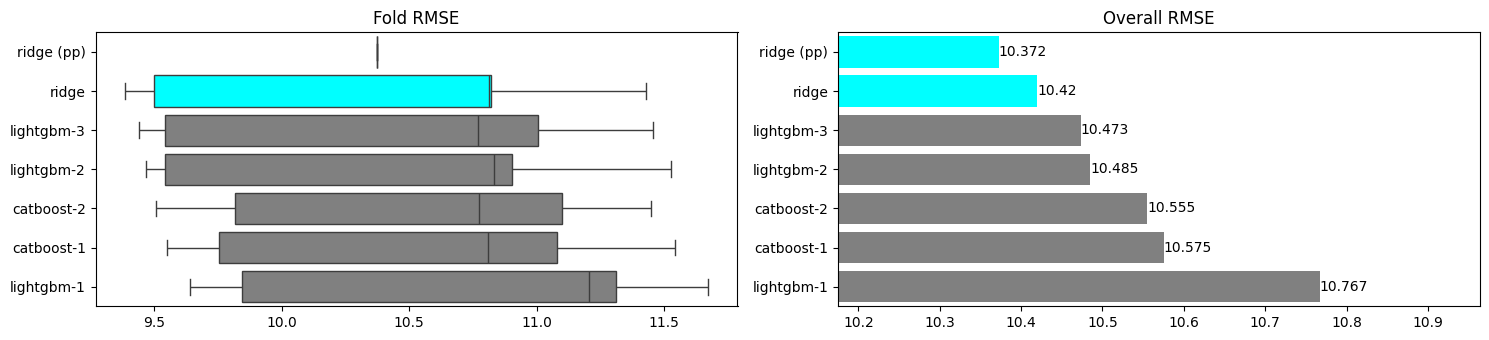

In [24]:
fold_scores_df = pd.DataFrame(fold_scores)
overall_scores_df = pd.DataFrame({k: [v] for k, v in overall_scores.items()}).transpose().sort_values(by=0, ascending=True)
order = overall_scores_df.index.tolist()

min_score = overall_scores_df.values.flatten().min()
max_score = overall_scores_df.values.flatten().max()
padding = (max_score - min_score) * 0.5
lower_limit = min_score - padding
upper_limit = max_score + padding

fig, axs = plt.subplots(1, 2, figsize=(15, fold_scores_df.shape[1] * 0.5))

boxplot = sns.boxplot(data=fold_scores_df, order=order, ax=axs[0], orient="h", color="grey")
axs[0].set_title(f"Fold RMSE")
axs[0].set_xlabel("")
axs[0].set_ylabel("")

barplot = sns.barplot(x=overall_scores_df.values.flatten(), y=overall_scores_df.index, ax=axs[1], color="grey")
axs[1].set_title(f"Overall RMSE")
axs[1].set_xlabel("")
axs[1].set_xlim(left=lower_limit, right=upper_limit)
axs[1].set_ylabel("")

for i, (score, model) in enumerate(zip(overall_scores_df.values.flatten(), overall_scores_df.index)):
    color = "cyan" if "ridge" in model.lower() else "grey"
    barplot.patches[i].set_facecolor(color)
    boxplot.patches[i].set_facecolor(color)
    barplot.text(score, i, round(score, 3), va="center")

plt.tight_layout()
plt.show()


In [25]:
from pathlib import Path as _BlendPath
import pandas as _blend_pd
_sp45_path = _BlendPath('/kaggle/working/submission.csv') if _BlendPath('/kaggle/working').exists() else _BlendPath('submission.csv')
_sp45_df = _blend_pd.read_csv(_sp45_path)
_sp45_df.to_csv((_BlendPath('/kaggle/working') if _BlendPath('/kaggle/working').exists() else _BlendPath('.')) / 'sp45_projection_submission.csv', index=False)
print('saved sp45_projection_submission.csv', _sp45_df.shape, flush=True)


# Learned trajectory inference section follows.


saved sp45_projection_submission.csv (14151, 2)


In [26]:
import os, sys, glob, time, warnings, multiprocessing
from pathlib import Path
import numpy as np
import pandas as pd
from numba import njit
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from joblib import Parallel, delayed
warnings.filterwarnings("ignore")
os.environ.setdefault("SHOW_FIGS", "0")

# ---- environment / paths (Kaggle or local) -------------------------------------
def _find_data():
    for c in ["/kaggle/input/competitions/rogii-wellbore-geology-prediction",
              "/kaggle/input/rogii-wellbore-geology-prediction"]:
        if Path(c).exists() and (Path(c)/"train").exists():
            return Path(c)
    # fallback: find any mounted folder that contains a train/ directory
    for p in glob.glob("/kaggle/input/**/train", recursive=True):
        return Path(p).parent
    return Path(os.environ.get("ROGII_DATA", "."))   # local override for development

class CFG:
    DATA = _find_data()
    OUT  = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
    seed = 42
    n_splits = 5
    n_jobs = min(8, multiprocessing.cpu_count())
    # lik-PF
    PF_SEEDS = 128
    PF_PARTICLES = 500
    PF_SCALES = (3., 5., 8., 12.)
    # FAST dev (local smoke test): limit train wells & trees
    FAST = bool(int(os.environ.get("FAST", "0")))
    N_TRAIN_WELLS = int(os.environ.get("N_TRAIN_WELLS", "0"))  # 0 = all
    USE_GPU = os.environ.get("USE_GPU", "auto")
    SHOW_FIGS = os.environ.get("SHOW_FIGS", "1") == "1"   # EDA plots (on in the notebook)

FORMATIONS = ["ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA"]
def _demo_well():
    """A train well with TVT + a sizable eval zone, for the EDA plots."""
    for w in sorted(p.stem.replace("__horizontal_well", "")
                    for p in (CFG.DATA/"train").glob("*__horizontal_well.csv")):
        try:
            d = pd.read_csv(CFG.DATA/"train"/f"{w}__horizontal_well.csv", usecols=["TVT", "TVT_input"])
        except Exception:
            continue
        if "TVT" in d and d.TVT.notna().any() and d.TVT_input.isna().sum() > 2000:
            return w
    return None
print("DATA:", CFG.DATA, "| OUT:", CFG.OUT, "| cores:", CFG.n_jobs, "| FAST:", CFG.FAST)

def load_well(wid, split="train"):
    base = CFG.DATA / split
    hw = pd.read_csv(base / f"{wid}__horizontal_well.csv")
    tw = pd.read_csv(base / f"{wid}__typewell.csv").sort_values("TVT")
    return hw, tw

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a, float) - np.asarray(b, float))**2)))


DATA: /kaggle/input/competitions/rogii-wellbore-geology-prediction | OUT: /kaggle/working | cores: 4 | FAST: False


In [27]:
def fig_overview(wid):
    import matplotlib.pyplot as plt
    hw, tw = load_well(wid)
    kn = hw[hw.TVT_input.notna()]; ev = hw[hw.TVT_input.isna()]; ps = kn.MD.iloc[-1]
    fig, ax = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True)
    ax[0].plot(hw.MD, hw.Z, lw=1.2, color="#333"); ax[0].axvline(ps, color="crimson", ls="--", label="PS")
    ax[0].set_ylabel("Z / TVD (ft)"); ax[0].legend(loc="upper right")
    ax[0].set_title(f"Well {wid}: trajectory Â· gamma-ray Â· TVT target")
    ax[1].plot(kn.MD, kn.GR, lw=.7, color="steelblue", label="GR known")
    ax[1].plot(ev.MD, ev.GR, lw=.7, color="darkorange", label="GR eval"); ax[1].axvline(ps, color="crimson", ls="--")
    ax[1].set_ylabel("GR (API)"); ax[1].legend(loc="upper right")
    ax[2].plot(kn.MD, kn.TVT, lw=1.6, color="seagreen", label="TVT known (=input)")
    ax[2].plot(ev.MD, ev.TVT, lw=1.6, color="crimson", label="TVT to predict"); ax[2].axvline(ps, color="crimson", ls="--")
    ax[2].set_ylabel("TVT (ft)"); ax[2].set_xlabel("MD (ft)"); ax[2].invert_yaxis(); ax[2].legend(loc="upper right")
    for a in ax: a.grid(alpha=.25)
    plt.tight_layout(); plt.show()

def fig_correlation(wid):
    import matplotlib.pyplot as plt
    hw, tw = load_well(wid); ev = hw[hw.TVT_input.isna()]
    fig, ax = plt.subplots(1, 2, figsize=(11, 6))
    ax[0].plot(tw.GR, tw.TVT, lw=1.0, color="black")
    ax[0].set_xlabel("GR (API)"); ax[0].set_ylabel("TVT (ft)"); ax[0].invert_yaxis()
    ax[0].set_title("Typewell signature: GR vs TVT")
    sc = ax[1].scatter(ev.GR, ev.TVT, s=4, c=ev.MD, cmap="viridis")
    ax[1].set_xlabel("GR (API)"); ax[1].set_ylabel("TVT (ft)"); ax[1].invert_yaxis()
    ax[1].set_title("Horizontal GR at its true TVT\nmatches the typewell signature")
    plt.colorbar(sc, ax=ax[1], label="MD (ft)")
    for a in ax: a.grid(alpha=.25)
    plt.tight_layout(); plt.show()

def fig_drift_tail(n_wells=250):
    import matplotlib.pyplot as plt
    wids = sorted(p.stem.replace("__horizontal_well", "") for p in (CFG.DATA/"train").glob("*__horizontal_well.csv"))
    rng = np.random.default_rng(1); samp = sorted(rng.choice(wids, min(n_wells, len(wids)), replace=False).tolist())
    per = []
    for wid in samp:
        try: hw = pd.read_csv(CFG.DATA/"train"/f"{wid}__horizontal_well.csv", usecols=["TVT_input", "TVT"])
        except: continue
        ev = hw[hw.TVT_input.isna()]; kn = hw[hw.TVT_input.notna()]
        if len(ev) == 0 or len(kn) < 10 or hw.TVT.isna().all(): continue
        t = ev.TVT.values
        if np.isnan(t).any(): continue
        per.append(np.sqrt(np.mean((t-kn.TVT_input.iloc[-1])**2)))
    per = np.array(per); srt = np.sort(per)[::-1]; cum = np.cumsum(srt**2)/np.sum(srt**2)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].hist(per, bins=40, color="indianred", alpha=.85)
    ax[0].axvline(np.median(per), color="k", ls="--", label=f"median={np.median(per):.1f}")
    ax[0].axvline(per.mean(), color="b", ls="--", label=f"mean={per.mean():.1f}")
    ax[0].set_xlabel("per-well last-known-baseline RMSE (ft)"); ax[0].set_ylabel("wells"); ax[0].legend()
    ax[0].set_title("Per-well error is heavily right-skewed")
    ax[1].plot(np.arange(1, len(srt)+1)/len(srt)*100, cum*100, color="purple"); ax[1].axhline(80, color="gray", ls=":")
    ax[1].set_xlabel("% of wells (worst first)"); ax[1].set_ylabel("% of pooled squared error")
    ax[1].set_title("A few drift wells dominate the metric")
    for a in ax: a.grid(alpha=.25)
    plt.tight_layout(); plt.show()


In [28]:
DEMO = "00bbac68" if (CFG.DATA/"train"/"00bbac68__horizontal_well.csv").exists() else _demo_well()
if CFG.SHOW_FIGS:
    print("demo well:", DEMO)
    if DEMO:
        fig_overview(DEMO)
        fig_correlation(DEMO)
    fig_drift_tail()


In [29]:
# ---- single particle filters (ANCC-anchored & Z-velocity-coupled), numba ---------
PF_N = 600; ANCC_N = 600
PF_MOM = 0.993; PF_VN = 0.005; PF_PN = 0.01
PF_GR_SIG_MIN = 10.; PF_GR_SIG_MAX = 60.; PF_GR_SIG_DEF = 30.
PF_GR_WIN = 5; PF_GR_WT = 0.3; PF_RESAMP = 0.5; PF_ROUGH_P = 0.2; PF_ROUGH_V = 0.003
ANCC_ALPHA = 0.998; ANCC_RN = 0.002; ANCC_PN = 0.005; ANCC_IS = 0.3; ANCC_RP = 0.1; ANCC_RR = 0.001

BEAMS = [(10,20.,144.,2,"cons"),(10,8.,64.,2,"loose"),(8,35.,220.,1,"vcons"),
         (10,14.,90.,5,"sm5"),(20,4.,36.,3,"vloose"),(12,12.,100.,3,"mid"),(15,25.,180.,2,"stiff")]

@njit(cache=True)
def _interp1(grid, v, vmin, step):
    i = int((v - vmin) / step)
    if i < 0: return grid[0]
    n = len(grid) - 1
    if i >= n: return grid[n]
    t = (v - vmin) / step - i
    return grid[i]*(1.-t) + grid[i+1]*t

@njit(cache=True)
def _resamp(pos, aux, w, N, rp, rv):
    cum = np.zeros(N+1)
    for j in range(N): cum[j+1] = cum[j]+w[j]
    u0 = np.random.uniform(0., 1./N); np2 = np.empty(N); na = np.empty(N); ci = 0
    for j in range(N):
        u = u0+j/N
        while ci < N-1 and cum[ci+1] < u: ci += 1
        np2[j] = pos[ci]+rp*np.random.randn(); na[j] = aux[ci]+rv*np.random.randn()
    return np2, na

@njit(cache=True)
def _beam_jit(sgr, tw_gr, si, BS, mc, es):
    n = len(sgr); nt = len(tw_gr); MAX = BS*6
    bidx = np.zeros(BS, np.int64); bidx[0] = si
    bcost = np.full(BS, 1e30); bcost[0] = 0.; bn = np.int64(1)
    hI = np.zeros((n, BS), np.int64); hP = np.zeros((n, BS), np.int64)
    cI = np.zeros(MAX, np.int64); cC = np.full(MAX, 1e30); cP = np.zeros(MAX, np.int64)
    for step in range(n):
        gv = sgr[step]; nc = np.int64(0)
        for bi in range(bn):
            idx = bidx[bi]; cost = bcost[bi]
            for d in range(-2, 3):
                ni = idx+d
                if ni < 0 or ni >= nt: continue
                tot = cost+(gv-tw_gr[ni])**2/es+mc*(d if d >= 0 else -d)
                fnd = np.int64(-1)
                for ci in range(nc):
                    if cI[ci] == ni: fnd = ci; break
                if fnd >= 0:
                    if tot < cC[fnd]: cC[fnd] = tot; cP[fnd] = bi
                else:
                    if nc < MAX: cI[nc] = ni; cC[nc] = tot; cP[nc] = bi; nc += 1
        kept = min(BS, nc)
        for i in range(kept):
            mi = i
            for j in range(i+1, nc):
                if cC[j] < cC[mi]: mi = j
            if mi != i:
                cI[i], cI[mi] = cI[mi], cI[i]; cC[i], cC[mi] = cC[mi], cC[i]; cP[i], cP[mi] = cP[mi], cP[i]
        hI[step, :kept] = cI[:kept]; hP[step, :kept] = cP[:kept]
        bidx[:kept] = cI[:kept]; bcost[:kept] = cC[:kept]; bn = kept
    best = np.int64(0)
    for b in range(1, bn):
        if bcost[b] < bcost[best]: best = b
    path = np.zeros(n, np.int64); b = best
    for s in range(n-1, -1, -1): path[s] = hI[s, b]; b = hP[s, b]
    return path

@njit(cache=True)
def _pf_ancc(md_v, z_v, gr_v, gg, vmin, step, gs, ls, ir, N, ALPHA, RN, PN, IS, RP, RR, RESAMP):
    pos = np.empty(N); rate = np.empty(N); w = np.ones(N)/N
    for j in range(N):
        pos[j] = ls+IS*np.random.randn(); rate[j] = ir+0.01*np.random.randn()
    pts = np.empty(len(md_v)); std_ = np.empty(len(md_v)); pm = md_v[0]-1.
    for i in range(len(md_v)):
        dm = md_v[i]-pm; dm = max(dm, 1.)
        for j in range(N):
            rate[j] = ALPHA*rate[j]+RN*np.random.randn(); pos[j] += rate[j]*dm+PN*np.random.randn()
            tvt_j = pos[j]-z_v[i]; tvt_j = max(tvt_j, vmin-50.); tvt_j = min(tvt_j, vmin+len(gg)*step+50.)
            pos[j] = tvt_j+z_v[i]
        if not np.isnan(gr_v[i]):
            ws = 0.
            for j in range(N):
                eg = _interp1(gg, pos[j]-z_v[i], vmin, step); d = (gr_v[i]-eg)/gs
                lk = max(np.exp(-0.5*d*d) if d*d < 600. else 0., 1e-300); w[j] *= lk; ws += w[j]
            if ws > 0.:
                for j in range(N): w[j] /= ws
            else:
                for j in range(N): w[j] = 1./N
        ne = 0.
        for j in range(N): ne += w[j]*w[j]
        if 1./ne < RESAMP*N:
            pos, rate = _resamp(pos, rate, w, N, RP, RR)
            for j in range(N): w[j] = 1./N
        tv = 0.
        for j in range(N): tv += w[j]*(pos[j]-z_v[i])
        pts[i] = tv; va = 0.
        for j in range(N): va += w[j]*(pos[j]-z_v[i]-tv)**2
        std_[i] = va**0.5; pm = md_v[i]
    return pts, std_

@njit(cache=True)
def _pf_z(md_v, z_v, gr_v, gr_sm_v, gg_p, gg_s, vmin, step, gs, ip, iv, beta, icpt, zsig, N,
         MOM, VN, PN, GR_WT, RP, RV, RESAMP):
    pos = np.empty(N); vel = np.empty(N); w = np.ones(N)/N
    for j in range(N):
        pos[j] = ip+0.5*np.random.randn(); vel[j] = iv+0.02*np.random.randn()
    pts = np.empty(len(md_v)); std_ = np.empty(len(md_v)); pm = md_v[0]-1.; pz = z_v[0]-1.
    for i in range(len(md_v)):
        dm = md_v[i]-pm; dm = max(dm, 1.); dzd = (z_v[i]-pz)/dm; ve = beta*dzd+icpt
        for j in range(N):
            vel[j] = MOM*vel[j]+VN*np.random.randn(); pos[j] += vel[j]*dm+PN*np.random.randn()
            pos[j] = max(pos[j], vmin-50.); pos[j] = min(pos[j], vmin+len(gg_p)*step+50.)
        if not np.isnan(gr_v[i]):
            ws = 0.
            for j in range(N):
                ep = _interp1(gg_p, pos[j], vmin, step); dp = (gr_v[i]-ep)/gs
                lp = max(np.exp(-0.5*dp*dp) if dp*dp < 600. else 0., 1e-300)
                if not np.isnan(gr_sm_v[i]):
                    es = _interp1(gg_s, pos[j], vmin, step); ds = (gr_sm_v[i]-es)/(gs*1.5)
                    lsm = max(np.exp(-0.5*ds*ds) if ds*ds < 600. else 0., 1e-300); lk = (1.-GR_WT)*lp+GR_WT*lsm
                else: lk = lp
                lk = max(lk, 1e-300); w[j] *= lk; ws += w[j]
            if ws > 0.:
                for j in range(N): w[j] /= ws
            else:
                for j in range(N): w[j] = 1./N
        ws2 = 0.
        for j in range(N):
            dv = (vel[j]-ve)/max(zsig*2., 0.005); lz = max(np.exp(-0.5*dv*dv) if dv*dv < 600. else 0., 1e-300)
            w[j] *= lz; ws2 += w[j]
        if ws2 > 0.:
            for j in range(N): w[j] /= ws2
        else:
            for j in range(N): w[j] = 1./N
        ne = 0.
        for j in range(N): ne += w[j]*w[j]
        if 1./ne < RESAMP*N:
            pos, vel = _resamp(pos, vel, w, N, RP, RV)
            for j in range(N): w[j] = 1./N
        wm = 0.
        for j in range(N): wm += w[j]*pos[j]
        pts[i] = wm; va = 0.
        for j in range(N): va += w[j]*(pos[j]-wm)**2
        std_[i] = va**0.5; pm = md_v[i]; pz = z_v[i]
    return pts, std_

def _grid(tw_tvt, tw_gr, step=0.2):
    tmin = float(tw_tvt.min()); tmax = float(tw_tvt.max())
    tvt_g = np.arange(tmin, tmax+step, step)
    return np.interp(tvt_g, tw_tvt, tw_gr).astype(np.float64), float(tmin), float(step)

def _gr_sig(hw, tw_tvt, tw_gr):
    kn = hw[hw.TVT_input.notna() & hw.GR.notna()]
    if len(kn) < 20: return float(PF_GR_SIG_DEF)
    return float(np.clip(np.std(kn.GR.values-np.interp(kn.TVT_input.values, tw_tvt, tw_gr)),
                         PF_GR_SIG_MIN, PF_GR_SIG_MAX))

def _nn(arr, v):
    i = int(np.searchsorted(arr, v, "left"))
    if i >= len(arr): return len(arr)-1
    if i > 0 and abs(arr[i-1]-v) <= abs(arr[i]-v): return i-1
    return i

def _smooth(vals, fb, r):
    s = pd.Series(vals, dtype="float32").interpolate(limit_direction="both").fillna(fb)
    return (s.rolling(r*2+1, center=True, min_periods=1).mean() if r > 0 else s).to_numpy(np.float32)

def beam_search(gr_h, tw_tvt, tw_gr, start_tvt, bs, mc, es, r):
    si = _nn(tw_tvt, start_tvt); sgr = _smooth(gr_h, float(np.nanmean(tw_gr)), r).astype(np.float64)
    return tw_tvt[_beam_jit(sgr, tw_gr.astype(np.float64), si, bs, float(mc), float(es))].astype(np.float32)

def run_pf_ancc(hw, tw_tvt, tw_gr, N=ANCC_N):
    gs = _gr_sig(hw, tw_tvt, tw_gr); kn = hw[hw.TVT_input.notna()]; ev = hw[hw.TVT_input.isna()]
    if len(ev) == 0: return np.array([]), np.array([])
    ls = float(kn.TVT_input.iloc[-1]+kn.Z.iloc[-1])
    tail = kn.tail(30); dt = np.diff(tail.TVT_input.values); dz = np.diff(tail.Z.values); dm = np.diff(tail.MD.values); m = dm > 0
    ir = float(np.median((dt+dz)[m]/dm[m])) if m.sum() >= 3 else 0.
    gg, gmin, gst = _grid(tw_tvt, tw_gr)
    pts, std = _pf_ancc(ev.MD.values.astype(np.float64), ev.Z.values.astype(np.float64), ev.GR.values.astype(np.float64),
                        gg, gmin, gst, gs, ls, ir, N, ANCC_ALPHA, ANCC_RN, ANCC_PN, ANCC_IS, ANCC_RP, ANCC_RR, PF_RESAMP)
    return pts.astype(np.float32), std.astype(np.float32)

def run_pf_z(hw, tw_tvt, tw_gr, N=PF_N):
    gs = _gr_sig(hw, tw_tvt, tw_gr); tw_s = pd.Series(tw_gr).rolling(PF_GR_WIN, center=True, min_periods=1).mean().values.astype(np.float32)
    kna = hw[hw.TVT_input.notna()]; ev = hw[hw.TVT_input.isna()]
    if len(ev) == 0: return np.array([]), np.array([])
    dz_k = np.diff(kna.Z.values); dvt = np.diff(kna.TVT_input.values); dmd_k = np.diff(kna.MD.values); m2 = dmd_k > 0
    if m2.sum() >= 10:
        vz = dz_k[m2]/dmd_k[m2]; vt = dvt[m2]/dmd_k[m2]; A = np.column_stack([vz, np.ones_like(vz)])
        c, _, _, _ = np.linalg.lstsq(A, vt, rcond=None)
        beta, icpt, zsig = float(c[0]), float(c[1]), max(float(np.std(vt-(c[0]*vz+c[1]))), 0.001)
    else: beta, icpt, zsig = -1., 0., 0.1
    t2 = kna.tail(20); dvt2 = np.diff(t2.TVT_input.values); dmd2 = np.diff(t2.MD.values); m3 = dmd2 > 0
    iv = float(np.median(dvt2[m3]/dmd2[m3])) if m3.sum() >= 3 else 0.
    gg, gmin, gst = _grid(tw_tvt, tw_gr); gs2, _, _ = _grid(tw_tvt, tw_s)
    gr_sm = hw.GR.rolling(PF_GR_WIN, center=True, min_periods=1).mean()
    pts, std = _pf_z(ev.MD.values.astype(np.float64), ev.Z.values.astype(np.float64), ev.GR.values.astype(np.float64),
                     gr_sm.loc[ev.index].values.astype(np.float64), gg, gs2, gmin, gst, gs,
                     float(kna.TVT_input.iloc[-1]), iv, beta, icpt, zsig, N,
                     PF_MOM, PF_VN, PF_PN, PF_GR_WT, PF_ROUGH_P, PF_ROUGH_V, PF_RESAMP)
    return pts.astype(np.float32), std.astype(np.float32)

def multi_scale_ncc(kgr, ktvt, hgr, hws=(8, 15, 25), stride=3):
    out = []
    for hw in hws:
        win = 2*hw+1; nk = len(kgr); nh = len(hgr)
        if nk < win+1 or nh == 0:
            out.append((np.full(nh, ktvt[-1], np.float32), np.zeros(nh, np.float32))); continue
        kg = pd.Series(kgr).rolling(5, center=True, min_periods=1).mean().values.astype(np.float32)
        hg = pd.Series(hgr).rolling(5, center=True, min_periods=1).mean().values.astype(np.float32)
        sts = np.arange(0, nk-win+1, stride, dtype=np.int32)
        if len(sts) == 0:
            out.append((np.full(nh, ktvt[-1], np.float32), np.zeros(nh, np.float32))); continue
        C = kg[sts[:, None]+np.arange(win, dtype=np.int32)[None, :]].astype(np.float32)
        Cn = (C-C.mean(1, keepdims=True))/(C.std(1, keepdims=True)+1e-6)
        hp = np.pad(hg, hw, mode="edge"); H = hp[np.arange(nh)[:, None]+np.arange(win)[None, :]].astype(np.float32)
        Hn = (H-H.mean(1, keepdims=True))/(H.std(1, keepdims=True)+1e-6)
        ncc = Hn@Cn.T/win; best = ncc.argmax(1); score = ncc.max(1).astype(np.float32)
        out.append((ktvt[np.clip(sts[best]+hw, 0, nk-1)].astype(np.float32), score))
    tvts = np.stack([o[0] for o in out], 1); scores = np.stack([o[1] for o in out], 1)
    sw = np.exp(3.*scores); sw /= sw.sum(1, keepdims=True)+1e-9
    return out, (tvts*sw).sum(1).astype(np.float32)


In [30]:
# ---- 128-seed likelihood-weighted particle filter (the workhorse), numba ---------
@njit(cache=True, nogil=True)
def _pf_lik_allseeds(md_v, z_v, gr_v, gg, vmin, step, gs, ls, ir, N, n_seeds, seed_base,
                     MOM, VN, PN, RP, RR, RESAMP, init_spr):
    n = len(md_v); preds = np.empty((n_seeds, n)); liks = np.empty(n_seeds); tmax = vmin + len(gg)*step
    for s in range(n_seeds):
        np.random.seed(seed_base + s)
        pos = np.empty(N); rate = np.empty(N); w = np.ones(N)/N
        for j in range(N):
            pos[j] = ls + init_spr*np.random.randn(); rate[j] = ir + 0.01*np.random.randn()
        log_lik = 0.0; prev_md = md_v[0] - 1.0
        for i in range(n):
            dm = md_v[i] - prev_md
            if dm < 1.0: dm = 1.0
            for j in range(N):
                rate[j] = MOM*rate[j] + VN*np.random.randn(); pos[j] += rate[j]*dm + PN*np.random.randn()
                tvt_j = pos[j] - z_v[i]
                if tvt_j < vmin-100.: tvt_j = vmin-100.
                if tvt_j > tmax+100.: tvt_j = tmax+100.
                pos[j] = tvt_j + z_v[i]
            avg_lk = 0.0
            for j in range(N):
                eg = _interp1(gg, pos[j]-z_v[i], vmin, step); d = (gr_v[i]-eg)/gs; dd = d*d
                if dd > 600.: dd = 600.
                lk = np.exp(-0.5*dd)
                if lk < 1e-300: lk = 1e-300
                avg_lk += w[j]*lk; w[j] = w[j]*lk
            if avg_lk < 1e-300: avg_lk = 1e-300
            log_lik += np.log(avg_lk)
            ws = 0.0
            for j in range(N): ws += w[j]
            if ws > 0.0:
                for j in range(N): w[j] /= ws
            else:
                for j in range(N): w[j] = 1./N
            neff = 0.0
            for j in range(N): neff += w[j]*w[j]
            neff = 1.0/neff
            if neff < RESAMP*N:
                cum = np.empty(N); c = 0.0
                for j in range(N): c += w[j]; cum[j] = c
                u0 = np.random.uniform(0., 1./N); newpos = np.empty(N); newrate = np.empty(N); ci = 0
                for j in range(N):
                    u = u0 + j/N
                    while ci < N-1 and cum[ci] < u: ci += 1
                    newpos[j] = pos[ci] + RP*np.random.randn(); newrate[j] = rate[ci] + RR*np.random.randn()
                for j in range(N): pos[j] = newpos[j]; rate[j] = newrate[j]; w[j] = 1./N
            est = 0.0
            for j in range(N): est += w[j]*(pos[j]-z_v[i])
            preds[s, i] = est; prev_md = md_v[i]
        liks[s] = log_lik
    return preds, liks

def lik_pf(hw, tw, n_particles=CFG.PF_PARTICLES, n_seeds=CFG.PF_SEEDS, scales=CFG.PF_SCALES,
           init_spr=4.5, seed_base=0, with_quality=False):
    """Likelihood-weighted PF ensemble. Returns ({pf_scale_X: pred_eval}, ev_index[, quality])."""
    tw_s = tw.sort_values("TVT"); tw_tvt = tw_s.TVT.values.astype(float)
    tw_gr = tw_s.GR.fillna(tw_s.GR.mean()).values.astype(float)
    kn = hw[hw.TVT_input.notna()]; ev = hw[hw.TVT_input.isna()]
    if len(ev) == 0: return {}, np.array([]), {}
    last = kn.iloc[-1]; ls = float(last.TVT_input) + float(last.Z)
    tw_at_k = np.interp(kn.TVT_input.values, tw_tvt, tw_gr)
    gs = float(np.clip(np.nanstd(kn.GR.fillna(0).values - tw_at_k), 10., 60.))
    tail = kn.tail(30); dt = np.diff(tail.TVT_input.values); dz = np.diff(tail.Z.values); dm = np.diff(tail.MD.values); m = dm > 0
    ir = float(np.median((dt+dz)[m]/dm[m])) if m.sum() >= 3 else 0.0
    gg, gmin, gst = _grid(tw_tvt, tw_gr)
    gr_v = hw.GR.interpolate(limit_direction="both").fillna(tw_gr.mean()).values.astype(float)[ev.index]
    preds, liks = _pf_lik_allseeds(ev.MD.values.astype(float), ev.Z.values.astype(float), gr_v,
                                   gg, gmin, gst, gs, ls, ir, n_particles, n_seeds, seed_base,
                                   0.998, 0.002, 0.005, 0.1, 0.001, 0.5, init_spr)
    ln = liks - liks.max(); out = {}
    for sc in scales:
        wts = np.exp(ln/float(sc)); wts /= wts.sum(); out[f"pf_scale_{sc:g}"] = (wts[:, None]*preds).sum(0)
    out["pf_mean"] = preds.mean(0)
    q = {}
    if with_quality:
        q = {"pf_best_ll": float(liks.max())/len(ev), "pf_ll_spread": float(liks.std()),
             "pf_pt_std": preds.std(0).astype(np.float32), "pf_gr_sig": gs}
    return out, ev.index.values, q

# JIT warm-up so timings below are representative
_m = np.linspace(1, 50, 20); _z = np.zeros(20); _g = np.full(20, 50.); _gg = np.linspace(45, 55, 100)
_pf_ancc(_m, _z, _g, _gg, 45., .1, 20., 50., 0., 8, .998, .002, .005, .3, .1, .001, .5)
_pf_z(_m, _z, _g, _g, _gg, _gg, 45., .1, 20., 50., 0., -1., 0., .1, 8, .993, .005, .01, .3, .2, .003, .5)
_beam_jit(np.random.randn(30), np.random.randn(50), 25, 8, 15., 100.)
_pf_lik_allseeds(_m, _z, _g, _gg, 45., .1, 20., 50., 0., 64, 4, 0, .998, .002, .005, .1, .001, .5, 4.5)
print("trackers compiled.")

def fig_tracker_vs_truth(wid):
    import matplotlib.pyplot as plt
    hw, tw = load_well(wid); kn = hw[hw.TVT_input.notna()]; ev = hw[hw.TVT_input.isna()]
    tw_tvt = tw.TVT.to_numpy(np.float32); tw_gr = tw.GR.to_numpy(np.float32); last = float(kn.TVT_input.iloc[-1])
    pf, _ = run_pf_ancc(hw, tw_tvt, tw_gr); out, _, _ = lik_pf(hw, tw, scales=(3.,))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(ev.MD, ev.TVT, lw=2.2, color="black", label="True TVT", zorder=5)
    ax.plot(ev.MD, np.full(len(ev), last), lw=1.1, color="gray", ls=":", label="last-known baseline")
    ax.plot(ev.MD, pf, lw=1.0, color="tab:blue", alpha=.8, label="single particle filter")
    ax.plot(ev.MD, out["pf_scale_3"], lw=1.5, color="crimson", alpha=.9, label="128-seed lik-weighted PF")
    ax.set_xlabel("MD (ft)"); ax.set_ylabel("TVT (ft)"); ax.invert_yaxis(); ax.grid(alpha=.25)
    ax.set_title(f"Well {wid}: trackers vs ground truth â€” the lik-PF resists drift"); ax.legend(loc="best")
    plt.tight_layout(); plt.show()


trackers compiled.


In [31]:
if CFG.SHOW_FIGS and DEMO:
    fig_tracker_vs_truth(DEMO)


In [32]:
PLANE_K = 10; DENSE_SPW = 60; DENSE_K = 20

def robust_slope(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float); m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2 or np.std(x[m]) < 1e-6: return 0.
    return float(np.polyfit(x[m], y[m], 1)[0])

def affine_cal(kgr, tw_at_k, min_pts=20):
    v = np.isfinite(kgr) & np.isfinite(tw_at_k)
    if v.sum() < min_pts or np.std(tw_at_k[v]) < 1e-6:
        return 1., float(np.nanmean(kgr)-np.nanmean(tw_at_k)) if v.any() else 0.
    a, b = np.polyfit(tw_at_k[v], kgr[v], 1); return float(a), float(b)

def seg_b_well(ktvt, kz, form_col):
    bv = ktvt+kz-form_col; n = len(bv); b_full = float(np.median(bv))
    b_late = float(np.median(bv[max(0, n-50):])) if n >= 5 else b_full
    t1, t2 = n//3, 2*n//3
    b_early = float(np.median(bv[:max(1, t1)])) if t1 > 0 else b_full
    b_mid = float(np.median(bv[t1:max(t1+1, t2)])) if t2 > t1 else b_full
    w = np.exp(0.02*np.arange(n)); w /= w.sum()
    return b_full, b_early, b_mid, b_late, float(np.dot(w, bv))

class FormationPlaneKNN:
    def __init__(self, well_ids, data_dir):
        rows = []
        for wid in well_ids:
            try: df = pd.read_csv(data_dir/f"{wid}__horizontal_well.csv", usecols=["X","Y"]+FORMATIONS).dropna()
            except: continue
            if len(df) == 0: continue
            row = {"wid": wid, "x": float(df.X.median()), "y": float(df.Y.median())}
            for c in FORMATIONS: row[f"{c}_m"] = float(df[c].median())
            rows.append(row)
        self.df = pd.DataFrame(rows); self.wmap = {w: i for i, w in enumerate(self.df.wid)}
        xy = self.df[["x","y"]].to_numpy(); self.scale = np.where(xy.std(0) < 1e-3, 1., xy.std(0))
        self.tree = cKDTree(xy/self.scale); self.xa = self.df.x.to_numpy(); self.ya = self.df.y.to_numpy()
        self.fa = self.df[[f"{c}_m" for c in FORMATIONS]].to_numpy(np.float64)
    def impute(self, xy_q, self_wid=None, k=PLANE_K):
        q = xy_q/self.scale; nf = min(k+5, len(self.df)); dist, idx = self.tree.query(q, k=nf, workers=-1)
        if self_wid in self.wmap: dist = np.where(idx == self.wmap[self_wid], np.inf, dist)
        ordr = np.argpartition(dist, min(k-1, nf-1), 1)[:, :k]
        dk = np.take_along_axis(dist, ordr, 1); ik = np.take_along_axis(idx, ordr, 1)
        vk = np.isfinite(dk); w = np.where(vk, 1./(dk+1e-3), 0.).astype(np.float64)
        xn = self.xa[ik]; yn = self.ya[ik]; fn = self.fa[ik]; wx = w*xn; wy = w*yn
        A = np.zeros((len(q), 3, 3))
        A[:,0,0]=(wx*xn).sum(1); A[:,0,1]=(wx*yn).sum(1); A[:,0,2]=wx.sum(1)
        A[:,1,0]=A[:,0,1]; A[:,1,1]=(wy*yn).sum(1); A[:,1,2]=wy.sum(1)
        A[:,2,0]=A[:,0,2]; A[:,2,1]=A[:,1,2]; A[:,2,2]=w.sum(1)
        A[:,0,0]+=1e-9; A[:,1,1]+=1e-9; A[:,2,2]+=1e-9
        rhs = np.stack([(wx[:,:,None]*fn).sum(1), (wy[:,:,None]*fn).sum(1), (w[:,:,None]*fn).sum(1)], 1)
        try: coef = np.linalg.solve(A, rhs)
        except:
            coef = np.zeros((len(q), 3, 6))
            for r in range(len(q)):
                try: coef[r] = np.linalg.pinv(A[r])@rhs[r]
                except: pass
        Xq = xy_q[:,0]; Yq = xy_q[:,1]
        pred = (Xq[:,None]*coef[:,0,:]+Yq[:,None]*coef[:,1,:]+coef[:,2,:]).astype(np.float32)
        pred[~vk.any(1)] = self.fa.mean(0)
        return pred, np.where(vk, dk, np.inf).min(1).astype(np.float32)

class DenseANCCImputer:
    def __init__(self, well_ids, data_dir, spw=DENSE_SPW):
        xs, ys, an, wd = [], [], [], []
        for wid in well_ids:
            try: df = pd.read_csv(data_dir/f"{wid}__horizontal_well.csv", usecols=["X","Y","ANCC"]).dropna()
            except: continue
            if len(df) == 0: continue
            ix = np.linspace(0, len(df)-1, min(spw, len(df)), dtype=int); s = df.iloc[ix]
            xs.append(s.X.values); ys.append(s.Y.values); an.append(s.ANCC.values); wd.extend([wid]*len(s))
        self.xy = np.column_stack([np.concatenate(xs), np.concatenate(ys)])
        self.ancc = np.concatenate(an).astype(np.float32); self.wids = np.array(wd)
        self.scale = np.where(self.xy.std(0) < 1e-3, 1., self.xy.std(0)); self.tree = cKDTree(self.xy/self.scale)
    def impute(self, xy_q, self_wid=None, k=DENSE_K, nfetch=5000):
        xy_q = np.atleast_2d(xy_q); q = xy_q/self.scale; nf = min(nfetch, len(self.ancc))
        dist, idx = self.tree.query(q, k=nf, workers=-1)
        if self_wid: dist = np.where(self.wids[idx] == self_wid, np.inf, dist)
        ordr = np.argpartition(dist, min(k-1, nf-1), 1)[:, :k]
        dk = np.take_along_axis(dist, ordr, 1); ik = np.take_along_axis(idx, ordr, 1)
        vk = np.isfinite(dk); w = np.where(vk, 1./(dk+1e-3), 0.); sw = w.sum(1); safe = np.where(sw < 1e-9, 1., sw)
        a = self.ancc[ik]; ap = (a*w).sum(1)/safe; ap = np.where(sw < 1e-9, float(self.ancc.mean()), ap)
        var = ((a-ap[:,None])**2*w).sum(1)/safe
        return ap.astype(np.float32), np.sqrt(np.maximum(var, 0.)).astype(np.float32), np.where(vk, dk, np.inf).min(1).astype(np.float32)

_FI = None; _DI = None
ANCH_OFFS = np.array([-80,-40,-20,-10,-5,0,5,10,20,40,80], np.float32)
BEAM_OFFS = np.array([-40,-20,-10,-5,-3,0,3,5,10,20,40], np.float32)
SC_OFFS = np.array([-30,-15,-8,-4,-2,0,2,4,8,15,30], np.float32)
PF_OFFS = SC_OFFS.copy()


In [33]:
def build_well(hw_path, tw_path, is_train, likpf_map=None):
    global _FI, _DI
    wid = Path(hw_path).stem.replace("__horizontal_well", "")
    try: hw = pd.read_csv(hw_path); tw = pd.read_csv(tw_path).sort_values("TVT")
    except: return None
    if is_train and "TVT" not in hw.columns: return None
    kn = hw[hw.TVT_input.notna()]; ev = hw[hw.TVT_input.isna()]
    if len(ev) == 0 or len(kn) < 10: return None
    if is_train and hw.TVT.isna().all(): return None
    tw_tvt = tw.TVT.to_numpy(np.float32); tw_gr = tw.GR.to_numpy(np.float32)
    if len(tw_tvt) < 3: return None
    pf_a, std_a = run_pf_ancc(hw, tw_tvt, tw_gr)
    if len(pf_a) == 0: return None
    pf_z, std_z = run_pf_z(hw, tw_tvt, tw_gr)
    pf_use = pf_a.astype(np.float32); std_use = std_a.astype(np.float32)
    has_z = len(pf_z) == len(pf_a) and not np.any(np.isnan(pf_z))
    lk = kn.iloc[-1]; last_tvt = float(lk.TVT_input)
    gr_full = hw.GR.astype(float).interpolate(limit_direction="both").fillna(float(np.nanmean(tw_gr)))
    hgr = gr_full.iloc[ev.index[0]:].to_numpy(np.float32); kgr = gr_full.iloc[:len(kn)].to_numpy(np.float32)
    bpaths = {tag: beam_search(hgr, tw_tvt, tw_gr, last_tvt, bs, mc, es, r) for (bs, mc, es, r, tag) in BEAMS}
    beam_ref = (bpaths["cons"]+bpaths["sm5"])/2.
    ktvt = kn.TVT_input.to_numpy(np.float32)
    sc_res, sc_ens = multi_scale_ncc(kgr, ktvt, hgr, hws=(8, 15, 25), stride=3)
    sc8, sc8s = sc_res[0]; sc15, sc15s = sc_res[1]; sc25, sc25s = sc_res[2]; sc_cons = (sc8+sc15+sc25)/3.
    sc_trust = float(np.clip(len(kn)/200., 0., 0.6)); hyb_ref = (1-sc_trust)*beam_ref+sc_trust*sc_ens
    tw_at_k = np.interp(ktvt, tw_tvt, tw_gr).astype(np.float32); a_cal, b_cal = affine_cal(kgr, tw_at_k)
    kmd = kn.MD.to_numpy(np.float32); kz = kn.Z.to_numpy(np.float32)
    pfx_rmse = float(np.sqrt(np.mean((kgr-tw_at_k)**2)))
    slp_all = robust_slope(kmd, ktvt); slp_50 = robust_slope(kmd[-50:], ktvt[-50:]); slp_z = robust_slope(kz, ktvt)
    swid = wid if is_train else None
    xy_ev = ev[["X","Y"]].to_numpy(np.float64); xy_kn = kn[["X","Y"]].to_numpy(np.float64)
    form_ev, knn_d = _FI.impute(xy_ev, self_wid=swid); form_kn, _ = _FI.impute(xy_kn, self_wid=swid)
    z_kn = kn.Z.to_numpy(np.float32); z_ev = ev.Z.to_numpy(np.float32)
    tvt_fs = {}; form_rmse = {}; form_list = []
    for fi2, fn in enumerate(FORMATIONS):
        b_full, b_early, b_mid, b_late, b_wls = seg_b_well(ktvt, z_kn, form_kn[:, fi2])
        tvt_f = (-z_ev+form_ev[:, fi2]+b_full).astype(np.float32)
        tvt_fs[f"tvtF_{fn}"]=tvt_f; tvt_fs[f"tvtFw_{fn}"]=(-z_ev+form_ev[:,fi2]+b_wls).astype(np.float32)
        tvt_fs[f"tvtF50_{fn}"]=(-z_ev+form_ev[:,fi2]+b_late).astype(np.float32)
        tvt_fs[f"bw_{fn}"]=np.float32(b_full); tvt_fs[f"bww_{fn}"]=np.float32(b_wls); tvt_fs[f"bw50_{fn}"]=np.float32(b_late)
        tvt_fs[f"bw_early_{fn}"]=np.float32(b_early); tvt_fs[f"bw_mid_{fn}"]=np.float32(b_mid)
        form_rmse[fn]=float(np.sqrt(np.mean((ktvt-(-z_kn+form_kn[:,fi2]+b_full))**2))); form_list.append(tvt_f)
    fs = np.stack(form_list, 1)
    form_mean_d=(fs.mean(1)-last_tvt).astype(np.float32); form_std_d=fs.std(1).astype(np.float32); form_rng_d=(fs.max(1)-fs.min(1)).astype(np.float32)
    d_ancc, d_std, d_dist = _DI.impute(xy_ev, self_wid=swid); d_kn, d_std_kn, _ = _DI.impute(xy_kn, self_wid=swid)
    _, b_de, b_dm, b_dl, b_dw = seg_b_well(ktvt, z_kn, d_kn); b_d = float(np.median(ktvt+z_kn-d_kn))
    tvt_dense=(-z_ev+d_ancc+b_d).astype(np.float32); tvt_densew=(-z_ev+d_ancc+b_dw).astype(np.float32); tvt_dense50=(-z_ev+d_ancc+b_dl).astype(np.float32)
    res_kn = ktvt+z_kn-d_kn; d_rmse=float(np.sqrt(np.mean(res_kn**2))); d_bias=float(np.mean(res_kn)); d_nb_std=float(np.mean(d_std_kn))
    all_sigs=[pf_use]+list(bpaths.values())+[sc8,sc15,sc25,sc_ens,tvt_fs["tvtF_ANCC"],tvt_dense]
    sig_mat=np.stack(all_sigs,1); sig_std=sig_mat.std(1).astype(np.float32); sig_mean=(sig_mat.mean(1)-last_tvt).astype(np.float32)
    gr_s=pd.Series(gr_full.values); rolls={}
    for w in [5,21,51,101]:
        r=gr_s.rolling(w,center=True,min_periods=1); rolls[f"grm{w}"]=r.mean().iloc[ev.index].values.astype(np.float32); rolls[f"grs{w}"]=r.std().fillna(0).iloc[ev.index].values.astype(np.float32)
    for lag in [1,5,15,30]:
        rolls[f"glag{lag}"]=gr_s.shift(lag).bfill().iloc[ev.index].values.astype(np.float32); rolls[f"glead{lag}"]=gr_s.shift(-lag).ffill().iloc[ev.index].values.astype(np.float32)
    gr_d1=gr_s.diff().fillna(0.).iloc[ev.index].values.astype(np.float32); gr_d2=gr_s.diff().diff().fillna(0.).iloc[ev.index].values.astype(np.float32)
    gr_env=gr_s.rolling(21,center=True,min_periods=1).max().iloc[ev.index].values.astype(np.float32)
    gr_nrg=np.sqrt(np.maximum((gr_s**2).rolling(21,center=True,min_periods=1).mean(),0.)).iloc[ev.index].values.astype(np.float32)
    hmd=ev.MD.to_numpy(np.float32); md_since=hmd-float(lk.MD)
    slp_b_all=(last_tvt+slp_all*md_since).astype(np.float32); slp_b_50=(last_tvt+slp_50*md_since).astype(np.float32)
    mdd=hw.MD.diff().replace(0,np.nan)
    dzdmd=(hw.Z.diff()/mdd).iloc[ev.index].values.astype(np.float32); dxdmd=(hw.X.diff()/mdd).iloc[ev.index].values.astype(np.float32); dydmd=(hw.Y.diff()/mdd).iloc[ev.index].values.astype(np.float32)
    nh=len(ev); frac=(np.arange(nh)/max(nh-1,1)).astype(np.float32)
    def sc(v): return np.full(nh, np.float32(v), np.float32)
    feats={"well":wid,"id":[f"{wid}_{i}" for i in ev.index],"last_known_tvt":sc(last_tvt),
        "pf_ancc":pf_use,"pf_ancc_std":std_use,"pf_ancc_delta":(pf_use-last_tvt).astype(np.float32),
        "pf_z":(pf_z.astype(np.float32) if has_z else sc(last_tvt)),"pf_z_delta":((pf_z-last_tvt).astype(np.float32) if has_z else sc(0.)),
        "pf_vs_z":((pf_use-pf_z.astype(np.float32)) if has_z else sc(0.)),
        **{f"beam_{t}_d":(p-np.float32(last_tvt)).astype(np.float32) for t,p in bpaths.items()},
        "beam_mean_d":np.stack([(p-last_tvt) for p in bpaths.values()],1).mean(1).astype(np.float32),
        "beam_std_d":np.stack([(p-last_tvt) for p in bpaths.values()],1).std(1).astype(np.float32),
        "beam_med_d":np.median(np.stack([(p-last_tvt) for p in bpaths.values()],1),1).astype(np.float32),
        "sc8_d":(sc8-np.float32(last_tvt)).astype(np.float32),"sc8_sc":sc8s,"sc15_d":(sc15-np.float32(last_tvt)).astype(np.float32),"sc15_sc":sc15s,
        "sc25_d":(sc25-np.float32(last_tvt)).astype(np.float32),"sc25_sc":sc25s,"sc_cons_d":(sc_cons-np.float32(last_tvt)).astype(np.float32),
        "sc_ens_d":(sc_ens-np.float32(last_tvt)).astype(np.float32),"sc_trust":sc(sc_trust),"hyb_d":(hyb_ref-np.float32(last_tvt)).astype(np.float32),
        "sig_std":sig_std,"sig_mean_d":sig_mean,**tvt_fs,**{f"frm_rmse_{fn}":sc(form_rmse[fn]) for fn in FORMATIONS},
        "form_mean_d":form_mean_d,"form_std_d":form_std_d,"form_rng_d":form_rng_d,
        "spatial_ancc_d":(form_ev[:,0]-np.float32(np.interp(last_tvt,tw_tvt,tw_gr))),"spatial_knn_dist":knn_d,
        "dense_ancc":d_ancc,"dense_std":d_std,"dense_dist":d_dist,"tvt_dense_d":(tvt_dense-last_tvt).astype(np.float32),
        "tvt_densew_d":(tvt_densew-last_tvt).astype(np.float32),"tvt_dense50_d":(tvt_dense50-last_tvt).astype(np.float32),
        "dense_rmse":sc(d_rmse),"dense_bias":sc(d_bias),"dense_nb_std":sc(d_nb_std),
        "pf_vs_spatial":(pf_use-tvt_fs["tvtF_ANCC"]).astype(np.float32),"pf_vs_dense":(pf_use-tvt_dense).astype(np.float32),
        "spatial_vs_dense":(tvt_fs["tvtF_ANCC"]-tvt_dense).astype(np.float32),"beam_vs_spatial":(bpaths["cons"]-tvt_fs["tvtF_ANCC"]).astype(np.float32),
        "sc_vs_beam":(sc_ens-bpaths["cons"]).astype(np.float32),"cal_a":sc(a_cal),"cal_b":sc(b_cal),
        "pfx_rmse":sc(pfx_rmse),"known_len":sc(len(kn)),"eval_len":sc(nh),"slp_all":sc(slp_all),"slp_50":sc(slp_50),"slp_z":sc(slp_z),
        "slp_b_d_all":(slp_b_all-last_tvt).astype(np.float32),"slp_b_d_50":(slp_b_50-last_tvt).astype(np.float32),
        "ktvt_range":sc(float(np.ptp(ktvt))),"ktvt_std":sc(float(ktvt.std())),"md_since":md_since,"frac":frac,"frac2":frac**2,"sqrt_frac":np.sqrt(frac),
        "z":z_ev,"dx":(ev.X-float(lk.X)).to_numpy(np.float32),"dy":(ev.Y-float(lk.Y)).to_numpy(np.float32),"dz":(z_ev-float(lk.Z)).astype(np.float32),
        "dxy":np.sqrt((ev.X-float(lk.X))**2+(ev.Y-float(lk.Y))**2).to_numpy(np.float32),"dzdmd":dzdmd,"dxdmd":dxdmd,"dydmd":dydmd,
        "gr":hgr,"gr_d1":gr_d1,"gr_d2":gr_d2,"gr_env":gr_env,"gr_nrg":gr_nrg,
        "gr_vs_tw_anc":hgr-np.float32(np.interp(last_tvt,tw_tvt,tw_gr)),"gr_vs_slp_all":hgr-np.interp(slp_b_all,tw_tvt,tw_gr).astype(np.float32),
        **{f"tda{int(o)}":hgr-np.float32(np.interp(last_tvt+o,tw_tvt,tw_gr)) for o in ANCH_OFFS},
        **{f"tdbc{int(o)}":hgr-np.interp(beam_ref+o,tw_tvt,tw_gr).astype(np.float32) for o in BEAM_OFFS},
        **{f"tdsc{int(o)}":hgr-np.interp(sc_ens+o,tw_tvt,tw_gr).astype(np.float32) for o in SC_OFFS},
        **{f"tdpf{int(o)}":hgr-np.interp(pf_use+o,tw_tvt,tw_gr).astype(np.float32) for o in PF_OFFS},
        "tw_range":sc(float(np.ptp(tw_tvt))),"tw_gr_mean":sc(float(tw_gr.mean()))}
    for k,v in rolls.items(): feats[k]=v
    res = pd.DataFrame(feats)
    if is_train: res["target"]=(ev.TVT.to_numpy(np.float32)-np.float32(last_tvt))
    return res

def init_imputers(train_wids):
    global _FI, _DI
    _FI = FormationPlaneKNN(train_wids, CFG.DATA/"train"); _DI = DenseANCCImputer(train_wids, CFG.DATA/"train")

def _likpf_rows(wid, split):
    hw, tw = load_well(wid, split)
    out, idx, _ = lik_pf(hw, tw)
    if not len(out): return None
    d = {"id": [f"{wid}_{i}" for i in idx]}
    for k, v in out.items():
        d["likpf_" + k.replace("pf_scale_", "scale_").replace("pf_mean", "mean")] = v.astype(np.float32)
    return pd.DataFrame(d)

def build_likpf(wids, split):
    # threads are safe here: the lik-PF numba kernel is compiled with nogil=True, so it
    # releases the GIL and parallelises across threads (no pickling of numba code needed).
    res = Parallel(n_jobs=CFG.n_jobs, prefer="threads")(delayed(_likpf_rows)(w, split) for w in wids)
    return pd.concat([r for r in res if r is not None], ignore_index=True)

def build_features(wids, split, is_train):
    paths = [CFG.DATA/split/f"{w}__horizontal_well.csv" for w in wids]
    res = Parallel(n_jobs=CFG.n_jobs, prefer="threads")(
        delayed(build_well)(str(p), str(p.parent/f"{p.stem.replace('__horizontal_well','')}__typewell.csv"), is_train)
        for p in paths if (p.parent/f"{p.stem.replace('__horizontal_well','')}__typewell.csv").exists())
    parts = [r for r in res if r is not None]
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def add_likpf_features(df, likpf):
    df = df.merge(likpf, on="id", how="left")
    for c in [c for c in likpf.columns if c != "id"]:
        df[c] = df[c].fillna(df["last_known_tvt"]); df[c+"_d"] = (df[c]-df["last_known_tvt"]).astype(np.float32)
    return df


In [34]:
def _device():
    if CFG.USE_GPU == "cpu": return "cpu", "CPU"
    if CFG.USE_GPU == "gpu": return "gpu", "GPU"
    try:  # detect a real NVIDIA GPU (Kaggle GPU accelerator) via nvidia-smi
        import subprocess
        if subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0:
            return "gpu", "GPU"
    except Exception:
        pass
    return "cpu", "CPU"

def lgb_configs(dev):
    base = dict(boosting_type="gbdt", objective="regression", verbose=-1, n_jobs=-1, max_bin=255)
    if dev == "gpu": base.update(device_type="gpu", gpu_use_dp=False)
    n = 600 if CFG.FAST else 5000
    return [
        dict(**base, num_leaves=255, min_child_samples=15, subsample=0.8, subsample_freq=1,
             colsample_bytree=0.8, reg_lambda=3.0, reg_alpha=0.05, learning_rate=0.03, n_estimators=n, seed=123),
        dict(**base, num_leaves=64, min_child_samples=40, subsample=0.474, subsample_freq=1,
             colsample_bytree=0.393, reg_lambda=95.75, reg_alpha=10.79, min_child_weight=0.24,
             learning_rate=0.0093, n_estimators=min(2*n, 10000), random_state=0),
        dict(**base, num_leaves=64, min_child_samples=40, subsample=0.474, subsample_freq=1,
             colsample_bytree=0.393, reg_lambda=95.75, reg_alpha=10.79, min_child_weight=0.24,
             learning_rate=0.0093, n_estimators=min(2*n, 10000), random_state=29),
    ]

def cb_configs(dev):
    tt = "GPU" if dev == "gpu" else "CPU"
    n = 800 if CFG.FAST else 8000
    return [
        dict(iterations=n, depth=7, l2_leaf_reg=2.0, min_data_in_leaf=15, border_count=254,
             loss_function="RMSE", task_type=tt, od_type="Iter", od_wait=300, verbose=0, learning_rate=0.02, random_seed=7),
        dict(iterations=n, depth=7, l2_leaf_reg=2.0, min_data_in_leaf=15, border_count=254,
             loss_function="RMSE", task_type=tt, od_type="Iter", od_wait=300, verbose=0, learning_rate=0.03, random_seed=123),
    ]

def train_stack(train_df, test_df, features):
    from lightgbm import LGBMRegressor, early_stopping, log_evaluation
    from catboost import CatBoostRegressor
    from sklearn.model_selection import GroupKFold
    from sklearn.linear_model import Ridge
    dev, devname = _device(); print("device:", devname)
    X = train_df[features].values.astype(np.float32); y = train_df["target"].values.astype(np.float32)
    g = train_df["well"].values; Xt = test_df[features].values.astype(np.float32)
    cv = GroupKFold(CFG.n_splits); oof_cols = {}; test_cols = {}
    def run(name, make, fit_kw, is_lgb):
        # LightGBM: slice to best_iteration_ via num_iteration. CatBoost: use_best_model
        # already trims to the best tree, and its predict() takes no num_iteration kwarg.
        oof = np.zeros(len(train_df)); tp = np.zeros(len(test_df))
        for tr, va in cv.split(X, y, groups=g):
            m = make(); m.fit(X[tr], y[tr], eval_set=[(X[va], y[va])], **fit_kw)
            if is_lgb:
                it = m.best_iteration_
                oof[va] = m.predict(X[va], num_iteration=it); tp += m.predict(Xt, num_iteration=it) / CFG.n_splits
            else:
                oof[va] = m.predict(X[va]); tp += m.predict(Xt) / CFG.n_splits
        oof_cols[name] = oof; test_cols[name] = tp
        print(f"  {name}: OOF RMSE={rmse(y, oof):.4f}", flush=True)
    for i, p in enumerate(lgb_configs(dev)):
        run(f"lgb{i}", lambda p=p: LGBMRegressor(**p),
            dict(eval_metric="rmse", callbacks=[early_stopping(250, verbose=False), log_evaluation(0)]), True)
    for i, p in enumerate(cb_configs(dev)):
        run(f"cb{i}", lambda p=p: CatBoostRegressor(**p),
            dict(early_stopping_rounds=250, use_best_model=True), False)
    OOF = pd.DataFrame(oof_cols); TEST = pd.DataFrame(test_cols)
    rid = Ridge(alpha=1.66, positive=True, fit_intercept=True); meta = np.zeros(len(train_df))
    for tr, va in cv.split(OOF.values, y, groups=g):
        rid.fit(OOF.values[tr], y[tr]); meta[va] = rid.predict(OOF.values[va])
    rid.fit(OOF.values, y); meta_test = rid.predict(TEST.values)
    print(f"  ridge-stack OOF RMSE={rmse(y, meta):.4f}")
    return meta, meta_test, OOF, TEST


In [35]:
class PP:   # tuned on 773-well GroupKFold OOF (Nelder-Mead + grid; the optimum is flat)
    alpha = 1.0         # global scale on the learned delta (tuned ~1.0)
    tau = 85.0          # warm-up length in ft: damps the first feet after PS (tuned ~90)
    w_pf = 0.0          # blending the model with the single PF no longer helps once lik-PF is a feature
    w_sub1 = 0.60       # weight on the learned model; lik-PF gets 1-w_sub1. CV optimum ~0.68 (flat
                        # 0.55-0.68); 0.60 is a small hedge toward the drift-robust lik-PF for LB transfer.
    sub2_scale = "scale_5"   # which likelihood-scale of the lik-PF to use as sub2 (3/5/8 ~equivalent)
    sg_win = 61         # per-well Savitzky-Golay smoothing window (effect is small, ~0.01 ft)
    sg_poly = 3

def warmup(md_since, tau): return 1.-np.exp(-np.maximum(md_since, 0.)/tau) if tau > 1e-6 else 1.0

def make_prediction(df, model_delta, likpf):
    last = df["last_known_tvt"].values.astype(float)
    pf_delta = df["pf_ancc"].values.astype(float) - last
    lp = df[f"likpf_{PP.sub2_scale}"].values.astype(float) - last
    sub1 = PP.alpha*warmup(df["md_since"].values.astype(float), PP.tau)*(model_delta*(1-PP.w_pf)+pf_delta*PP.w_pf)
    delta = PP.w_sub1*sub1 + (1-PP.w_sub1)*lp
    pred = last + delta
    # per-well Savitzky-Golay smoothing
    out = pred.copy(); dfx = df.reset_index(drop=True)
    for _, idx in dfx.groupby("well", sort=False).groups.items():
        pos = dfx.index.get_indexer(idx); v = pred[pos]; n = len(v); wl = min(PP.sg_win, n)
        if wl % 2 == 0: wl -= 1
        if wl >= PP.sg_poly+2: out[pos] = savgol_filter(v, wl, PP.sg_poly)
    return out


In [36]:
def _find_models():
    """Find pre-trained trajectory boosters from explicit roots first."""
    roots = [Path(p) for p in globals().get('LEARNED_MODEL_ROOTS', ()) if str(p).strip()]
    for d in roots:
        if (d / "features.json").exists() and list(d.glob("lgb*.pkl")):
            return d
    d = CFG.OUT / "models"
    return d if (d/"features.json").exists() and list(d.glob("lgb*.pkl")) else None


def _find_precomputed_learned_submission(sample_ids):
    """Use only CSV submissions whose ids exactly cover the active sample."""
    roots = [Path(p) for p in globals().get('LEARNED_MODEL_ROOTS', ()) if str(p).strip()]
    names_first = ['fleongg_pretrained_submission.csv', 'pretrained_submission.csv', 'submission_fleongg.csv', 'submission.csv']
    sample_ids = pd.Series(sample_ids, dtype=str).reset_index(drop=True)
    seen = set()
    candidates = []
    for root in roots:
        if not root.exists():
            continue
        for name in names_first:
            p = root / name
            if p.exists() and p not in seen:
                candidates.append(p); seen.add(p)
        for p in root.glob('*.csv'):
            if p not in seen:
                candidates.append(p); seen.add(p)
    for path in candidates:
        try:
            df = pd.read_csv(path)
            if not {'id', 'tvt'}.issubset(df.columns):
                continue
            frame = df[['id', 'tvt']].copy()
            frame['id'] = frame['id'].astype(str)
            if frame['id'].duplicated().any():
                continue
            aligned = pd.DataFrame({'id': sample_ids}).merge(frame, on='id', how='left')
            if len(aligned) != len(sample_ids) or aligned['tvt'].isna().any():
                print('precomputed learned submission skipped (id mismatch):', path)
                continue
            aligned['tvt'] = pd.to_numeric(aligned['tvt'], errors='coerce')
            if aligned['tvt'].isna().any() or not np.isfinite(aligned['tvt'].to_numpy(dtype=float)).all():
                continue
            return path, aligned[['id', 'tvt']]
        except Exception as e:
            print('precomputed learned submission skipped:', path, e)
    return None, None


def main():
    import json, joblib, glob as _g
    t0 = time.time()
    train_wids = sorted(p.stem.replace("__horizontal_well", "") for p in (CFG.DATA/"train").glob("*__horizontal_well.csv"))
    test_wids = sorted(p.stem.replace("__horizontal_well", "") for p in (CFG.DATA/"test").glob("*__horizontal_well.csv"))
    if CFG.N_TRAIN_WELLS: train_wids = train_wids[:CFG.N_TRAIN_WELLS]
    print(f"train wells: {len(train_wids)} | test wells: {len(test_wids)}")
    init_imputers(train_wids)   # offset-well spatial priors are built from the train wells

    # --- test features are always computed dynamically (works on the hidden test set) ---
    print("building lik-PF + features (test)...", flush=True)
    likpf_test = build_likpf(test_wids, "test")
    test_df = add_likpf_features(build_features(test_wids, "test", is_train=False), likpf_test).reset_index(drop=True)

    models_dir = _find_models()
    sample_template = pd.read_csv(CFG.DATA/"sample_submission.csv")[["id"]].copy()
    sample_template["id"] = sample_template["id"].astype(str)
    precomputed_path, precomputed_sub = _find_precomputed_learned_submission(sample_template["id"])
    cv_final = None

    if models_dir is not None:
        # ---------- fast INFERENCE: load pre-trained boosters ----------
        print(f"INFERENCE mode - loading models from {models_dir}", flush=True)
        feats = json.load(open(models_dir/"features.json"))
        models = [joblib.load(p) for p in sorted(models_dir.glob("lgb*.pkl"))]
        for c in feats:
            if c not in test_df.columns: test_df[c] = 0.0
        Xt = test_df[feats].values.astype(np.float32)
        meta_test = np.mean([m.predict(Xt) for m in models], axis=0)
        fallback = float(test_df["last_known_tvt"].mean())
    elif precomputed_sub is not None:
        print(f"INFERENCE mode - using id-exact precomputed learned submission from {precomputed_path}", flush=True)
        precomputed_sub.to_csv(CFG.OUT/"submission.csv", index=False)
        return precomputed_sub, cv_final
    else:
        # ---------- full TRAIN from scratch (self-contained) ----------
        print("building lik-PF (train)...", flush=True)
        likpf_train = build_likpf(train_wids, "train")
        print("building features (train)...", flush=True)
        train_df = add_likpf_features(build_features(train_wids, "train", is_train=True), likpf_train)
        feats = [c for c in train_df.columns if c not in {"well", "id", "target"}
                 and not (c.startswith("likpf_scale_") or c == "likpf_mean") and c in test_df.columns]
        print(f"features: {len(feats)} | train rows: {len(train_df)} | test rows: {len(test_df)}")
        meta_oof, meta_test, OOF, TEST = train_stack(train_df, test_df, feats)
        y = train_df["target"].values.astype(float)
        cv_final = rmse(train_df["last_known_tvt"].values + y, make_prediction(train_df, meta_oof, None))
        print(f"\n*** tuned CV pooled-RMSE (TVT) = {cv_final:.4f} ***")
        fallback = float(train_df["last_known_tvt"].mean() + y.mean())

    # --- drift-aware blend + submission ---
    test_pred = make_prediction(test_df, meta_test, None)
    sub = pd.read_csv(CFG.DATA/"sample_submission.csv")
    sub["tvt"] = sub["id"].map(dict(zip(test_df["id"], test_pred))).fillna(fallback)
    sub.to_csv(CFG.OUT/"submission.csv", index=False)
    print(f"submission.csv written ({len(sub)} rows) in {time.time()-t0:.0f}s")
    return sub, cv_final

sub, cv_final = main()
sub.head()


train wells: 773 | test wells: 3
building lik-PF + features (test)...
INFERENCE mode - loading models from /kaggle/input/datasets/fleongg/rogii-claude-models-pub
submission.csv written (14151 rows) in 74s


,id,tvt
0,000d7d20_1442,11747.415178
1,000d7d20_1443,11747.420707
2,000d7d20_1444,11747.426693
3,000d7d20_1445,11747.433117
4,000d7d20_1446,11747.439960


In [37]:
def fig_results():
    import matplotlib.pyplot as plt
    names = ["last-known", "LGBM (orig. feats)", "stack + lik-PF feats", "baseline recipe", "ours (final)"]
    vals = [15.91, 10.85, 9.69, 9.75, cv_final if cv_final else 9.21]
    colors = ["#bbb", "#7aa", "#5a8", "#caa", "crimson"]
    fig, ax = plt.subplots(figsize=(9, 4))
    b = ax.barh(names[::-1], vals[::-1], color=colors[::-1])
    for r, v in zip(b, vals[::-1]): ax.text(v+0.1, r.get_y()+r.get_height()/2, f"{v:.2f}", va="center")
    ax.set_xlabel("CV pooled-RMSE (ft, lower is better)"); ax.set_title("Ablation â€” GroupKFold CV")
    ax.grid(alpha=.25, axis="x"); plt.tight_layout(); plt.show()

if CFG.SHOW_FIGS:
    fig_results()


In [38]:
from pathlib import Path as _FinalBlendPath
import numpy as _final_np
import pandas as _final_pd

_WORK = _FinalBlendPath('/kaggle/working') if _FinalBlendPath('/kaggle/working').exists() else _FinalBlendPath('.')
_BLEND_WEIGHTS_SP45 = tuple(float(w) for w in SP45_BLEND_CANDIDATE_WEIGHTS)
_SELECTED_SP45_WEIGHT = float(SP45_BLEND_WEIGHT)
_INPUT_FILES = {
    'learned': _WORK / 'submission.csv',
    'sp45': _WORK / 'sp45_projection_submission.csv',
}


def _read_submission_frame(path, label):
    frame = _final_pd.read_csv(path)
    missing = {'id', 'tvt'} - set(frame.columns)
    if missing:
        raise RuntimeError(f'{label} submission is missing columns: {sorted(missing)}')

    frame = frame[['id', 'tvt']].copy()
    frame['id'] = frame['id'].astype(str)
    frame['tvt'] = frame['tvt'].astype(float)

    if not _final_np.isfinite(frame['tvt'].to_numpy(dtype=float)).all():
        raise RuntimeError(f'Non-finite values in {label} tvt')
    return frame


def _merge_blend_inputs(sp45, learned):
    merged = sp45.rename(columns={'tvt': 'tvt_sp45'}).merge(
        learned.rename(columns={'tvt': 'tvt_learned'}),
        on='id',
        how='inner',
    )
    if len(merged) != len(sp45) or len(merged) != len(learned):
        raise RuntimeError(
            f'Blend id mismatch: sp45={len(sp45)}, learned={len(learned)}, merged={len(merged)}'
        )
    return merged


def _weighted_submission(merged, w_sp45):
    w_learned = 1.0 - float(w_sp45)
    out = merged[['id']].copy()
    out['tvt'] = (
        float(w_sp45) * merged['tvt_sp45'].astype(float)
        + w_learned * merged['tvt_learned'].astype(float)
    )
    return out


def _candidate_report_row(candidate, merged, file_name, w_sp45):
    diff = candidate['tvt'].to_numpy(dtype=float) - merged['tvt_sp45'].to_numpy(dtype=float)
    return {
        'file': file_name,
        'w_sp45': float(w_sp45),
        'w_learned': float(1.0 - w_sp45),
        'rows': int(len(candidate)),
        'mean_tvt': float(candidate['tvt'].mean()),
        'std_tvt': float(candidate['tvt'].std()),
        'rmse_vs_sp45': float(_final_np.sqrt(_final_np.mean(diff * diff))),
        'p95_abs_vs_sp45': float(_final_np.quantile(_final_np.abs(diff), 0.95)),
    }


_learned = _read_submission_frame(_INPUT_FILES['learned'], 'learned')
_learned.to_csv(_WORK / 'learned_trajectory_submission.csv', index=False)
_sp45 = _read_submission_frame(_INPUT_FILES['sp45'], 'sp45')
_merged = _merge_blend_inputs(_sp45, _learned)

_report_rows = []
for _w_sp45 in _BLEND_WEIGHTS_SP45:
    _candidate = _weighted_submission(_merged, _w_sp45)
    _name = f'submission_sp45_learned_w{_w_sp45:.2f}.csv'
    _candidate.to_csv(_WORK / _name, index=False)
    _report_rows.append(_candidate_report_row(_candidate, _merged, _name, _w_sp45))

_final_name = f'submission_sp45_learned_w{_SELECTED_SP45_WEIGHT:.2f}.csv'
_final = _final_pd.read_csv(_WORK / _final_name)
_final.to_csv(_WORK / 'submission.csv', index=False)

_report = _final_pd.DataFrame(_report_rows)
_report.to_csv(_WORK / 'sp45_learned_blend_report.csv', index=False)
print(_report.to_string(index=False), flush=True)
print('wrote final submission.csv from', _final_name, _final.shape, flush=True)


                             file  w_sp45  w_learned  rows     mean_tvt    std_tvt  rmse_vs_sp45  p95_abs_vs_sp45
submission_sp45_learned_w0.50.csv    0.50       0.50 14151 11904.474413 278.189273      1.614891         3.029606
submission_sp45_learned_w0.52.csv    0.52       0.48 14151 11904.451160 278.199796      1.550295         2.908422
submission_sp45_learned_w0.55.csv    0.55       0.45 14151 11904.416281 278.215605      1.453402         2.726645
submission_sp45_learned_w0.58.csv    0.58       0.42 14151 11904.381402 278.231442      1.356508         2.544869
submission_sp45_learned_w0.60.csv    0.60       0.40 14151 11904.358150 278.242016      1.291913         2.423685
wrote final submission.csv from submission_sp45_learned_w0.60.csv (14151, 2)


## Visible-Prefix Calibration

Visible-prefix calibration hides suffixes of the known prefix and ranks candidate generators by holdout RMSE. For candidate \(k\),

$$
e_{w,k}=\operatorname{RMSE}
\left(T_{w,k}^{candidate},T_w^{input}\right)
\quad\text{on held-out prefix rows.}
$$

The anchor profile keeps

$$
T^{final}=T^{self\_verified\_anchor}.
$$

The visible-prefix profiles instead choose a bounded profile output,

$$
T^{final}=T^{vp}_{profile},
$$

where \(profile\in\{\mathrm{conservative},\mathrm{balanced},\mathrm{aggressive}\}\). The contact guard is applied again after this move, so verified contact wells remain protected.


In [41]:
# Visible-prefix calibration overlay.
# It runs AFTER the final blend and guarded contact override.
# The self-verified anchor remains the default trajectory; this layer only makes a per-well move
# when the visible-prefix backtest says a geology/PF candidate beats the default tracker.
import os as _gold_os
import glob as _gold_glob
import json as _gold_json
import time as _gold_time
import hashlib as _gold_hashlib
from pathlib import Path as _GoldPath

import numpy as _gold_np
import pandas as _gold_pd

_GOLD_ENABLE = _gold_os.environ.get('ROGII_GOLD_PREFIX_CAL', '1') == '1'
_GOLD_PROFILE = _gold_os.environ.get('ROGII_GOLD_PROFILE', 'balanced').strip().lower()
_GOLD_INCLUDE_PF = _gold_os.environ.get('ROGII_GOLD_INCLUDE_PF', '1') == '1'
_GOLD_CAL_SEEDS = int(_gold_os.environ.get('ROGII_GOLD_CAL_SEEDS', '24'))
_GOLD_FINAL_SEEDS = int(_gold_os.environ.get('ROGII_GOLD_FINAL_SEEDS', '48'))
_GOLD_PARTICLES = int(_gold_os.environ.get('ROGII_GOLD_PARTICLES', '350'))
_GOLD_CUT_FRACS = tuple(float(x) for x in _gold_os.environ.get('ROGII_GOLD_CUT_FRACS', '0.50,0.65,0.75').split(',') if x.strip())
_GOLD_MAX_WELLS = int(_gold_os.environ.get('ROGII_GOLD_MAX_WELLS', '1000000'))
_GOLD_SKIP_BIMODAL = _gold_os.environ.get('ROGII_GOLD_SKIP_BIMODAL', '1') == '1'
_GOLD_VP_SKIP_REQUIRES_LOW_TRUST = _gold_os.environ.get('ROGII_GOLD_VP_SKIP_REQUIRES_LOW_TRUST', '0') == '1'
_GOLD_VP_LOW_TRUST_THRESHOLD = float(_gold_os.environ.get('ROGII_GOLD_VP_LOW_TRUST_THRESHOLD', '0.25'))
_GOLD_CONTACT_OVERRIDE = _gold_os.environ.get('ROGII_GOLD_CONTACT_OVERRIDE', '0') == '1'
_GOLD_FINAL_SELECTION = _gold_os.environ.get('ROGII_GOLD_FINAL_SELECTION', 'self_verified_anchor').strip().lower()

_GOLD_PROFILES = {
    'conservative': dict(min_gain=1.00, max_best=12.0, min_consistency=0.67, base=0.06, gain_scale=0.12, margin_scale=0.04, quality_bonus=0.02, cap=0.22, clip_base=8.0, clip_gain=3.0, clip_max=18.0, delta_soft=22.0, p95_hard=55.0),
    'balanced':     dict(min_gain=1.00, max_best=12.0, min_consistency=0.80, min_margin=0.10, base=0.08, gain_scale=0.20, margin_scale=0.06, quality_bonus=0.04, cap=0.36, clip_base=10.0, clip_gain=4.5, clip_max=28.0, delta_soft=30.0, p95_hard=75.0),
    'aggressive':   dict(min_gain=0.25, max_best=15.0, min_consistency=0.34, base=0.12, gain_scale=0.32, margin_scale=0.10, quality_bonus=0.06, cap=0.56, clip_base=14.0, clip_gain=7.0, clip_max=45.0, delta_soft=42.0, p95_hard=110.0),
}
if _GOLD_PROFILE not in _GOLD_PROFILES:
    print(f'Unknown ROGII_GOLD_PROFILE={_GOLD_PROFILE!r}; using balanced')
    _GOLD_PROFILE = 'balanced'


def _gold_work_dir():
    return _GoldPath('/kaggle/working') if _GoldPath('/kaggle/working').exists() else _GoldPath('.')


def _gold_find_data():
    candidates = []
    obj = globals().get('CFG')
    if obj is not None:
        for attr in ('dataset_path', 'DATA'):
            if hasattr(obj, attr):
                candidates.append(_GoldPath(getattr(obj, attr)))
    candidates.extend([
        _GoldPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction'),
        _GoldPath('/kaggle/input/rogii-wellbore-geology-prediction'),
        _GoldPath('.'),
    ])
    for c in candidates:
        try:
            if (c / 'train').exists() and (c / 'test').exists() and (c / 'sample_submission.csv').exists():
                return c
        except Exception:
            pass
    for p in _gold_glob.glob('/kaggle/input/**/sample_submission.csv', recursive=True):
        c = _GoldPath(p).parent
        if (c / 'train').exists() and (c / 'test').exists():
            return c
    raise RuntimeError('Could not locate ROGII data directory')


def _gold_split_ids(df):
    out = df.copy()
    parts = out['id'].astype(str).str.rsplit('_', n=1, expand=True)
    if parts.shape[1] != 2:
        raise RuntimeError('Unexpected id format; expected well_rowindex')
    out['well'] = parts[0]
    out['row_idx'] = parts[1].astype(int)
    return out


def _gold_rmse(a, b):
    a = _gold_np.asarray(a, dtype=float)
    b = _gold_np.asarray(b, dtype=float)
    m = _gold_np.isfinite(a) & _gold_np.isfinite(b)
    if int(m.sum()) == 0:
        return float('inf')
    d = a[m] - b[m]
    return float(_gold_np.sqrt(_gold_np.mean(d * d)))


def _gold_sha256(path):
    h = _gold_hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()


def _gold_truthy(series):
    if series is None:
        return _gold_pd.Series([], dtype=bool)
    if getattr(series, 'dtype', None) == bool:
        return series.fillna(False).astype(bool)
    return series.astype(str).str.strip().str.lower().isin({'1', 'true', 'yes', 'y'})


def _gold_load_bimodal_skip_wells(work_dir, requires_low_trust=False, trust_threshold=0.25):
    paths = [
        _GoldPath(work_dir) / 'bimodal_active_wells.csv',
        _GoldPath(work_dir) / 'bimodal_selector_report.csv',
    ]
    frames = []
    for path in paths:
        if not path.exists():
            continue
        try:
            df = _gold_pd.read_csv(path)
        except Exception as e:
            print('Could not read bimodal report:', path, e)
            continue
        if 'well' not in df.columns:
            continue
        if 'bimodal_active' in df.columns:
            active = _gold_truthy(df['bimodal_active'])
        else:
            active = _gold_pd.Series(True, index=df.index)
        out = df.loc[active].copy()
        if len(out):
            frames.append(out)
    if not frames:
        return set(), _gold_pd.DataFrame()
    report = _gold_pd.concat(frames, ignore_index=True).drop_duplicates(subset=['well'], keep='first')
    if requires_low_trust:
        if 'prefix_trust' in report.columns:
            trust = _gold_pd.to_numeric(report['prefix_trust'], errors='coerce')
            report = report[trust.fillna(0.0) <= float(trust_threshold)].copy()
        else:
            report = report.iloc[0:0].copy()
    wells = set(report['well'].astype(str))
    report['visible_prefix_action'] = 'keep_bimodal_hedge'
    report['vp_requires_low_trust'] = bool(requires_low_trust)
    report['vp_low_trust_threshold'] = float(trust_threshold)
    return wells, report


def _gold_robust_poly_predict(x_known, y_known, x_all, deg):
    x_known = _gold_np.asarray(x_known, dtype=float)
    y_known = _gold_np.asarray(y_known, dtype=float)
    x_all = _gold_np.asarray(x_all, dtype=float)
    m = _gold_np.isfinite(x_known) & _gold_np.isfinite(y_known)
    x_known = x_known[m]
    y_known = y_known[m]
    if len(x_known) < 3:
        fill = float(_gold_np.nanmedian(y_known)) if len(y_known) else 0.0
        return _gold_np.full_like(x_all, fill, dtype=float)
    deg = int(min(max(1, deg), len(x_known) - 1))
    x0 = float(x_known[0])
    xs = float(_gold_np.nanmax(x_known) - _gold_np.nanmin(x_known))
    if (not _gold_np.isfinite(xs)) or xs < 1e-6:
        xs = 1.0
    xk = (x_known - x0) / xs
    xa = (x_all - x0) / xs
    try:
        coef = _gold_np.polyfit(xk, y_known, deg)
        for _ in range(5):
            fit = _gold_np.polyval(coef, xk)
            res = y_known - fit
            sc = 1.4826 * float(_gold_np.nanmedian(_gold_np.abs(res - _gold_np.nanmedian(res)))) + 1e-6
            weights = 1.0 / (1.0 + (res / (2.5 * sc)) ** 2)
            coef = _gold_np.polyfit(xk, y_known, deg, w=weights)
        return _gold_np.polyval(coef, xa).astype(float)
    except Exception:
        return _gold_np.full_like(x_all, float(_gold_np.nanmedian(y_known)), dtype=float)


def _gold_variant_grid():
    variants = set()
    try:
        variants.update(SELECTOR_BIN_VARIANTS.values())
        variants.add(SELECTOR_GLOBAL_VARIANT)
    except Exception:
        pass
    for scale in (3, 5, 8, 12):
        for hold in (0.0, 0.05, 0.10, 0.15, 0.20, 0.25):
            variants.add(f'pf_scale_{scale:g}_hold_{hold:g}')
        for beam in (0.05, 0.10, 0.20, 0.30):
            for hold in (0.0, 0.05, 0.10, 0.15, 0.20):
                variants.add(f'pf_scale_{scale:g}_beam_{beam:g}_hold_{hold:g}')
    return sorted(variants)




def _gold_poly_candidates(hw_masked):
    out = {}
    tvt = hw_masked['TVT_input'].to_numpy(dtype=float)
    md = hw_masked['MD'].to_numpy(dtype=float)
    z = hw_masked['Z'].to_numpy(dtype=float)
    kn = _gold_np.flatnonzero(_gold_np.isfinite(tvt) & _gold_np.isfinite(md) & _gold_np.isfinite(z))
    if len(kn) < 30:
        return out
    u = tvt + z
    for tail in (80, 160, 320, 640, 1000000):
        sel = kn[-min(int(tail), len(kn)):]
        if len(sel) < 30:
            continue
        tag = 'all' if tail >= 1000000 else f'tail{tail}'
        for deg in (1, 2, 3):
            if len(sel) < deg + 12:
                continue
            uhat = _gold_robust_poly_predict(md[sel], u[sel], md, deg)
            out[f'poly_u_deg{deg}_{tag}'] = (uhat - z).astype(float)
    return out


def _gold_surface_candidates(hw_masked, wid, data_dir):
    out = {}
    tvt = hw_masked['TVT_input'].to_numpy(dtype=float)
    z = hw_masked['Z'].to_numpy(dtype=float)
    xy = hw_masked[['X', 'Y']].to_numpy(dtype=float)
    kn = _gold_np.isfinite(tvt) & _gold_np.isfinite(z) & _gold_np.isfinite(xy).all(axis=1)
    if int(kn.sum()) < 30:
        return out
    formations = list(globals().get('FORMATIONS', ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']))
    fi = globals().get('_FI', globals().get('FI', None))
    di = globals().get('_DI', globals().get('DI', None))
    surf_names = []
    try:
        if fi is not None:
            form_all, _ = fi.impute(xy, self_wid=None)
            form_all = _gold_np.asarray(form_all, dtype=float)
            for i, fn in enumerate(formations[:form_all.shape[1]]):
                f = form_all[:, i]
                good = kn & _gold_np.isfinite(f)
                if int(good.sum()) < 30:
                    continue
                b_med = float(_gold_np.nanmedian(tvt[good] + z[good] - f[good]))
                out[f'surface_{fn}_median'] = (-z + f + b_med).astype(float)
                surf_names.append(f'surface_{fn}_median')
                if callable(globals().get('seg_b_well')):
                    try:
                        b_full, _, _, b_late, b_wls = seg_b_well(
                            tvt[good].astype(_gold_np.float32),
                            z[good].astype(_gold_np.float32),
                            f[good].astype(_gold_np.float32),
                        )
                        out[f'surface_{fn}_full'] = (-z + f + float(b_full)).astype(float)
                        out[f'surface_{fn}_late'] = (-z + f + float(b_late)).astype(float)
                        out[f'surface_{fn}_wls'] = (-z + f + float(b_wls)).astype(float)
                        surf_names.extend([f'surface_{fn}_full', f'surface_{fn}_late', f'surface_{fn}_wls'])
                    except Exception:
                        pass
    except Exception as e:
        print('surface imputer skipped', wid, e)
    try:
        if di is not None:
            dense, _, _ = di.impute(xy, self_wid=None)
            dense = _gold_np.asarray(dense, dtype=float)
            good = kn & _gold_np.isfinite(dense)
            if int(good.sum()) >= 30:
                b_med = float(_gold_np.nanmedian(tvt[good] + z[good] - dense[good]))
                out['dense_ancc_median'] = (-z + dense + b_med).astype(float)
                surf_names.append('dense_ancc_median')
                if callable(globals().get('seg_b_well')):
                    try:
                        b_full, _, _, b_late, b_wls = seg_b_well(
                            tvt[good].astype(_gold_np.float32),
                            z[good].astype(_gold_np.float32),
                            dense[good].astype(_gold_np.float32),
                        )
                        out['dense_ancc_full'] = (-z + dense + float(b_full)).astype(float)
                        out['dense_ancc_late'] = (-z + dense + float(b_late)).astype(float)
                        out['dense_ancc_wls'] = (-z + dense + float(b_wls)).astype(float)
                        surf_names.extend(['dense_ancc_full', 'dense_ancc_late', 'dense_ancc_wls'])
                    except Exception:
                        pass
    except Exception as e:
        print('dense imputer skipped', wid, e)
    ens_names = [n for n in surf_names if n in out]
    if len(ens_names) >= 2:
        errs = _gold_np.array([_gold_rmse(out[n][kn], tvt[kn]) for n in ens_names], dtype=float)
        finite = _gold_np.isfinite(errs)
        if int(finite.sum()) >= 2:
            names = [n for n, ok in zip(ens_names, finite) if ok]
            errs = errs[finite]
            weights = 1.0 / _gold_np.maximum(errs, 0.25) ** 2
            weights = weights / weights.sum()
            mat = _gold_np.vstack([out[n] for n in names])
            out['surface_weighted_prefix'] = (weights[:, None] * mat).sum(axis=0).astype(float)
    return out


def _gold_pf_candidates(hw_masked, tw, variants, n_seeds, n_particles):
    out = {}
    if not _GOLD_INCLUDE_PF:
        return out
    if not callable(globals().get('run_pf_lik_ensemble_scales')) or not callable(globals().get('apply_selector_variant')):
        return out
    kn = hw_masked[hw_masked['TVT_input'].notna()]
    ev = hw_masked[hw_masked['TVT_input'].isna()]
    if len(kn) < 30 or len(ev) == 0:
        return out
    try:
        pf_by_scale = run_pf_lik_ensemble_scales(
            hw_masked,
            tw,
            scales=tuple(globals().get('SELECTOR_SCALES', (3.0, 5.0, 8.0, 12.0))),
            n_particles=int(n_particles),
            n_seeds=int(n_seeds),
        )
        try:
            tvt_beam = run_beam_ensemble(hw_masked, tw)
        except Exception:
            tvt_beam = pf_by_scale.get('pf_mean')
            if tvt_beam is None:
                tvt_beam = next(iter(pf_by_scale.values()))
        last_known_tvt = float(kn['TVT_input'].iloc[-1])
        for variant in variants:
            try:
                pred = apply_selector_variant(variant, pf_by_scale, tvt_beam, last_known_tvt, hw=hw_masked, tw=tw)
                if pred is not None and len(pred) == len(hw_masked):
                    out['pf|' + variant] = _gold_np.asarray(pred, dtype=float)
            except Exception:
                pass
    except Exception as e:
        print('PF calibration skipped:', e)
    return out


def _gold_candidate_pool(wid, hw_masked, tw, data_dir, variants, include_pf=True, n_seeds=24, n_particles=350):
    pool = {}
    pool.update(_gold_poly_candidates(hw_masked))
    pool.update(_gold_surface_candidates(hw_masked, wid, data_dir))
    if include_pf:
        pool.update(_gold_pf_candidates(hw_masked, tw, variants, n_seeds=n_seeds, n_particles=n_particles))
    clean = {}
    for name, pred in pool.items():
        arr = _gold_np.asarray(pred, dtype=float)
        if len(arr) == len(hw_masked) and _gold_np.isfinite(arr).sum() >= max(20, len(hw_masked) // 20):
            clean[name] = arr
    return clean


def _gold_default_pf_name(hw):
    try:
        return 'pf|' + selector_well_code(hw)[1]
    except Exception:
        try:
            return 'pf|' + SELECTOR_GLOBAL_VARIANT
        except Exception:
            return None


def _gold_calibrate_well(wid, hw, tw, data_dir, variants):
    tvt = hw['TVT_input'].to_numpy(dtype=float)
    is_known = _gold_np.isfinite(tvt)
    is_hidden = ~is_known
    if not bool(is_hidden.any()):
        return None
    first_hidden = int(_gold_np.flatnonzero(is_hidden)[0])
    known_prefix = _gold_np.flatnonzero(is_known & (_gold_np.arange(len(hw)) < first_hidden))
    if len(known_prefix) < 140:
        return dict(well=wid, status='skip_short_prefix', known_prefix=int(len(known_prefix)))
    cuts = []
    for frac in _GOLD_CUT_FRACS:
        cut_pos = int(round(len(known_prefix) * float(frac)))
        cut_pos = max(50, min(cut_pos, len(known_prefix) - 35))
        if cut_pos <= 0 or cut_pos >= len(known_prefix):
            continue
        cutoff_idx = int(known_prefix[cut_pos - 1])
        hold_idx = known_prefix[cut_pos:]
        if len(hold_idx) >= 35:
            cuts.append((float(frac), cutoff_idx, hold_idx))
    if not cuts:
        return dict(well=wid, status='skip_no_holdout', known_prefix=int(len(known_prefix)))
    scores = {}
    cut_rows = []
    default_name = _gold_default_pf_name(hw)
    for frac, cutoff_idx, hold_idx in cuts:
        hw_m = hw.copy(deep=True)
        hw_m.loc[hw_m.index > cutoff_idx, 'TVT_input'] = _gold_np.nan
        pool = _gold_candidate_pool(
            wid, hw_m, tw, data_dir, variants,
            include_pf=_GOLD_INCLUDE_PF,
            n_seeds=_GOLD_CAL_SEEDS,
            n_particles=_GOLD_PARTICLES,
        )
        y = tvt[hold_idx]
        row = {'well': wid, 'cut_frac': frac, 'holdout_rows': int(len(hold_idx)), 'candidates': int(len(pool))}
        local = []
        for name, pred in pool.items():
            err = _gold_rmse(pred[hold_idx], y)
            if _gold_np.isfinite(err):
                scores.setdefault(name, []).append(err)
                local.append((err, name))
        local.sort()
        if local:
            row['best_name'] = local[0][1]
            row['best_rmse'] = float(local[0][0])
            if default_name in pool:
                row['default_rmse'] = float(_gold_rmse(pool[default_name][hold_idx], y))
            else:
                row['default_rmse'] = float('nan')
        cut_rows.append(row)
    if not scores:
        return dict(well=wid, status='skip_no_scores', known_prefix=int(len(known_prefix)))
    agg = {}
    for name, vals in scores.items():
        vals = _gold_np.asarray(vals, dtype=float)
        agg[name] = float(_gold_np.nanmedian(vals) + 0.10 * _gold_np.nanstd(vals))
    ordered = sorted((v, k) for k, v in agg.items() if _gold_np.isfinite(v))
    if not ordered:
        return dict(well=wid, status='skip_nonfinite_scores', known_prefix=int(len(known_prefix)))
    best_score, best_name = ordered[0]
    second_score = ordered[1][0] if len(ordered) > 1 else best_score
    if default_name is not None and default_name in agg:
        default_score = float(agg[default_name])
    else:
        pf_scores = [v for k, v in agg.items() if k.startswith('pf|')]
        default_score = float(_gold_np.nanmedian(pf_scores)) if pf_scores else float(second_score)
    consistency = 0.0
    comparable = 0
    for row in cut_rows:
        if _gold_np.isfinite(row.get('default_rmse', _gold_np.nan)):
            comparable += 1
            if row.get('best_rmse', float('inf')) <= row['default_rmse'] - 0.25:
                consistency += 1.0
    if comparable:
        consistency /= comparable
    else:
        winners = [r.get('best_name') for r in cut_rows if r.get('best_name')]
        consistency = float(sum(w == best_name for w in winners)) / max(1, len(winners))
    return dict(
        well=wid,
        status='ok',
        known_prefix=int(len(known_prefix)),
        cuts=int(len(cut_rows)),
        candidate_count=int(len(agg)),
        best_name=best_name,
        best_score=float(best_score),
        second_score=float(second_score),
        default_name=default_name,
        default_score=float(default_score),
        gain=float(default_score - best_score),
        rank_margin=float(second_score - best_score),
        consistency=float(consistency),
        cut_rows=cut_rows,
    )


def _gold_alpha(report, delta_rmse, delta_p95, profile_name):
    p = _GOLD_PROFILES[profile_name]
    if report.get('status') != 'ok':
        return 0.0
    gain = float(report.get('gain', 0.0))
    best = float(report.get('best_score', float('inf')))
    margin = float(report.get('rank_margin', 0.0))
    consistency = float(report.get('consistency', 0.0))
    if ((not _gold_np.isfinite(best)) or best > p['max_best'] or gain < p['min_gain'] or consistency < p['min_consistency'] or margin < p.get('min_margin', 0.0)):
        return 0.0
    alpha = p['base']
    alpha += p['gain_scale'] * min(max(gain, 0.0), 5.0) / 5.0
    alpha += p['margin_scale'] * min(max(margin, 0.0), 3.0) / 3.0
    if best <= 5.0:
        alpha += p['quality_bonus']
    best_name = str(report.get('best_name', ''))
    if (best_name.startswith('surface_') or best_name.startswith('dense_') or best_name.startswith('poly_') or best_name.startswith('contact_')) and consistency >= 0.67:
        alpha += 0.03 if profile_name != 'aggressive' else 0.06
    if _gold_np.isfinite(delta_rmse) and delta_rmse > p['delta_soft']:
        alpha *= max(0.20, p['delta_soft'] / max(delta_rmse, 1e-6))
    if _gold_np.isfinite(delta_p95) and delta_p95 > p['p95_hard']:
        return 0.0
    return float(min(p['cap'], max(0.0, alpha * 1.30)))


def _gold_profile_output(base_sub, candidate_by_id, reports_by_well, profile_name):
    prof = _GOLD_PROFILES[profile_name]
    out = base_sub.copy()
    move_rows = []
    for wid, rep in reports_by_well.items():
        ids = out.loc[out['well'] == wid, 'id'].astype(str).tolist()
        if not ids:
            continue
        if rep.get('status') != 'ok':
            row = dict(rep)
            row.update(dict(
                profile=profile_name,
                alpha=0.0,
                delta_rmse_vs_base=float('nan'),
                delta_p95_vs_base=float('nan'),
                max_move_clip=0.0,
                applied_rows=0,
                mean_abs_move=0.0,
                max_abs_move=0.0,
                apply_status=str(rep.get('status', 'skipped')),
            ))
            move_rows.append(row)
            continue
        cand = _gold_np.array([candidate_by_id.get(i, _gold_np.nan) for i in ids], dtype=float)
        idx = out.index[out['well'] == wid].to_numpy()
        base = out.loc[idx, 'tvt'].to_numpy(dtype=float)
        ok = _gold_np.isfinite(cand) & _gold_np.isfinite(base)
        if int(ok.sum()) != len(base):
            rep = dict(rep)
            rep['apply_status'] = 'skip_nonfinite_candidate'
            move_rows.append(rep)
            continue
        diff = cand - base
        delta_rmse = float(_gold_np.sqrt(_gold_np.mean(diff * diff))) if len(diff) else float('nan')
        delta_p95 = float(_gold_np.quantile(_gold_np.abs(diff), 0.95)) if len(diff) else float('nan')
        alpha = _gold_alpha(rep, delta_rmse, delta_p95, profile_name)
        gain = max(0.0, float(rep.get('gain', 0.0)))
        max_move = min(prof['clip_max'], prof['clip_base'] + prof['clip_gain'] * _gold_np.sqrt(gain + 1e-9))
        ramp = 1.0 - _gold_np.exp(-_gold_np.arange(len(diff), dtype=float) / max(80.0, 0.12 * max(1, len(diff))))
        move = _gold_np.clip(alpha * ramp * diff, -max_move, max_move)
        out.loc[idx, 'tvt'] = base + move
        row = dict(rep)
        row.update(dict(
            profile=profile_name,
            alpha=float(alpha),
            delta_rmse_vs_base=float(delta_rmse),
            delta_p95_vs_base=float(delta_p95),
            max_move_clip=float(max_move),
            applied_rows=int(len(idx)),
            mean_abs_move=float(_gold_np.mean(_gold_np.abs(move))) if len(move) else 0.0,
            max_abs_move=float(_gold_np.max(_gold_np.abs(move))) if len(move) else 0.0,
            apply_status='applied' if alpha > 0 else 'kept_base',
        ))
        move_rows.append(row)
    return out, move_rows




def _gold_validate_and_write(sub, sample, path):
    out = sub[['id', 'tvt']].copy()
    out['id'] = out['id'].astype(str)
    out['tvt'] = out['tvt'].astype(float)
    if list(out.columns) != ['id', 'tvt']:
        raise RuntimeError('bad output columns')
    if len(out) != len(sample):
        raise RuntimeError('bad output length')
    if not out['id'].equals(sample['id'].astype(str)):
        raise RuntimeError('id order mismatch')
    if not _gold_np.isfinite(out['tvt'].to_numpy(dtype=float)).all():
        raise RuntimeError('non-finite tvt in output')
    out.to_csv(path, index=False)
    return out


if not _GOLD_ENABLE:
    print('Visible-prefix calibration disabled; keeping current submission.csv')
else:
    _gold_t0 = _gold_time.time()
    _GOLD_WORK = _gold_work_dir()
    _GOLD_DATA = _gold_find_data()
    _gold_sample = _gold_pd.read_csv(_GOLD_DATA / 'sample_submission.csv')[['id']].copy()
    _gold_sample['id'] = _gold_sample['id'].astype(str)
    _gold_base = _gold_pd.read_csv(_GOLD_WORK / 'submission.csv')[['id', 'tvt']].copy()
    _gold_base['id'] = _gold_base['id'].astype(str)
    _gold_base['tvt'] = _gold_base['tvt'].astype(float)
    _gold_validate_and_write(_gold_base, _gold_sample, _GOLD_WORK / 'submission_self_verified_anchor.csv')
    _gold_base = _gold_split_ids(_gold_base)
    _gold_variants = _gold_variant_grid()
    print('Visible-prefix calibration:', dict(
        profile=_GOLD_PROFILE,
        include_pf=_GOLD_INCLUDE_PF,
        cal_seeds=_GOLD_CAL_SEEDS,
        final_seeds=_GOLD_FINAL_SEEDS,
        particles=_GOLD_PARTICLES,
        cut_fracs=_GOLD_CUT_FRACS,
        variants=len(_gold_variants),
        skip_bimodal=_GOLD_SKIP_BIMODAL,
        vp_skip_requires_low_trust=_GOLD_VP_SKIP_REQUIRES_LOW_TRUST,
        vp_low_trust_threshold=_GOLD_VP_LOW_TRUST_THRESHOLD,
        contact_override=_GOLD_CONTACT_OVERRIDE,
        final_selection=_GOLD_FINAL_SELECTION,
    ))

    _gold_bimodal_skip_wells, _gold_bimodal_skip_report = (
        _gold_load_bimodal_skip_wells(
            _GOLD_WORK,
            requires_low_trust=_GOLD_VP_SKIP_REQUIRES_LOW_TRUST,
            trust_threshold=_GOLD_VP_LOW_TRUST_THRESHOLD,
        ) if _GOLD_SKIP_BIMODAL else (set(), _gold_pd.DataFrame())
    )
    if len(_gold_bimodal_skip_report):
        _gold_bimodal_skip_report.to_csv(_GOLD_WORK / 'gold_prefix_bimodal_guard_report.csv', index=False)
    if _gold_bimodal_skip_wells:
        print('Visible-prefix bimodal guard wells:', sorted(_gold_bimodal_skip_wells), flush=True)

    _gold_reports = []
    _gold_cut_reports = []
    _gold_candidate_by_id = {}
    _gold_wells = list(_gold_base['well'].drop_duplicates())[:_GOLD_MAX_WELLS]
    for _wi, _wid in enumerate(_gold_wells, 1):
        try:
            _hw_path = _GOLD_DATA / 'test' / f'{_wid}__horizontal_well.csv'
            _tw_path = _GOLD_DATA / 'test' / f'{_wid}__typewell.csv'
            if not _hw_path.exists() or not _tw_path.exists():
                _gold_reports.append(dict(well=_wid, status='skip_missing_files'))
                continue
            _hw = _gold_pd.read_csv(_hw_path)
            _tw = _gold_pd.read_csv(_tw_path)
            if _wid in _gold_bimodal_skip_wells:
                print('[gold %d/%d] keeping bimodal hedge for %s' % (_wi, len(_gold_wells), _wid), flush=True)
                _gold_reports.append(dict(
                    well=_wid,
                    status='skip_bimodal_hedge',
                    bimodal_prefix_guard=True,
                    reason='visible-prefix commit disabled for active bimodal selector well',
                ))
                continue
            print('[gold %d/%d] calibrating %s' % (_wi, len(_gold_wells), _wid), flush=True)
            _rep = _gold_calibrate_well(_wid, _hw, _tw, _GOLD_DATA, _gold_variants)
            if _rep is None:
                _rep = dict(well=_wid, status='skip_none')
            _cut_rows = _rep.pop('cut_rows', []) if isinstance(_rep, dict) else []
            _gold_cut_reports.extend(_cut_rows)
            if _rep.get('status') == 'ok':
                _best_name = _rep['best_name']
                _need_pf_final = str(_best_name).startswith('pf|')
                _pool_final = _gold_candidate_pool(
                    _wid, _hw, _tw, _GOLD_DATA, _gold_variants,
                    include_pf=_need_pf_final,
                    n_seeds=_GOLD_FINAL_SEEDS,
                    n_particles=_GOLD_PARTICLES,
                )
                if _best_name not in _pool_final and _need_pf_final:
                    _pool_final = _gold_candidate_pool(
                        _wid, _hw, _tw, _GOLD_DATA, _gold_variants,
                        include_pf=False,
                        n_seeds=0,
                        n_particles=_GOLD_PARTICLES,
                    )
                if _best_name in _pool_final:
                    _g = _gold_base[_gold_base['well'] == _wid]
                    _arr = _pool_final[_best_name]
                    for _rid, _ri in zip(_g['id'].astype(str).values, _g['row_idx'].astype(int).values):
                        if 0 <= int(_ri) < len(_arr) and _gold_np.isfinite(_arr[int(_ri)]):
                            _gold_candidate_by_id[_rid] = float(_arr[int(_ri)])
                    _rep['final_candidate_available'] = True
                else:
                    _rep['final_candidate_available'] = False
                    _rep['status'] = 'skip_no_final_candidate'
            _gold_reports.append(_rep)
            print('  report:', {k: _rep.get(k) for k in ['status', 'best_name', 'best_score', 'default_score', 'gain', 'consistency']}, flush=True)
        except Exception as _e:
            print('gold calibration fallback', _wid, _e)
            _gold_reports.append(dict(well=_wid, status='error', error=str(_e)))

    _gold_report_df = _gold_pd.DataFrame(_gold_reports)
    _gold_report_df.to_csv(_GOLD_WORK / 'gold_prefix_calibration_report.csv', index=False)
    if _gold_cut_reports:
        _gold_pd.DataFrame(_gold_cut_reports).to_csv(_GOLD_WORK / 'gold_prefix_cut_report.csv', index=False)
    _reports_by_well = {r.get('well'): r for r in _gold_reports if isinstance(r, dict) and r.get('well')}

    _profile_summaries = {}
    for _profile_name in ('conservative', 'balanced', 'aggressive'):
        _profile_sub, _move_rows = _gold_profile_output(_gold_base, _gold_candidate_by_id, _reports_by_well, _profile_name)
        if _GOLD_CONTACT_OVERRIDE:
            _profile_sub = _profile_sub[['id', 'tvt']].copy()  # same-well target transfer removed
        else:
            _profile_sub = _profile_sub[['id', 'tvt']].copy()
        _path = _GOLD_WORK / f'submission_gold_prefix_{_profile_name}.csv'
        _profile_sub = _gold_validate_and_write(_profile_sub, _gold_sample, _path)
        _move_df = _gold_pd.DataFrame(_move_rows)
        _move_df.to_csv(_GOLD_WORK / f'gold_prefix_moves_{_profile_name}.csv', index=False)
        _profile_summaries[_profile_name] = dict(
            file=str(_path),
            rows=int(len(_profile_sub)),
            sha256=_gold_sha256(_path),
            applied_wells=int((_move_df.get('apply_status') == 'applied').sum()) if 'apply_status' in _move_df else 0,
            mean_abs_move=float(_move_df['mean_abs_move'].mean()) if 'mean_abs_move' in _move_df and len(_move_df) else 0.0,
            max_abs_move=float(_move_df['max_abs_move'].max()) if 'max_abs_move' in _move_df and len(_move_df) else 0.0,
        )

    if _GOLD_FINAL_SELECTION in {'self_verified_anchor', 'anchor', 'self_verified'}:
        _chosen_path = _GOLD_WORK / 'submission_self_verified_anchor.csv'
    elif _GOLD_FINAL_SELECTION in {'profile', 'gold_profile', 'visible_prefix'}:
        _chosen_path = _GOLD_WORK / f'submission_gold_prefix_{_GOLD_PROFILE}.csv'
    else:
        raise ValueError(f'Unknown ROGII_GOLD_FINAL_SELECTION={_GOLD_FINAL_SELECTION!r}')
    _chosen = _gold_pd.read_csv(_chosen_path)
    _chosen = _gold_validate_and_write(_chosen, _gold_sample, _GOLD_WORK / 'submission.csv')
    _audit = dict(
        selected_profile=_GOLD_PROFILE,
        selected_sha256=_gold_sha256(_GOLD_WORK / 'submission.csv'),
        self_verified_anchor_sha256=_gold_sha256(_GOLD_WORK / 'submission_self_verified_anchor.csv'),
        elapsed_sec=float(_gold_time.time() - _gold_t0),
        wells=int(len(_gold_wells)),
        candidates_with_final_values=int(len(_gold_candidate_by_id)),
        bimodal_guard_enabled=bool(_GOLD_SKIP_BIMODAL),
        bimodal_guard_requires_low_trust=bool(_GOLD_VP_SKIP_REQUIRES_LOW_TRUST),
        bimodal_guard_low_trust_threshold=float(_GOLD_VP_LOW_TRUST_THRESHOLD),
        bimodal_guard_wells=sorted(_gold_bimodal_skip_wells),
        contact_override_enabled=bool(_GOLD_CONTACT_OVERRIDE),
        final_selection=_GOLD_FINAL_SELECTION,
        chosen_path=str(_chosen_path),
        profiles=_profile_summaries,
    )
    with open(_GOLD_WORK / 'gold_prefix_submission_audit.json', 'w', encoding='utf-8') as f:
        _gold_json.dump(_audit, f, indent=2, sort_keys=True)
    print('Visible-prefix selected submission.csv:', _audit, flush=True)


Visible-prefix calibration: {'profile': 'balanced', 'include_pf': True, 'cal_seeds': 24, 'final_seeds': 48, 'particles': 350, 'cut_fracs': (0.5, 0.65, 0.75), 'variants': 104, 'skip_bimodal': False, 'vp_skip_requires_low_trust': False, 'vp_low_trust_threshold': 0.25, 'contact_override': True, 'final_selection': 'profile'}
[gold 1/3] calibrating 000d7d20
  report: {'status': 'ok', 'best_name': 'contact_md_lookup_astnu', 'best_score': 0.005882313423171247, 'default_score': 1.7740152226177544, 'gain': 1.7681329091945832, 'consistency': 1.0}
[gold 2/3] calibrating 00bbac68
  report: {'status': 'ok', 'best_name': 'contact_md_lookup_ancc', 'best_score': 0.009562921926560589, 'default_score': 6.640202380868526, 'gain': 6.630639458941966, 'consistency': 1.0}
[gold 3/3] calibrating 00e12e8b
  report: {'status': 'ok', 'best_name': 'contact_md_lookup_egfdl', 'best_score': 0.0074289175919011186, 'default_score': 6.098563683588402, 'gain': 6.091134765996501, 'consistency': 1.0}
gold contact override

In [42]:
# Optional saved-model correction on top of the current trajectory submission.
if not bool(globals().get('RUN_MODEL_PACKAGE_CORRECTION', False)):
    print('Model package correction skipped.')
else:
    import importlib.util
    import inspect
    import json
    import pickle
    import sys
    from pathlib import Path as _MPPath
    from typing import Any as _MPAny

    import numpy as _mp_np
    import pandas as _mp_pd

    _mp_work = _MPPath(globals().get('OUTPUT_DIR', _MPPath('/kaggle/working')))
    _mp_final_output = _MPPath(globals().get('FINAL_SUBMISSION_OUTPUT', _mp_work / 'submission.csv'))
    _mp_sample_path = globals().get('SAMPLE_SUBMISSION', _MPPath(globals().get('COMPETITION_DATA_ROOT', '/kaggle/input/competitions/rogii-wellbore-geology-prediction')) / 'sample_submission.csv')
    _mp_data_dir = _MPPath(globals().get('DATA_DIR', globals().get('COMPETITION_DATA_ROOT', '/kaggle/input/competitions/rogii-wellbore-geology-prediction')))
    if not _mp_final_output.exists():
        raise RuntimeError(f'Base submission for model package correction was not produced: {_mp_final_output}')
    _mp_sample = _mp_pd.read_csv(_mp_sample_path)[['id']]
    _mp_base = _mp_sample.merge(_mp_pd.read_csv(_mp_final_output)[['id', 'tvt']], on='id', how='left')
    if _mp_base['tvt'].isna().any():
        raise RuntimeError('Base submission has missing sample ids before model package correction.')
    _mp_base.to_csv(_mp_work / 'submission_before_model_package.csv', index=False)


    def _mp_read_json(path: _MPPath):
        with _MPPath(path).open() as f:
            return json.load(f)

    def _mp_manifest_path(manifest: dict, key: str, default: str) -> str:
        value = manifest.get(key, default)
        if isinstance(value, str) and value.strip():
            return value
        raise RuntimeError(f'Manifest field {key!r} must be a relative file path string.')

    def _mp_prediction_column(entry: dict) -> str:
        if entry.get('prediction_column'):
            return str(entry['prediction_column'])
        branch_name = entry.get('branch_name')
        model_name = entry.get('model_name')
        if not branch_name or not model_name:
            raise RuntimeError(f'Model entry needs prediction_column or branch_name/model_name: {entry}')
        return f'pred_delta_{branch_name}_{model_name}'

    def _mp_find_package_root() -> _MPPath | None:
        roots = [
            _MPPath(path)
            for path in globals().get('MODEL_PACKAGE_ROOTS', [])
            if str(path).strip()
        ]
        for root in roots:
            candidates = [root]
            candidates += [root / 'rogii_model_package', root / 'rogii_artifacts']
            for candidate in candidates:
                if (candidate / 'metadata' / 'model_package_manifest.json').exists():
                    return candidate
        if bool(globals().get('MODEL_PACKAGE_ALLOW_AUTO_SEARCH', False)):
            input_root = _MPPath('/kaggle/input')
            if input_root.exists():
                for manifest_path in input_root.glob('**/metadata/model_package_manifest.json'):
                    return manifest_path.parents[1]
        return None

    def _mp_validate_submission_ids(df: _mp_pd.DataFrame, sample: _mp_pd.DataFrame, label: str) -> _mp_pd.DataFrame:
        if not {'id', 'tvt'}.issubset(df.columns):
            raise RuntimeError(f'{label}: expected columns id,tvt; got {list(df.columns)}')
        frame = df[['id', 'tvt']].copy()
        frame['id'] = frame['id'].astype(str)
        sample_ids = sample[['id']].copy()
        sample_ids['id'] = sample_ids['id'].astype(str)
        if frame['id'].duplicated().any():
            dup = frame.loc[frame['id'].duplicated(), 'id'].head(10).tolist()
            raise RuntimeError(f'{label}: duplicate ids: {dup}')
        aligned = sample_ids.merge(frame, on='id', how='left')
        if aligned['tvt'].isna().any():
            bad = aligned.loc[aligned['tvt'].isna(), 'id'].head(10).tolist()
            raise RuntimeError(f'{label}: missing predictions after alignment; examples={bad}')
        aligned['tvt'] = _mp_pd.to_numeric(aligned['tvt'], errors='coerce')
        if aligned['tvt'].isna().any() or not _mp_np.isfinite(aligned['tvt'].to_numpy(dtype=float)).all():
            raise RuntimeError(f'{label}: non-finite tvt values')
        return aligned[['id', 'tvt']]

    def _mp_load_feature_builder(package_root: _MPPath):
        feature_dir = package_root / 'feature_builders'
        for import_root in [package_root, feature_dir]:
            key = str(import_root)
            if key not in sys.path:
                sys.path.insert(0, key)
        sys.modules.pop('rogii_model_package_feature_builder', None)
        for path in [feature_dir / 'build_features.py', feature_dir / 'feature_builder.py']:
            if path.exists():
                spec = importlib.util.spec_from_file_location('rogii_model_package_feature_builder', path)
                if spec is None or spec.loader is None:
                    raise RuntimeError(f'Could not import feature builder: {path}')
                module = importlib.util.module_from_spec(spec)
                sys.modules[spec.name] = module
                spec.loader.exec_module(module)
                for fn_name in ['build_features', 'build_tail_features', 'make_features']:
                    if hasattr(module, fn_name):
                        return getattr(module, fn_name), path
        raise RuntimeError('Model package has no feature builder file.')

    def _mp_call_feature_builder(builder, *, data_dir: _MPPath, sample: _mp_pd.DataFrame, package_root: _MPPath, manifest: dict) -> _mp_pd.DataFrame:
        possible_kwargs = {
            'data_dir': data_dir,
            'competition_root': data_dir,
            'sample_submission': sample,
            'sample': sample,
            'package_root': package_root,
            'manifest': manifest,
            'config': manifest,
        }
        sig = inspect.signature(builder)
        kwargs = {name: value for name, value in possible_kwargs.items() if name in sig.parameters}
        features = builder(**kwargs)
        if not isinstance(features, _mp_pd.DataFrame):
            raise RuntimeError('Feature builder must return a pandas DataFrame.')
        if 'id' not in features.columns:
            raise RuntimeError('Feature frame must include id.')
        features = features.copy()
        features['id'] = features['id'].astype(str)
        sample_ids = sample[['id']].copy()
        sample_ids['id'] = sample_ids['id'].astype(str)
        if features['id'].duplicated().any():
            dup = features.loc[features['id'].duplicated(), 'id'].head(10).tolist()
            raise RuntimeError(f'Feature frame contains duplicate ids: {dup}')
        missing = sorted(set(sample_ids['id']) - set(features['id']))
        extra = sorted(set(features['id']) - set(sample_ids['id']))
        if missing or extra:
            raise RuntimeError(f'Feature frame id mismatch: missing={len(missing)}, extra={len(extra)}, examples={missing[:10]}')
        return sample_ids.merge(features, on='id', how='left')

    def _mp_feature_columns_for_model(feature_columns, entry: dict) -> list[str]:
        if isinstance(entry.get('feature_columns'), list):
            return list(entry['feature_columns'])
        feature_set = entry.get('feature_set')
        if isinstance(feature_columns, list):
            return list(feature_columns)
        if isinstance(feature_columns, dict):
            if feature_set and isinstance(feature_columns.get(feature_set), list):
                return list(feature_columns[feature_set])
            if isinstance(feature_columns.get('columns'), list):
                return list(feature_columns['columns'])
        raise RuntimeError(f'Could not resolve feature columns for model entry: {entry}')

    def _mp_load_model(package_root: _MPPath, entry: dict):
        model_type = entry.get('model_type')
        path = package_root / entry['path']
        if model_type == 'lightgbm_booster':
            import lightgbm as lgb
            return lgb.Booster(model_file=str(path))
        if model_type == 'xgboost_json':
            import xgboost as xgb
            booster = xgb.Booster()
            booster.load_model(str(path))
            return booster
        if model_type == 'catboost_cbm':
            from catboost import CatBoostRegressor
            model = CatBoostRegressor()
            model.load_model(str(path))
            return model
        if model_type in {'lightgbm_sklearn_pickle', 'xgboost_pickle', 'sklearn_pickle'}:
            try:
                import joblib
                return joblib.load(path)
            except Exception:
                with path.open('rb') as f:
                    return pickle.load(f)
        if model_type == 'torch_tcn':
            import torch
            try:
                return torch.load(path, map_location='cpu', weights_only=False)
            except TypeError:
                return torch.load(path, map_location='cpu')
        raise RuntimeError(f'Unsupported model_type={model_type!r}')

    def _mp_first_existing_column(frame: _mp_pd.DataFrame, names: list[str]) -> str | None:
        for name in names:
            if name in frame.columns:
                return name
        return None

    def _mp_build_tcn_module(torch, nn, n_features: int, config: dict):
        class TCNBlock(nn.Module):
            def __init__(self, in_ch: int, out_ch: int, kernel_size: int, dilation: int, dropout: float):
                super().__init__()
                padding = dilation * (kernel_size - 1) // 2
                self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
                self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation)
                self.act = nn.GELU()
                self.drop = nn.Dropout(float(dropout))
                self.skip = nn.Identity() if in_ch == out_ch else nn.Conv1d(in_ch, out_ch, 1)
            def forward(self, x):
                residual = self.skip(x)
                y1 = self.drop(self.act(self.conv1(x)))
                y2 = self.drop(self.act(self.conv2(y1)))
                if y2.shape[-1] != residual.shape[-1]:
                    min_len = min(y2.shape[-1], residual.shape[-1])
                    y2 = y2[..., :min_len]
                    residual = residual[..., :min_len]
                return self.act(y2 + residual)
        class TCNRegressor(nn.Module):
            def __init__(self):
                super().__init__()
                blocks = []
                in_ch = int(n_features)
                channels = int(config.get('channels', 64))
                kernel_size = int(config.get('kernel_size', 5))
                dropout = float(config.get('dropout', 0.0))
                for i in range(int(config.get('blocks', 6))):
                    blocks.append(TCNBlock(in_ch, channels, kernel_size=kernel_size, dilation=2**i, dropout=dropout))
                    in_ch = channels
                self.net = nn.Sequential(*blocks)
                self.head = nn.Conv1d(channels, 1, 1)
            def forward(self, x):
                return self.head(self.net(x)).squeeze(1)
        return TCNRegressor()

    def _mp_predict_torch_tcn(payload: dict, frame: _mp_pd.DataFrame, columns: list[str], entry: dict) -> _mp_np.ndarray:
        import torch
        from torch import nn
        X = frame[columns].replace([_mp_np.inf, -_mp_np.inf], _mp_np.nan).to_numpy(dtype=_mp_np.float32)
        standardizer = payload.get('standardizer', {}) or {}
        mean = _mp_np.asarray(standardizer.get('mean'), dtype=_mp_np.float32)
        scale = _mp_np.asarray(standardizer.get('scale'), dtype=_mp_np.float32)
        if mean.shape[0] != X.shape[1] or scale.shape[0] != X.shape[1]:
            raise RuntimeError(f'torch_tcn standardizer shape mismatch for {entry.get("prediction_column")}')
        X = (X - mean.reshape(1, -1)) / _mp_np.maximum(scale.reshape(1, -1), 1e-6)
        X = _mp_np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(_mp_np.float32)
        group_col = entry.get('sequence_group_column') or _mp_first_existing_column(frame, ['well_id', 'well', 'WELL'])
        order_col = entry.get('sequence_order_column') or _mp_first_existing_column(frame, ['row_index', 'row', 'sample_index', 'MD'])
        tmp = _mp_pd.DataFrame({'_pos': _mp_np.arange(len(frame), dtype=int)})
        tmp['_group'] = frame[group_col].astype(str).to_numpy() if group_col and group_col in frame.columns else frame['id'].astype(str).str.rsplit('_', n=1).str[0].to_numpy()
        tmp['_order'] = _mp_pd.to_numeric(frame[order_col], errors='coerce').to_numpy(dtype=float) if order_col and order_col in frame.columns else _mp_np.arange(len(frame), dtype=float)
        device = torch.device('cpu')
        model = _mp_build_tcn_module(torch, nn, len(columns), payload.get('config', {}) or {}).to(device)
        model.load_state_dict(payload['state_dict'])
        model.eval()
        pred = _mp_np.full(len(frame), _mp_np.nan, dtype=_mp_np.float32)
        with torch.no_grad():
            for _, part in tmp.groupby('_group', sort=False):
                ordered = part.sort_values('_order')
                idx = ordered['_pos'].to_numpy(dtype=int)
                xt = torch.from_numpy(X[idx].T[None, :, :].copy()).to(device)
                pred[idx] = model(xt).detach().cpu().numpy().reshape(-1)[:len(idx)].astype(_mp_np.float32)
        if not _mp_np.isfinite(pred).all():
            raise RuntimeError(f'torch_tcn produced non-finite predictions for {entry.get("prediction_column")}')
        return pred.astype(float)

    def _mp_feature_matrix(frame: _mp_pd.DataFrame, columns: list[str], entry: dict, manifest: dict) -> _mp_pd.DataFrame:
        missing = [c for c in columns if c not in frame.columns]
        if missing:
            raise RuntimeError(f'Feature frame missing {len(missing)} columns; examples={missing[:10]}')
        X_df = frame[columns].replace([_mp_np.inf, -_mp_np.inf], _mp_np.nan)
        fill_value = entry.get('fillna', None)
        policy = str(entry.get('missing_value_policy', manifest.get('missing_value_policy', 'native'))).lower()
        if fill_value is not None:
            X_df = X_df.fillna(float(fill_value))
        elif policy in {'native', 'none', 'null'}:
            pass
        elif policy in {'zero', 'fill_zero'}:
            X_df = X_df.fillna(0.0)
        else:
            raise RuntimeError(f'Unsupported missing_value_policy={policy!r}')
        return X_df

    def _mp_predict_model(model, model_type: str, frame: _mp_pd.DataFrame, columns: list[str], entry: dict, manifest: dict) -> _mp_np.ndarray:
        X_df = _mp_feature_matrix(frame, columns, entry, manifest)
        if model_type == 'torch_tcn':
            pred = _mp_predict_torch_tcn(model, frame, columns, entry)
        elif model_type == 'xgboost_json':
            import xgboost as xgb
            pred = model.predict(xgb.DMatrix(X_df.to_numpy(dtype=_mp_np.float32)))
        else:
            pred = model.predict(X_df)
        pred = _mp_np.asarray(pred, dtype=float)
        if pred.ndim > 1:
            pred = pred.reshape(len(frame), -1)[:, 0]
        if len(pred) != len(frame):
            raise RuntimeError(f'Model prediction length mismatch: got {len(pred)}, expected {len(frame)}')
        if not _mp_np.isfinite(pred).all():
            raise RuntimeError(f'Model {entry.get("prediction_column")} produced non-finite predictions.')
        return pred

    def _mp_weights_from_keys_and_coef(keys, coef, label: str) -> dict[str, float]:
        keys = list(keys)
        coef = list(coef)
        if len(keys) != len(coef):
            raise RuntimeError(f'{label} result_keys and coef length mismatch: {len(keys)} != {len(coef)}')
        return {str(k): float(v) for k, v in zip(keys, coef)}

    def _mp_normalize_weights(blend_config: dict) -> dict[str, float]:
        if isinstance(blend_config.get('weights'), dict):
            return {str(k): float(v) for k, v in blend_config['weights'].items()}
        if isinstance(blend_config.get('model_weights'), dict):
            return {str(k): float(v) for k, v in blend_config['model_weights'].items()}
        weights = {}
        for row in blend_config.get('models', []):
            if 'prediction_column' in row and 'weight' in row:
                weights[str(row['prediction_column'])] = float(row['weight'])
        if weights:
            return weights
        if 'result_keys' in blend_config and 'coef' in blend_config:
            return _mp_weights_from_keys_and_coef(blend_config['result_keys'], blend_config['coef'], 'blend_config')
        stacker = blend_config.get('stacker')
        if isinstance(stacker, dict) and 'result_keys' in stacker and 'coef' in stacker:
            return _mp_weights_from_keys_and_coef(stacker['result_keys'], stacker['coef'], 'blend_config.stacker')
        raise RuntimeError('blend_config.json must contain weights/model_weights/models or result_keys/coef.')

    def _mp_blend_intercept(blend_config: dict) -> float:
        for key in ['intercept', 'bias', 'blend_intercept']:
            if key in blend_config:
                return float(blend_config[key])
        stacker = blend_config.get('stacker')
        if isinstance(stacker, dict):
            for key in ['intercept', 'bias']:
                if key in stacker:
                    return float(stacker[key])
        return 0.0

    def _mp_apply_delta_postprocess(delta: _mp_np.ndarray, blend_config: dict, features: _mp_pd.DataFrame) -> _mp_np.ndarray:
        post = blend_config.get('postprocess', {}) or {}
        out = delta.astype(float).copy()
        tau = post.get('fade_tau_md', post.get('tau', None))
        if tau is not None:
            md_col = _mp_first_existing_column(features, ['md_since_ps', 'md_since', 'md_delta', 'MD_since', 'md_from_start'])
            if md_col is None:
                raise RuntimeError('postprocess.fade_tau_md was set, but no md_since column is available.')
            md_since = _mp_pd.to_numeric(features[md_col], errors='coerce').to_numpy(dtype=float)
            out *= 1.0 - _mp_np.exp(-_mp_np.maximum(md_since, 0.0) / float(tau))
        out *= float(post.get('alpha', 1.0))
        return out

    def _mp_apply_savgol(tvt: _mp_np.ndarray, blend_config: dict, features: _mp_pd.DataFrame) -> _mp_np.ndarray:
        post = blend_config.get('postprocess', {}) or {}
        window = int(post.get('savgol_window', 0) or 0)
        if window <= 2:
            return tvt
        if window % 2 == 0:
            window += 1
        poly = int(post.get('savgol_poly', 2) or 2)
        from scipy.signal import savgol_filter
        out = tvt.astype(float).copy()
        group_col = _mp_first_existing_column(features, ['well_id', 'well', 'WELL'])
        row_col = _mp_first_existing_column(features, ['row_index', 'row', 'sample_index'])
        tmp = _mp_pd.DataFrame({'_pos': _mp_np.arange(len(out), dtype=int), '_tvt': out})
        tmp['_group'] = features[group_col].astype(str).to_numpy() if group_col else features['id'].astype(str).str.rsplit('_', n=1).str[0].to_numpy()
        tmp['_order'] = _mp_pd.to_numeric(features[row_col], errors='coerce').to_numpy(dtype=float) if row_col else _mp_np.arange(len(out), dtype=float)
        for _, grp in tmp.groupby('_group', sort=False):
            if len(grp) < max(window, poly + 2):
                continue
            order = grp.sort_values('_order')
            w = min(window, len(order) if len(order) % 2 == 1 else len(order) - 1)
            if w < poly + 2 or w <= 2:
                continue
            out[order['_pos'].to_numpy(dtype=int)] = savgol_filter(order['_tvt'].to_numpy(dtype=float), window_length=w, polyorder=min(poly, w - 1), mode='interp')
        return out

    def _mp_build_submission() -> tuple[_mp_pd.DataFrame, _mp_pd.DataFrame, _mp_pd.DataFrame, dict]:
        package_root = _mp_find_package_root()
        if package_root is None:
            if bool(globals().get('MODEL_PACKAGE_REQUIRE', True)):
                raise RuntimeError('Model package dataset was not found.')
            return None, _mp_pd.DataFrame(), _mp_pd.DataFrame(), {}
        manifest = _mp_read_json(package_root / 'metadata' / 'model_package_manifest.json')
        blend_config = _mp_read_json(package_root / _mp_manifest_path(manifest, 'blend_config', 'stacking/blend_config.json'))
        feature_columns_config = _mp_read_json(package_root / _mp_manifest_path(manifest, 'feature_columns', 'feature_builders/feature_columns.json'))
        builder, builder_path = _mp_load_feature_builder(package_root)
        feature_frame = _mp_call_feature_builder(
            builder,
            data_dir=_mp_data_dir,
            sample=_mp_sample,
            package_root=package_root,
            manifest=manifest,
        )
        predictions = _mp_pd.DataFrame({'id': feature_frame['id'].to_numpy()})
        report_rows = []
        for entry in manifest.get('models', []):
            pred_col = _mp_prediction_column(entry)
            model_type = entry.get('model_type')
            if model_type == 'direct_feature':
                source_col = entry.get('feature_column')
                if source_col not in feature_frame.columns:
                    raise RuntimeError(f'direct_feature source column is missing: {source_col}')
                pred = _mp_pd.to_numeric(feature_frame[source_col], errors='coerce').to_numpy(dtype=float)
            else:
                columns = _mp_feature_columns_for_model(feature_columns_config, entry)
                model = _mp_load_model(package_root, entry)
                pred = _mp_predict_model(model, model_type, feature_frame, columns, entry, manifest)
            if not _mp_np.isfinite(pred).all():
                raise RuntimeError(f'Non-finite predictions from {pred_col}')
            predictions[pred_col] = pred
            report_rows.append({
                'prediction_column': pred_col,
                'model_type': model_type,
                'pred_mean': float(_mp_np.mean(pred)),
                'pred_std': float(_mp_np.std(pred)),
                'pred_min': float(_mp_np.min(pred)),
                'pred_max': float(_mp_np.max(pred)),
            })
        weights = _mp_normalize_weights(blend_config)
        missing_cols = [col for col in weights if col not in predictions.columns]
        if missing_cols:
            raise RuntimeError(f'Blend config references missing prediction columns: {missing_cols}')
        pred_value = _mp_np.full(len(predictions), _mp_blend_intercept(blend_config), dtype=float)
        for col, weight in weights.items():
            pred_value += float(weight) * predictions[col].to_numpy(dtype=float)
        target_space = blend_config.get('target_space') or blend_config.get('prediction_space') or manifest.get('target_space', 'delta')
        if target_space == 'delta':
            if 'last_known_TVT' not in feature_frame.columns:
                raise RuntimeError('Delta-space blend requires last_known_TVT in feature frame.')
            pred_value = _mp_apply_delta_postprocess(pred_value, blend_config, feature_frame)
            tvt = feature_frame['last_known_TVT'].to_numpy(dtype=float) + pred_value
        elif target_space == 'tvt':
            tvt = pred_value
        else:
            raise RuntimeError(f'Unsupported target_space={target_space!r}')
        tvt = _mp_apply_savgol(tvt, blend_config, feature_frame)
        clip_min = globals().get('TVT_CLIP_MIN', None) if globals().get('TVT_CLIP_MIN', None) is not None else blend_config.get('tvt_clip_min')
        clip_max = globals().get('TVT_CLIP_MAX', None) if globals().get('TVT_CLIP_MAX', None) is not None else blend_config.get('tvt_clip_max')
        if clip_min is not None or clip_max is not None:
            tvt = _mp_np.clip(tvt, -_mp_np.inf if clip_min is None else float(clip_min), _mp_np.inf if clip_max is None else float(clip_max))
        submission = _mp_validate_submission_ids(_mp_pd.DataFrame({'id': feature_frame['id'].to_numpy(), 'tvt': tvt}), _mp_sample, 'model_package_submission')
        info = {
            'package_root': str(package_root),
            'feature_builder': str(builder_path),
            'target_space': target_space,
            'weight_sum': float(sum(weights.values())),
            'postprocess': json.dumps(blend_config.get('postprocess', {}) or {}),
        }
        weight_report = _mp_pd.DataFrame([{'prediction_column': k, 'weight': v} for k, v in weights.items()])
        return submission, _mp_pd.DataFrame(report_rows), weight_report, info

    _mp_pkg_sub, _mp_pred_report, _mp_weight_report, _mp_info = _mp_build_submission()
    if _mp_pkg_sub is None:
        _mp_pd.Series({'model_package_available': False}).to_csv(_mp_work / 'model_package_correction_summary.csv')
    else:
        _mp_pkg_sub.to_csv(_mp_work / 'submission_model_package_only.csv', index=False)
        _mp_pred_report.to_csv(_mp_work / 'model_package_prediction_report.csv', index=False)
        _mp_weight_report.to_csv(_mp_work / 'model_package_blend_weights.csv', index=False)
        _mp_merged = _mp_base.rename(columns={'tvt': 'tvt_base'}).merge(
            _mp_pkg_sub.rename(columns={'tvt': 'tvt_model_package'}), on='id', how='inner'
        )
        if len(_mp_merged) != len(_mp_sample):
            raise RuntimeError('Model package blend id mismatch.')
        _base_v = _mp_merged['tvt_base'].to_numpy(dtype=float)
        _pkg_v = _mp_merged['tvt_model_package'].to_numpy(dtype=float)
        _signed_diff = _pkg_v - _base_v
        _diff = _mp_np.abs(_signed_diff)
        _p95 = float(_mp_np.quantile(_diff, 0.95))
        _diff_rmse = float(_mp_np.sqrt(_mp_np.mean(_signed_diff * _signed_diff)))
        _active_signal = bool(_mp_np.isfinite(_diff_rmse) and _diff_rmse > 1e-9)
        _mp_pd.Series({
            'model_package_available': True,
            'active_signal': _active_signal,
            'mean_signed_model_package_diff': float(_mp_np.mean(_signed_diff)),
            'mean_abs_model_package_diff': float(_mp_np.mean(_diff)),
            'p95_abs_model_package_diff': _p95,
            'max_abs_model_package_diff': float(_mp_np.max(_diff)),
            'model_package_diff_rmse': _diff_rmse,
            'model_package_corr_with_base': float(_mp_np.corrcoef(_base_v, _pkg_v)[0, 1]) if len(_base_v) > 1 else float('nan'),
        }).to_csv(_mp_work / 'model_package_active_signal_summary.csv')
        _disable_limit = globals().get('MODEL_PACKAGE_DIFF_P95_DISABLE', None)
        _disabled = _disable_limit is not None and _p95 > float(_disable_limit)
        _selected_gmax = float(globals().get('MODEL_PACKAGE_GATED_MAX_WEIGHT', 0.005))
        _scale = float(globals().get('MODEL_PACKAGE_GATED_SCALE', 4.0))
        _candidates = list(float(x) for x in globals().get('MODEL_PACKAGE_GATED_CANDIDATES', (0.003, 0.005, 0.010)))
        if not any(abs(x - _selected_gmax) < 1e-12 for x in _candidates):
            _candidates.append(_selected_gmax)
        _rows = []
        for _gmax in sorted(set(round(x, 12) for x in _candidates)):
            _gate = float(_gmax) / (1.0 + (_diff / _scale) ** 2)
            _out = _mp_merged[['id']].copy()
            _out['tvt'] = (1.0 - _gate) * _base_v + _gate * _pkg_v
            _move = _mp_np.abs(_out['tvt'].to_numpy(dtype=float) - _base_v)
            _name = f'submission_model_package_gated_{int(round(_gmax * 1000)):03d}.csv'
            _out.to_csv(_mp_work / _name, index=False)
            _rows.append({
                'file': _name,
                'gated_max_weight': float(_gmax),
                'scale': float(_scale),
                'selected_for_submission_csv': bool(abs(_gmax - _selected_gmax) < 1e-12 and not _disabled),
                'gate_mean': float(_mp_np.mean(_gate)),
                'gate_p95': float(_mp_np.quantile(_gate, 0.95)),
                'gate_max': float(_mp_np.max(_gate)),
                'mean_abs_model_package_diff': float(_mp_np.mean(_diff)),
                'p95_abs_model_package_diff': _p95,
                'max_abs_model_package_diff': float(_mp_np.max(_diff)),
                'mean_abs_final_move': float(_mp_np.mean(_move)),
                'p95_abs_final_move': float(_mp_np.quantile(_move, 0.95)),
                'max_abs_final_move': float(_mp_np.max(_move)),
                'disabled_by_diff_guard': bool(_disabled),
            })
        _report = _mp_pd.DataFrame(_rows)
        _report.to_csv(_mp_work / 'model_package_correction_report.csv', index=False)
        _mp_pd.Series({
            **_mp_info,
            'model_package_available': True,
            'active_signal': _active_signal,
            'mean_abs_model_package_diff': float(_mp_np.mean(_diff)),
            'p95_abs_model_package_diff': _p95,
            'model_package_diff_rmse': _diff_rmse,
            'disabled_by_diff_guard': bool(_disabled),
        }).to_csv(_mp_work / 'model_package_correction_summary.csv')
        if _disabled:
            _mp_base.to_csv(_mp_final_output, index=False)
            globals()['FINAL_BASE_SOURCE_LABEL'] = 'model_package_disabled'
            globals()['FINAL_MODEL_PACKAGE_AUTO_DISABLED_REASON'] = f'model package p95 diff {_p95:.3f} > {float(_disable_limit):.3f}'
            print(globals()['FINAL_MODEL_PACKAGE_AUTO_DISABLED_REASON'])
        else:
            _final_name = f'submission_model_package_gated_{int(round(_selected_gmax * 1000)):03d}.csv'
            _final = _mp_pd.read_csv(_mp_work / _final_name)
            _final.to_csv(_mp_final_output, index=False)
            globals()['FINAL_BASE_SOURCE_LABEL'] = f'model_package_gated_{int(round(_selected_gmax * 1000)):03d}'
            print('wrote final submission.csv from', _final_name, _final.shape, flush=True)
        globals()['FINAL_SELECTED_BASE_SOURCE'] = _mp_final_output
        globals()['FINAL_MODEL_PACKAGE_SOURCE_LABEL'] = globals()['FINAL_BASE_SOURCE_LABEL']
        globals()['FINAL_MODEL_PACKAGE_AVAILABLE'] = True
        display(_report)


,value
data_dir,./
output_dir,/kaggle/working
train_wells,773
test_wells,3
kaggle_run,True
lightgbm_device_type,cpu
xgboost_use_cuda,True
catboost_task_type,GPU
feature_sets,17


model package p95 diff 26.701 > 25.000


,file,gated_max_weight,scale,selected_for_submission_csv,gate_mean,gate_p95,gate_max,mean_abs_model_package_diff,p95_abs_model_package_diff,max_abs_model_package_diff,mean_abs_final_move,p95_abs_final_move,max_abs_final_move,disabled_by_diff_guard
0,submission_model_package_gated_004.csv,0.00425,6.0,False,0.000806,0.001797,0.004110,15.0685,26.700659,29.300662,0.009070,0.012384,0.01275,True
1,submission_model_package_gated_005.csv,0.00500,6.0,False,0.000949,0.002114,0.004836,15.0685,26.700659,29.300662,0.010670,0.014570,0.01500,True
2,submission_model_package_gated_010.csv,0.01000,6.0,False,0.001898,0.004229,0.009672,15.0685,26.700659,29.300662,0.021340,0.029139,0.03000,True
3,submission_model_package_gated_012.csv,0.01250,6.0,False,0.002372,0.005286,0.012089,15.0685,26.700659,29.300662,0.026676,0.036424,0.03750,True
4,submission_model_package_gated_015.csv,0.01500,6.0,False,0.002846,0.006343,0.014507,15.0685,26.700659,29.300662,0.032011,0.043709,0.04500,True
5,submission_model_package_gated_020.csv,0.02000,6.0,False,0.003795,0.008458,0.019343,15.0685,26.700659,29.300662,0.042681,0.058278,0.06000,True


In [ ]:
# Guarded PF seed-branch midpoint hedge computed entirely in this notebook.
import numpy as _bh_np
import pandas as _bh_pd
from pathlib import Path as _BhPath

_BH_STRENGTH = 0.60
_BH_MIN_MASS = 0.25
_BH_SEP_LOW = 4.00
_BH_SEP_HIGH = 40.00
_BH_CAP = 2.00
_BH_WORK = _BhPath('/kaggle/working') if _BhPath('/kaggle/working').exists() else _BhPath('.')
_BH_SUB = _BH_WORK / 'submission.csv'

_BH_SKIP_EXISTING = False
_bh_skip = set()  # reported 6.594 variant applies after prior routes

_bh_rows = []
if _BH_SUB.exists():
    _sub = _bh_pd.read_csv(_BH_SUB)
    if list(_sub.columns) != ['id', 'tvt']:
        raise RuntimeError('branch hedge expected id,tvt submission schema')
    _sub.to_csv(_BH_WORK / 'submission_before_branch_hedge.csv', index=False)
    _well = _sub['id'].astype(str).str.split('_', n=1).str[0]
    _row = _bh_pd.to_numeric(_sub['id'].astype(str).str.rsplit('_', n=1).str[-1], errors='coerce')
    _tvt = _bh_pd.to_numeric(_sub['tvt'], errors='coerce').to_numpy(dtype=float)
    for _wid, _stats in sorted((globals().get('PF_SEED_BRANCH_STATS', {}) or {}).items()):
        _reason = 'not_qualified'
        _shift = 0.0
        _moved = 0
        try:
            _low = float(_stats['center_low'])
            _high = float(_stats['center_high'])
            _mass_low = float(_stats['mass_low'])
            _mass_high = float(_stats['mass_high'])
            _weighted = float(_stats['weighted_center'])
            _sep = abs(_high - _low)
            _minor = min(_mass_low, _mass_high)
            if str(_wid) in _bh_skip:
                _reason = 'skip_existing_route'
            elif _minor < _BH_MIN_MASS:
                _reason = 'skip_minor_mass'
            elif not (_BH_SEP_LOW <= _sep <= _BH_SEP_HIGH):
                _reason = 'skip_separation'
            else:
                _target = 0.5 * (_low + _high)
                _shift = float(_bh_np.clip(_BH_STRENGTH * (_target - _weighted), -_BH_CAP, _BH_CAP))
                _eval_rows = set(int(x) for x in _stats.get('eval_rows', []))
                _mask = (_well == str(_wid)).to_numpy()
                if _eval_rows:
                    _mask &= _row.isin(_eval_rows).to_numpy()
                if abs(_shift) >= 0.01 and bool(_mask.any()):
                    _tvt[_mask] += _shift
                    _moved = int(_mask.sum())
                    _reason = 'applied'
                else:
                    _reason = 'skip_zero_or_missing_rows'
            _bh_rows.append(dict(
                well=str(_wid), reason=_reason, center_low=_low, center_high=_high,
                mass_low=_mass_low, mass_high=_mass_high, separation=_sep,
                weighted_center=_weighted, shift=_shift, moved_rows=_moved,
            ))
        except Exception as _exc:
            _bh_rows.append(dict(well=str(_wid), reason='error', error=repr(_exc)))
    if not _bh_np.isfinite(_tvt).all():
        raise RuntimeError('branch hedge produced non-finite predictions')
    _sub['tvt'] = _tvt
    _sub.to_csv(_BH_SUB, index=False)

_bh_pd.DataFrame(_bh_rows).to_csv(_BH_WORK / 'pf_seed_branch_hedge_report.csv', index=False)
print('PF seed-branch hedge:', {r: sum(x.get('reason') == r for x in _bh_rows) for r in set(x.get('reason') for x in _bh_rows)})


In [44]:
# Final submission audit: verify the final file after all enabled correction layers.
import hashlib as _audit_hashlib
import json as _audit_json
import pandas as _audit_pd
import numpy as _audit_np
from pathlib import Path as _AuditPath

_AUDIT_WORK = _AuditPath('/kaggle/working') if _AuditPath('/kaggle/working').exists() else _AuditPath('.')
_AUDIT_SUBMISSION = _AUDIT_WORK / 'submission.csv'

# CFG may be redefined by the learned trajectory section (using .DATA instead of .dataset_path)
_AUDIT_DATA = getattr(CFG, 'DATA', getattr(CFG, 'dataset_path', _AuditPath('/kaggle/input/competitions/rogii-wellbore-geology-prediction')))
_AUDIT_SAMPLE = _AUDIT_DATA / 'sample_submission.csv'


def _sha256_file(path):
    h = _audit_hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()


def _build_submission_audit(sub_path, sample_path):
    sub = _audit_pd.read_csv(sub_path)
    sample = _audit_pd.read_csv(sample_path)
    if list(sub.columns) != ['id', 'tvt']:
        raise RuntimeError(f'Unexpected submission columns: {list(sub.columns)}')
    if len(sub) != len(sample):
        raise RuntimeError(f'Unexpected row count: submission={len(sub)} sample={len(sample)}')
    if not sub['id'].astype(str).equals(sample['id'].astype(str)):
        raise RuntimeError('Submission id order does not match sample_submission.csv')
    tvt = sub['tvt'].to_numpy(dtype=float)
    if not _audit_np.isfinite(tvt).all():
        raise RuntimeError('Submission contains non-finite tvt values')
    return {
        'rows': int(len(sub)),
        'columns': list(sub.columns),
        'id_order_matches_sample': True,
        'tvt_min': float(_audit_np.min(tvt)),
        'tvt_max': float(_audit_np.max(tvt)),
        'tvt_mean': float(_audit_np.mean(tvt)),
        'tvt_std': float(_audit_np.std(tvt)),
        'sha256_submission_csv': _sha256_file(sub_path),
    }


_audit = _build_submission_audit(_AUDIT_SUBMISSION, _AUDIT_SAMPLE)
with open(_AUDIT_WORK / 'submission_audit.json', 'w', encoding='utf-8') as f:
    _audit_json.dump(_audit, f, indent=2, sort_keys=True)

# Keep named copies for manual inspection; Kaggle still submits submission.csv.
_latest_valid = _audit_pd.read_csv(_AUDIT_SUBMISSION)
_latest_valid.to_csv(_AUDIT_WORK / 'submission_audit_copy.csv', index=False)
_latest_valid.to_csv(_AUDIT_WORK / 'latest_valid_submission.csv', index=False)
with open(_AUDIT_WORK / 'latest_valid_submission.json', 'w', encoding='utf-8') as f:
    _audit_json.dump(_audit, f, indent=2, sort_keys=True)
print('Submission audit:', _audit, flush=True)


Submission audit: {'rows': 14151, 'columns': ['id', 'tvt'], 'id_order_matches_sample': True, 'tvt_min': 11587.038593358397, 'tvt_max': 12240.016065617148, 'tvt_mean': 11903.630072938824, 'tvt_std': 278.02477266709434, 'sha256_submission_csv': 'fdf4a8175b6ec6a70c9b78fd6916ac3c317e43f7e9c08bbca87cd02314801ca9'}


In [ ]:
# Final single-artifact contract and safety audit.
import glob as _fs_glob
import hashlib as _fs_hashlib
import json as _fs_json
from pathlib import Path as _FSPath
import numpy as _fs_np
import pandas as _fs_pd

_FS_WORK = _FSPath('/kaggle/working') if _FSPath('/kaggle/working').exists() else _FSPath('.')
_FS_SUB = _FS_WORK / 'submission.csv'
_fs_frame = _fs_pd.read_csv(_FS_SUB)
_fs_sample_path = next(
    (_FSPath(root) / 'sample_submission.csv' for root in [
        '/kaggle/input/competitions/rogii-wellbore-geology-prediction',
        '/kaggle/input/rogii-wellbore-geology-prediction',
    ] if (_FSPath(root) / 'sample_submission.csv').is_file()),
    None,
)
if _fs_sample_path is None:
    _fs_hits = _fs_glob.glob('/kaggle/input/**/sample_submission.csv', recursive=True)
    if not _fs_hits:
        raise FileNotFoundError('sample_submission.csv not found')
    _fs_sample_path = _FSPath(_fs_hits[0])
_fs_sample = _fs_pd.read_csv(_fs_sample_path)
if list(_fs_frame.columns) != ['id', 'tvt']:
    raise RuntimeError(f'unexpected submission columns: {list(_fs_frame.columns)}')
if len(_fs_frame) != len(_fs_sample):
    raise RuntimeError('submission row-count mismatch')
if not _fs_frame['id'].astype(str).equals(_fs_sample['id'].astype(str)):
    raise RuntimeError('submission ID/order mismatch')
if not _fs_np.isfinite(_fs_frame['tvt'].to_numpy(dtype=float)).all():
    raise RuntimeError('non-finite submission TVT')
_fs_frame.to_csv(_FS_SUB, index=False, lineterminator='\n')
_fs_removed = []
for _fs_path in sorted(_FS_WORK.glob('*.csv')):
    if _fs_path == _FS_SUB:
        continue
    try:
        _fs_head = _fs_pd.read_csv(_fs_path, nrows=2)
        if {'id', 'tvt'}.issubset(_fs_head.columns):
            _fs_path.unlink()
            _fs_removed.append(_fs_path.name)
    except Exception:
        pass
_fs_audit = {
    'rows': int(len(_fs_frame)), 'id_order_matches_sample': True, 'finite_tvt': True,
    'submission_sha256': _fs_hashlib.sha256(_FS_SUB.read_bytes()).hexdigest(),
    'removed_ambiguous_csvs': _fs_removed,
    'profile': 'branch_overlap_6594',
    'sp45_blend_weight': 0.60, 'visible_prefix_alpha_multiplier': 1.30,
    'branch_strength': 0.60, 'branch_cap': 2.0,
    'leaderboard_bias_removed': True, 'lb_probe_removed': True,
    'same_well_target_transfer_removed': True,
}
(_FS_WORK / 'branch_overlap_6594_safe_audit.json').write_text(_fs_json.dumps(_fs_audit, indent=2), encoding='utf-8')
print('BRANCH_OVERLAP_6594_SAFE_AUDIT =', _fs_audit, flush=True)
